<a href="https://colab.research.google.com/github/theWhiteRabbit511/DLAI26_Project/blob/main/c_NCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **conditional-Neural Cellular Automata** (cNCA)
## **Progetto DLAI 2026**
### **Autori:** Tommaso Bellanova, Francesca Stefàno


In questo progetto estendiamo il lavoro svolto da Mordvintsev et al. in https://distill.pub/2020/growing-ca/.
L'idea di fondo è di partire dalla loro architettura di base e generalizzarla, in maniera tale che, a seconda del condizionamento ricevuto, la cellula iniziale si possa sviluppare in organismi completamente diversi. L'obiettivo è ispirato al comportamento in biologia delle cellule staminali.


Un articolo molto recente (https://arxiv.org/abs/2512.08360) e ancora in preprint esplora quest'idea addestrando un NCA su MNIST affinché impari a generare le cifre da 0 a 9; lo adottiamo come baseline.
Il preprint presenta però delle criticità, soprattutto per quanto concerne la strategia di addestramento e alcune affermazioni sulla qualità del modello ottenuto che i nostri esperimenti non confermano.


Mettiamo in discussione queste affermazioni e dimostriamo che addestrando il modello con tecniche standard (come il sample pool e il danneggiamento, già presenti in Mordvintsev et al.) si possono ottenere risultati molto migliori.

Proponiamo infine un nostro modello di conditional-Neural Cellular Automata, più fedele al modello di Mordvintsev e con un meccanismo di condizionamento più generale (FiLM) di quello proposto nel paper sopracitato. Tale modello è stato testato sia sulle cifre MNIST che su un dataset sintetico a colori 64x64 creato da noi.


**Struttura del notebook**

| Capitolo | Contenuto |
|---|---|
| 0 | Librerie, setup, dati, target fissi |
| 1 | I due modelli: c-NCA (v1) e c-NCA v2 |
| 2 | Libreria di valutazione |
| 3 | Libreria di training |
| 4 | Baseline su MNIST completo |
| 5 | Baseline su target fissi |
| 6 | Sample pool |
| 7 | Sample pool + damage |
| 8 | c-NCA v2 |
| 9 | Analisi trasversali |
| Appendice | Dataset a colori 64x64 |




## Cap 0: Setup e dati


### 0.1 - Librerie, device, Drive

In [ ]:
import os
import json
import math
import itertools
from dataclasses import dataclass, replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import ipywidgets as widgets
from IPython.display import display, clear_output
from tqdm.auto import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Il montaggio di Drive ci serve a rileggere i pesi già addestrati
# invece di rifare il training a ogni riavvio del runtime, e a caricare le immagini a colori.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    CKPT_DIR = "/content/drive/MyDrive/ProgettoDLAI"
    IN_COLAB = True
except Exception:
    CKPT_DIR = "."
    IN_COLAB = False

os.makedirs(CKPT_DIR, exist_ok=True)
print(f"device = {DEVICE} | colab = {IN_COLAB} | torch {torch.__version__}")
print(f"pesi e statistiche in: {CKPT_DIR}")

Mounted at /content/drive
device = cuda | colab = True | torch 2.11.0+cu128
pesi e statistiche in: /content/drive/MyDrive/ProgettoDLAI


### 0.2 - Configurazione

Un unico oggetto `cfg` raccoglie tutti i principali parametri del progetto

In [ ]:
@dataclass
class Config:
    """
    Tutti i parametri del progetto in un posto solo.

    Campi principali:
      image_size:   lato della griglia quadrata su cui vive l'automa
      in_ch:        1 = dominio in scala di grigi, 3 = dominio a colori (solo rendering)
      render_bg:    fondo su cui as_image() composita lo stato: 0 = nero, 1 = bianco
      channel_n:    canali di stato per cella: 0-2 = RGB, 3 = alpha, 4-15 = latenti
      hidden:       larghezza della MLP implementato come conv1x1 che calcola l'aggiornamento
      fire_rate:    Probabilità che una cella aggiorni il proprio stato a questo passo
      alive_thr:    soglia sul max-pool 3x3 di alpha che definisce "cella viva"
      target_thr:   soglia di inchiostro con cui si binarizza alpha nel target
      n_steps:      lunghezza del rollout nelle modalita' senza pool
      steps_range:  (lo, hi) da cui si campiona la lunghezza del rollout con il pool
      per_class_fix:   stati per cifra estratti dal pool nel regime a target fissi
      iters_fix:       iterazioni per "epoca" nel regime a target fissi
      pool_n_reset, pool_n_dam:   numeri fissi per il refresh del pool (riportati al seme e danneggiati)
      damage_frac_*   area del danno come FRAZIONE della griglia, non in pixel: cosi'
                      l'esperimento resta simile tra 28x28 e 64x64
    """
    # --- dominio ------------------------------------------------------------
    image_size: int = 28
    in_ch: int = 1
    render_bg: float = 0.0

    # --- griglia e modello --------------------------------------------------
    channel_n: int = 16
    num_classes: int = 10
    hidden: int = 128
    fire_rate: float = 0.5
    alive_thr: float = 0.1
    target_thr: float = 0.1

    # --- training -----------------------------------------------------------
    batch_size: int = 64
    n_epochs: int = 25
    n_steps: int = 64
    lr: float = 1e-3
    grad_clip: float = 1.0

    # --- regime a target fissi ----------------------------------------------
    per_class_fix: int = 8     # batch = 80 stati, 8 oer classe (come in Growing NCA)
    iters_fix: int = 320       # 25 x 320 = 8000 passi (come in Growing NCA)
    steps_range: tuple = (64, 97)   # range di steps per il rollout nel training (come in Growing NCA)

    # --- sample pool --------------------------------------------------------
    pool_size_per_class: int = 1024 # (come in Growing NCA)
    pool_n_reset: int = 1      # stati riportati al seme per classe
    pool_n_dam: int = 3        # stati danneggiati per classe

    # --- perturbazioni ------------------------------------------------------
    damage_frac_min: float = 0.0361    # pi*3^2  / 28^2  -> raggio 3 px a 28x28
    damage_frac_max: float = 0.3246    # pi*9^2  / 28^2  -> raggio 9 px a 28x28
    damage_square_frac: float = 0.1276  # 10^2   / 28^2  -> lato 10 px a 28x28

    # --- salvataggio --------------------------------------------------------
    ckpt_dir: str = CKPT_DIR
    device: torch.device = DEVICE

    @property
    def center(self) -> int:
        """Indice della cella centrale: '//' e' la divisione intera."""
        return self.image_size // 2


cfg = Config()


def set_seed(s: int):
    """Rende riproducibili i rollout stocastici (maschera di update, danni casuali)."""
    torch.manual_seed(s)
    np.random.seed(s)


def onehot(labels: torch.Tensor, cfg: Config) -> torch.Tensor:
    """
    [B] di interi -> [B, num_classes] di 0/1 in virgola mobile.

    `.float()` serve perche' il vettore di classe entra poi in una convoluzione.
    """
    return F.one_hot(labels, cfg.num_classes).float()


def mix_onehot(a: int, b: int, w: float, cfg: Config) -> torch.Tensor:
    """
    Combinazione convessa (1-w)*e_a + w*e_b fra due vettori di classe.

    a, b : indici delle due classi
    w    : peso della classe b, in [0, 1]
    Ritorna [1, num_classes], gia' con la dimensione di batch.
    """
    v = torch.zeros(cfg.num_classes, device=cfg.device)
    v[a], v[b] = 1.0 - w, w
    return v.unsqueeze(0)


print(cfg)


Config(image_size=28, in_ch=1, render_bg=0.0, channel_n=16, num_classes=10, hidden=128, fire_rate=0.5, alive_thr=0.1, target_thr=0.1, batch_size=64, n_epochs=25, n_steps=64, lr=0.001, grad_clip=1.0, per_class_fix=8, iters_fix=320, steps_range=(64, 97), pool_size_per_class=1024, pool_n_reset=1, pool_n_dam=3, damage_frac_min=0.0361, damage_frac_max=0.3246, damage_square_frac=0.1276, ckpt_dir='/content/drive/MyDrive/ProgettoDLAI', device=device(type='cuda'))


### 0.3 - Salvataggio e caricamento

Una sola funzione, usata da tutti i capitoli: se i pesi esistono già li carica (insieme
alle statistiche di training salvate accanto), altrimenti addestra e salva entrambi.

In [ ]:
def load_or_train(model, name: str, train_fn, cfg: Config, force_retrain: bool = False):
    """
    Carica i pesi se esistono, altrimenti addestra e salva.

    model         il modello, gia' costruito e mandato sul device
    name          nome base dei file: <name>.pth e <name>_history.json in cfg.ckpt_dir
    train_fn      funzione di UN argomento (il modello) che addestra e ritorna la
                  history. La si passa come lambda, cosi' viene eseguita SOLO se serve
                  (se i pesi ci sono già non parte)
    force_retrain True per riaddestrare ignorando i file esistenti

    Ritorna (model, history, loaded) dove `loaded` dice se i pesi venivano dal disco.
    `history` e' il dizionario prodotto dal training, oppure None se il file delle
    statistiche non c'era.
    """
    weights = os.path.join(cfg.ckpt_dir, f"{name}.pth")
    stats = os.path.join(cfg.ckpt_dir, f"{name}_history.json")

    if os.path.exists(weights) and not force_retrain:
        model.load_state_dict(torch.load(weights, map_location=cfg.device))
        history = json.load(open(stats)) if os.path.exists(stats) else None
        print(f"[ckpt] pesi caricati da {weights} — training saltato")
        return model, history, True

    print(f"[ckpt] nessun peso salvato per '{name}': avvio il training")
    history = train_fn(model)

    torch.save(model.state_dict(), weights)
    with open(stats, "w") as f:
        json.dump(history, f)
    print(f"[ckpt] salvati {weights} e {stats}")
    return model, history, False

### 0.4 - Griglie di immagini

`plot_grid` prende una lista di righe di immagini e le impagina. Funziona sia in grigio sia a colori, perché
`imshow` ignora la colormap quando l'array ha tre canali.

In [ ]:
def plot_grid(rows, row_labels=None, col_labels=None, title=None, scale=1.3):
    """
    Impagina una griglia di immagini.

    rows       lista di righe; ogni riga e' una lista di array 2D (grigio) o
               [H, W, 3] (colore)
    row_labels etichette a sinistra, una per riga
    col_labels titoli in alto, uno per colonna
    title      titolo della figura
    scale      pollici per immagine

    `squeeze=False` impedisce a matplotlib di appiattire il risultato quando c'e' una
    sola riga o una sola colonna. `vmin/vmax` fissano la scala dei grigi: senza,
    matplotlib normalizza ogni immagine per conto suo e una griglia tutta nera
    apparirebbe grigia.
    """
    if not rows or not rows[0]:
        print("plot_grid: niente da disegnare")
        return
    n_rows, n_cols = len(rows), len(rows[0])
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * scale, n_rows * scale), squeeze=False)
    for r in range(n_rows):
        for c in range(n_cols):
            ax = axes[r][c]
            ax.imshow(rows[r][c], cmap="gray", vmin=0, vmax=1)
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            if r == 0 and col_labels is not None:
                ax.set_title(col_labels[c], fontsize=8)
            if c == 0 and row_labels is not None:
                ax.set_ylabel(row_labels[r], fontsize=8, rotation=0,
                              ha="right", va="center", labelpad=8)
    if title:
        fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()

### 0.5 - MNIST e costruzione del target

Il bersaglio della loss ha 4 canali (RGBA): RGB (la cifra in scala di grigi, replicata tre
volte) e A (la maschera binaria di inchiostro). Gli altri 12 canali dello stato restano
latenti e liberi.

Per essere fedeli al lavoro di Sakour, RGB **non** è premoltiplicato per alpha. Nell'appendice a colori si segue invece l'approccio di Growing NCA, in cui si premoltiplica, la differenza è discussa lì.

In [ ]:
def get_mnist_loaders(cfg: Config):
    """
    Ritorna (train_loader, test_loader) di MNIST.

    Nessuna normalizzazione: `ToTensor` consegna pixel in [0, 1], che e' esattamente lo
    spazio in cui vivono i canali RGBA dello stato dell'automa.
    """
    tf = transforms.ToTensor()
    train = torchvision.datasets.MNIST("./data", train=True, download=True, transform=tf)
    test = torchvision.datasets.MNIST("./data", train=False, download=True, transform=tf)
    train_loader = DataLoader(train, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test, batch_size=1000, shuffle=False, num_workers=0)
    return train_loader, test_loader


def make_target_rgba(images: torch.Tensor, cfg: Config) -> torch.Tensor:
    """
    Da immagini [B, 1|3, H, W] in [0,1] al bersaglio RGBA [B, 4, H, W].

    RGB   = l'immagine, replicata sui tre canali se e' in scala di grigi
    A     = 1 dove l'inchiostro supera cfg.target_thr, 0 altrove
    """
    gray = images if images.shape[1] == 1 else images.mean(dim=1, keepdim=True)
    rgb = images.repeat(1, 3, 1, 1) if images.shape[1] == 1 else images
    alpha = (gray > cfg.target_thr).float()
    return torch.cat([rgb, alpha], dim=1)


train_loader, test_loader = get_mnist_loaders(cfg)
print(f"train: {len(train_loader.dataset)} immagini | test: {len(test_loader.dataset)}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.51MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 126kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.8MB/s]

train: 60000 immagini | test: 10000


### 0.6 - I dieci target fissi

Nel modello baseline ogni cifra
l'automa produce **una sola immagine**, e la stessa a ogni rollout, nonostante la maschera di aggiornamento sia casuale. Tuttavia ciò non è sorprendente.

Fissiamo una classe, l'output del modello $f$ è casuale (per via del fire rate) e anche l'immagine target $T$ è casuale (campione casuale della classe estratto in quel batch), e le due
variabili aleatorie sono indipendenti. DI conseguenza la loss attesa si spezza facilmente in tre pezzi:

$$\mathbb{E}\lVert f - T\rVert^2 \;=\; \underbrace{\lVert \mathbb{E}f - \mathbb{E}T\rVert^2}_{\text{bias}} \;+\; \underbrace{\mathrm{Var}(f)}_{\text{rumore del modello}} \;+\; \underbrace{\mathrm{Var}(T)}_{\text{varianza intra-classe}}$$

Seme e condizionamento sono deterministici, quindi il modello non ha alcun modo di sapere quale specifico esempio gli verrà mostrato. Pertanto il terzo termine non puo essere ottimizzato mentre gli altri due a priori sì. In particolare $\lVert \mathbb{E}f - \mathbb{E}T\rVert^2, \mathrm{Var}(f) \to 0$ e quindi il modello impara a riprodurre la media delle immagini per ogni classe.



Perciò se l'ottimo è la media delle cifre MNIST, è conveniente addestrare direttamente su di esse. Nel regime a **target fissi** si applica esattamente questo: dieci immagini, una per cifra, ognuna la media dei target RGBA dei campioni di quella classe.

Così facendo l'ottimo non cambia, ma l'addestramento si semplifica notevolmente:
- **il gradiente della loss è meno rumoroso.** $\mathrm{Var}(T)$ non entra a far parte dell'equazione e di conseguenza non influenza il gradiente,
  perché il bersaglio è costante: due iterazioni differiscono solo per la maschera di
  aggiornamento (e per il pool, nei capitoli 6-8). Sparisce anche lo sbilanciamento di
  classe, perché il batch contiene esattamente `per_class_fix` stati per cifra invece
  di una composizione casuale.
- **Il ground level della loss è zero.** Nel regime MNIST nessun modello
  scende sotto $\mathrm{Var}(T)$; tuttavia nel nostro caso non appare più questo termine, e la loss di training legge
  direttamente l'errore del modello.
- **Ogni iterazione costa meno**: niente DataLoader, bersagli e vettori di classe si
  costruiscono una volta sola fuori dal ciclo.


Osserviamo inoltre che, le due loss restano confrontabili, infatti `loss_MNIST − floor` e `loss_fissi` stimano la **stessa quantità**, $\lVert\mathbb{E}f-\mathbb{E}T\rVert^2 + \mathrm{Var}(f)$.


Nella cella sottostante viene calcolato anche il ground level della loss, e l'`assert` verifica che `TARGETS_FIX` sia davvero
il minimizzatore costante. Il ground level è il limite di **qualunque** predittore costante per classe, cioè una proprietà
dei dati. La circostanza che l'automa possa produrre *esattamente* la media è un'altra questione; la
`alive_mask` azzera le celle il cui intorno 3×3 è sotto soglia, e sul bordo esterno
sfumato della media questo aggiunge un piccolo residuo proprio dell'architettura.

target fissi: (10, 4, 28, 28) | device = cuda:0
alpha: min 0.000 | max 0.993 | e' continua, non binaria: True

 ground MSE del regime MNIST: 0.05932   (regime a target fissi: 0)


,0,1,2,3,4,5,6,7,8,9
ground_loss,0.06959,0.03222,0.07169,0.06395,0.05874,0.06835,0.06079,0.05343,0.06426,0.05489


Solo la quota di loss SOPRA questo livello e' attribuibile al modello.


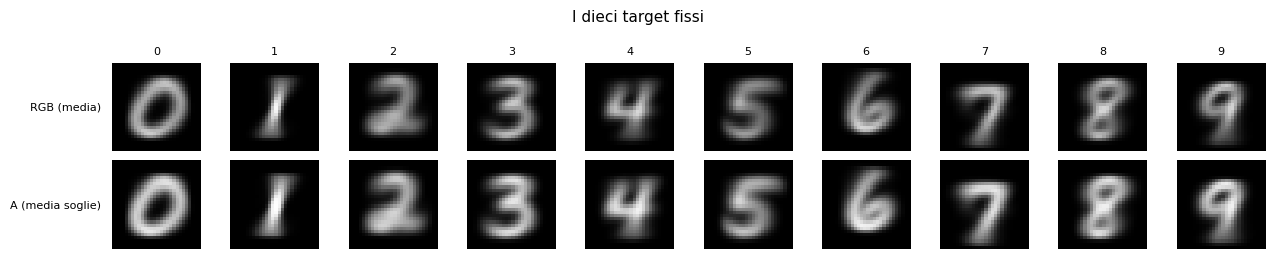

In [ ]:
@torch.no_grad()
def make_fixed_targets(loader, cfg: Config) -> torch.Tensor:
    """
    Ritorna [num_classes, 4, H, W]: la media per classe dei target RGBA del training set.

    X sono le immagini del training set MNIST in scala di grigi, [N, 1, H, W].
    La conversione a RGBA avviene dentro make_target_rgba, applicata a una classe alla volta.
    In questo modo il tensore a 4 canali esiste solo per i 6000 esempi di
    quella cifra e viene subito ridotto dalla media, invece di occupare 4x la memoria
    per tutto il dataset.

    L'ordine e' vincolante: media DEI target, non target DELLA media. Sull'alpha le due
    cose differiscono, perche' 1{E[x] > tau} != E[1{x > tau}], ed e' la seconda il
    minimizzatore MSE.

    `ds.data` sono i pixel uint8 [N, 28, 28] e bypassano il transform; dividere per 255
    riproduce esattamente cio' che ToTensor() consegna al DataLoader.
    """
    ds = loader.dataset
    X, y = (ds.data.float() / 255.0).unsqueeze(1), ds.targets       # [N,1,H,W], [N]
    return torch.stack([make_target_rgba(X[y == d].to(cfg.device), cfg).mean(0)
                        for d in range(cfg.num_classes)])


@torch.no_grad()
def loss_floor_mnist(loader, cfg: Config, targets=None):
    """
    Ground level irriducibile della MSE nel regime MNIST.

    Per ogni classe costruisce i target VERI dei suoi campioni, ne prende la media (il
    minimizzatore costante sotto MSE) e misura l'errore residuo. Se `targets` e' dato,
    verifica che coincida con quella media: e' il controllo che chiude il cerchio fra i
    due regimi.

    Ritorna (ground_globale, serie per classe).
    """
    ds = loader.dataset
    X, y = (ds.data.float() / 255.0).unsqueeze(1), ds.targets
    total, n, per_class = 0.0, 0, {}
    for d in range(cfg.num_classes):
        T = make_target_rgba(X[y == d], cfg)              # [n_d, 4, H, W]
        best = T.mean(0, keepdim=True)
        if targets is not None:
            assert torch.allclose(best[0], targets[d].cpu(), atol=1e-5), \
                f"cifra {d}: TARGETS_FIX non e' il minimizzatore costante"
        s = F.mse_loss(best.expand_as(T), T, reduction="sum").item()
        per_class[d] = s / T.numel()
        total += s
        n += T.numel()
    return total / n, pd.Series(per_class, name="ground_loss")


TARGETS_FIX = make_fixed_targets(train_loader, cfg)
print(f"target fissi: {tuple(TARGETS_FIX.shape)} | device = {TARGETS_FIX.device}")
print(f"alpha: min {TARGETS_FIX[:, 3].min():.3f} | max {TARGETS_FIX[:, 3].max():.3f} "
      f"| e' continua, non binaria: {TARGETS_FIX[:, 3].unique().numel() > 2}")

floor, floor_per_class = loss_floor_mnist(train_loader, cfg, targets=TARGETS_FIX)
print(f"\n ground MSE del regime MNIST: {floor:.5f}   (regime a target fissi: 0)")
display(floor_per_class.to_frame().round(5).T)
print("Solo la quota di loss SOPRA questo livello e' attribuibile al modello.")

plot_grid([[TARGETS_FIX[d, 0].cpu().numpy() for d in range(cfg.num_classes)],
           [TARGETS_FIX[d, 3].cpu().numpy() for d in range(cfg.num_classes)]],
          row_labels=["RGB (media)", "A (media soglie)"],
          col_labels=[str(d) for d in range(cfg.num_classes)],
          title="I dieci target fissi")

## Cap 1: I modelli


In questo capitolo definiamo i due modelli di conditional-NCA: quello della baseline e il nostro rispettivamente.




In [ ]:
def make_seed(batch_size: int, cfg: Config, device=None) -> torch.Tensor:
    """
    Stato iniziale: una sola cella accesa al centro della griglia.

    I canali dal 3 in poi (alpha + latenti) valgono 1, RGB resta a 0. Tutti gli stati
    del batch sono IDENTICI: l'unica sorgente di variabilita' fra due rollout e' la
    maschera stocastica di aggiornamento.
    """
    device = device or cfg.device
    x = torch.zeros(batch_size, cfg.channel_n, cfg.image_size, cfg.image_size,
                    device=device)
    x[:, 3:, cfg.center, cfg.center] = 1.0
    return x


# serve già dal capitolo 2, quindi l'abbiamo messa qui
def reconstruction_loss(state: torch.Tensor, target_rgba: torch.Tensor) -> torch.Tensor:
    """MSE fra i primi 4 canali dello stato e il bersaglio RGBA. I latenti sono liberi."""
    return F.mse_loss(state[:, :4], target_rgba)

### 1.1 - c-NCA (v1)

Il modello **baseline** (c-NCA v1) proposto da Sakour (https://arxiv.org/html/2512.08360) è un cellular automata codizionale. Le principali caratteristiche del modello sono:

- la regola di percezione, appresa tramite una convoluzione depthwise 3x3 applicata a tutti i canali dello stato;

- il condizionamento mediante la concatenazione su tutta la griglia di un vettore one-hot al vettore di percezione;

- l'update rule che prede i input la concatenazione dei due vettori sopracitati e produce un update dx. Questa regola è costruita mediante un MLP implementato con due convoluzioni 1x1 separate da una
non-linearità ReLU;

È importante evidenziare il fatto che l'applicazione dell'incremento dx non è automatica, ma dipende da due maschere:
- la maschera stocastica di aggiornamento, per mezzo della quale ogni cella ha il 50% di probabilità di aggiornarsi. Questo meccanismo,
ereditato da Mordvintsev et al. (Growing NCA) per indurre un'asincronia che rende la regola di update più robusta a piccole perturbazioni locali e più vicina, concettualmente, all'assenza di un clock globale nei sistemi biologici reali.
- L'alive mask, ossia un meccanismo che decide quali celle sono vive o morte: si considera il canale alpha (canale 3) nel vicinato 3x3 di ogni cella (cella stessa inclusa); se il valore massimo di alpha in quel vicinato supera la soglia `alive_thr`, la cella è considerata viva, altrimenti viene azzerata su tutti i canali.



In [ ]:
class ConditionalNCA(nn.Module):
    """
    Neural Cellular Automata condizionato dalla classe (versione 1).

    Stato [B, channel_n, H, W]: canali 0-2 RGB, canale 3 alpha, il resto latenti.
    Un passo di aggiornamento:
        percezione depthwise 3x3 -> concatenazione del vettore di classe ->
        MLP 1x1 -> dx -> maschera stocastica -> alive mask
    """

    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.channel_n = cfg.channel_n
        C, K = cfg.channel_n, cfg.num_classes

        # groups=C: ogni canale ha i suoi 3 filtri e non vede gli altri. E' la
        # percezione APPRESA, la differenza principale rispetto ai Sobel fissi della v2.
        self.perceive = nn.Conv2d(C, 3 * C, 3, padding=1, groups=C, bias=False)

        # conv 1x1 = una MLP applicata indipendentemente a ogni cella
        self.update_net = nn.Sequential(
            nn.Conv2d(3 * C + K, cfg.hidden, 1),
            nn.ReLU(),
            nn.Conv2d(cfg.hidden, C, 1),
        )
        with torch.no_grad():
            self.update_net[-1].weight.zero_()   # "do nothing" iniziale
            self.update_net[-1].bias.zero_()

    def condition(self, perception: torch.Tensor, class_vec: torch.Tensor) -> torch.Tensor:
        """Replica il vettore di classe su tutte le celle e lo concatena alla percezione."""
        B, _, H, W = perception.shape
        # expand() non copia memoria: crea una vista con stride 0, cioe' lo stesso
        # vettore di classe "visto" da tutte le H*W celle.
        class_map = class_vec.view(B, -1, 1, 1).expand(B, -1, H, W)
        return torch.cat([perception, class_map], dim=1)

    def alive_mask(self, x: torch.Tensor) -> torch.Tensor:
        """1 dove alpha supera la soglia in un intorno 3x3, 0 altrove."""
        return (F.max_pool2d(x[:, 3:4], 3, stride=1, padding=1) > self.cfg.alive_thr).float()

    def step(self, x: torch.Tensor, class_vec: torch.Tensor, stochastic: bool = True):
        """
        Un passo dell'automa.
        x          stato [B, channel_n, H, W]
        class_vec  condizionamento [B, num_classes]
        stochastic False disattiva la maschera di update: tutte le celle si aggiornano
        """
        dx = self.update_net(self.condition(self.perceive(x), class_vec))
        if stochastic:
            B, _, H, W = x.shape
            # una moneta per CELLA (non per canale): forma [B,1,H,W], il resto per broadcast
            fire = (torch.rand(B, 1, H, W, device=x.device) <= self.cfg.fire_rate).float()
        else:
            fire = 1.0
        x = x + dx * fire
        return x * self.alive_mask(x)

    def forward(self, x, class_vec, steps, stochastic: bool = True):
        """Applica `steps` passi di seguito. L'intero rollout entra nel grafo delle derivate."""
        for _ in range(int(steps)):
            x = self.step(x, class_vec, stochastic)
        return x

### 1.2 - c-NCA v2

Nel **modello proposto**(c-NCA v2) ci sono diverse differenze quali:
- L'utilizzo di filtri fissi (li stessi di Growing NCA) come prior del modello. Questa scelta vincola la rete a percepire gradienti e differenze locali in modo predefinito, riducendo i gradi di libertà del modello e rendendo la regola di aggiornamento più interpretabile.
- FiLM (Feature-wise Linear Modulation) un meccanismo di condizionamento più generale e raffinato della concatenzione, essa consiste in una trasformazione lineare del vettore di classe produce una coppia di parametri (γ, β) che scalano e traslano l'attivazione nascosta della update rule, cella per cella:
h ← (1+γ)·h + β. Questo permette un condizionamento moltiplicativo, più espressivo della semplice concatenazione additiva usata nella baseline.

- L'introduzione di una seconda alive mask prima del update rule, in questo modo la cella sopravvive solo se risulta viva in entrambi i momenti (AND logico tra le due maschere). Così facendo si impedisce a una cella morta di "resuscitare" temporaneamente solo per effetto dell'incremento dx applicato in quel passo, rendendo il criterio di vita/morte più conservativo e coerente nel tempo.

In [ ]:
class ConditionalNCAv2(nn.Module):
    """
    c-NCA v2: percezione fissa (I, Sobel_x, Sobel_y) come prior,
              condizionamento FiLM,
              alive_mask applicata prima e dopo l'aggiornamento.
    """

    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        C, K, H = cfg.channel_n, cfg.num_classes, cfg.hidden
        self.channel_n = C

        # register_buffer: fa parte dello state_dict e segue il modello sul device,
        # ma non e' un parametro e non riceve gradiente.
        self.register_buffer("kernel", self._fixed_kernel(C))

        self.fc1 = nn.Conv2d(3 * C, H, 1)   # conv 1x1 = MLP per-cella
        self.fc2 = nn.Conv2d(H, C, 1)

        # FiLM: un Linear su un one-hot E' una tabella di lookup per classe. L'uscita
        # ha 2H componenti, che spezzeremo in [gamma, beta].
        # bias=False: su un one-hot il bias darebbe W[:,k] + b, cioe' un vettore
        # costante uguale per tutte le classi, gia' assorbibile nelle colonne di W.
        self.film = nn.Linear(K, 2 * H, bias=False)

        with torch.no_grad():
            self.film.weight.zero_()   # a init gamma = 1+0 = 1, beta = 0: FiLM = identita'
            self.fc2.weight.zero_()    # "do nothing" iniziale
            self.fc2.bias.zero_()

    @staticmethod
    def _fixed_kernel(C: int) -> torch.Tensor:
        """
        [3C, 1, 3, 3] con (identita', Sobel_x, Sobel_y) ripetuti per ogni canale.

        Con groups=C l'uscita 3c+j appartiene al canale c, quindi l'ordine deve essere
        I, sx, sy, I, sx, sy, ... La divisione per 8 tiene le derivate sulla stessa
        scala del canale identita'.
        """
        ident = torch.tensor([[0., 0, 0], [0, 1, 0], [0, 0, 0]])
        sx = torch.tensor([[-1., 0, 1], [-2, 0, 2], [-1, 0, 1]]) / 8.0
        sy = sx.t().contiguous()
        k = torch.stack([ident, sx, sy])            # [3, 3, 3]
        return k.repeat(C, 1, 1).unsqueeze(1)       # [3C, 1, 3, 3]

    def perceive(self, x: torch.Tensor) -> torch.Tensor:
        """Convoluzione depthwise con i filtri fissi."""
        return F.conv2d(x, self.kernel, padding=1, groups=self.channel_n)

    def alive_mask(self, x: torch.Tensor) -> torch.Tensor:
        """1 dove alpha supera la soglia in un intorno 3x3, 0 altrove."""
        return (F.max_pool2d(x[:, 3:4], 3, 1, 1) > self.cfg.alive_thr).float()

    def rule(self, x: torch.Tensor, class_vec: torch.Tensor) -> torch.Tensor:
        """La regola locale: percezione -> FiLM -> MLP per-cella -> dx."""
        h = self.fc1(self.perceive(x))
        # chunk(2, dim=1) spezza [B, 2H] in due tensori [B, H]
        gamma, beta = self.film(class_vec).chunk(2, dim=1)
        # [B,H] -> [B,H,1,1] per modulare tutte le celle della griglia
        h = (1 + gamma)[:, :, None, None] * h + beta[:, :, None, None]
        return self.fc2(F.relu(h))

    def step(self, x, class_vec, stochastic: bool = True):
        """Un passo dell'automa, con maschera di vitalita' prima e dopo l'update."""
        pre = self.alive_mask(x)
        dx = self.rule(x, class_vec)
        if stochastic:
            B, _, H, W = x.shape
            fire = (torch.rand(B, 1, H, W, device=x.device) <= self.cfg.fire_rate).float()
        else:
            fire = 1.0
        x = x + dx * fire
        # il prodotto di due maschere 0/1 e' il loro AND: viva prima E viva dopo
        return x * (pre * self.alive_mask(x))

    def forward(self, x, class_vec, steps, stochastic: bool = True):
        """Applica `steps` passi di seguito."""
        for _ in range(int(steps)):
            x = self.step(x, class_vec, stochastic)
        return x

## Cap 2: Libreria di valutazione

In questo capitolo abbiamo inserito tutte le funzioni utili a valutare la qualità dei modelli: un classificatore esterno, il rollout in modalità eval, le perturbazioni,
gli esperimenti di rigenerazione, plasticità e interpolazione.

### 2.1 - LeNet-5 come classificatore

Abbiamo addestrato un classificatore LeNet-5 su MNIST per 10 epoche

In [ ]:
class LeNet5(nn.Module):
    """LeNet-5 classica su MNIST 28x28 in scala di grigi."""

    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5, padding=2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


def train_lenet(model, loader, cfg: Config, epochs: int = 10):
    """
    Addestra il classificatore. Ritorna {'epoch_loss': [...]}, nello stesso formato
    delle history dei training dell'automa, cosi' load_or_train le salva allo stesso modo.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    epoch_loss = []
    for epoch in range(epochs):
        model.train()
        running = 0.0
        for images, labels in loader:
            images, labels = images.to(cfg.device), labels.to(cfg.device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            running += loss.item()
        epoch_loss.append(running / len(loader))
        print(f"[lenet] epoca {epoch + 1}/{epochs} — loss {epoch_loss[-1]:.4f}")
    return {"epoch_loss": epoch_loss}


@torch.no_grad()
def lenet_accuracy(model, loader, cfg: Config) -> float:
    """Accuratezza percentuale del classificatore sul loader dato."""
    model.eval()
    correct = total = 0
    for images, labels in loader:
        images, labels = images.to(cfg.device), labels.to(cfg.device)
        correct += (model(images).argmax(1) == labels).sum().item()
        total += labels.shape[0]
    return 100.0 * correct / total


lenet = LeNet5().to(cfg.device)
lenet, _, _ = load_or_train(lenet, "lenet5_mnist",
                            lambda m: train_lenet(m, train_loader, cfg), cfg)
print(f"accuratezza LeNet-5 sul test set MNIST: "
      f"{lenet_accuracy(lenet, test_loader, cfg):.2f}%")

[ckpt] pesi caricati da /content/drive/MyDrive/ProgettoDLAI/lenet5_mnist.pth — training saltato
accuratezza LeNet-5 sul test set MNIST: 99.02%


#### Cosa ne pensa LeNet-5 delle medie per classe?

Con seme e condizionamento deterministici e loss MSE, come abbiamo visto il c-NCA può, al massimo, imparare la media delle classi. Vale la pena sapere in anticipo come giudica LeNet quelle dieci immagini

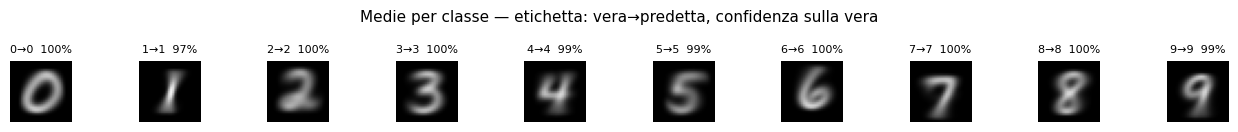

accuratezza sulle medie: 100%
confidenza media sulla classe vera: 99.35%


In [ ]:
means = TARGETS_FIX[:, 0:1]                     # [10, 1, H, W]: il canale RGB dei target fissi
lenet.eval()
with torch.no_grad():
    probs = F.softmax(lenet(means), dim=1).cpu()

plot_grid([[means[d, 0].cpu().numpy() for d in range(10)]],
          col_labels=[f"{d}→{probs[d].argmax()}  {100 * probs[d, d]:.0f}%"
                      for d in range(10)],
          title="Medie per classe — etichetta: vera→predetta, confidenza sulla vera")

print(f"accuratezza sulle medie: "
      f"{100 * (probs.argmax(1) == torch.arange(10)).float().mean():.0f}%")
print(f"confidenza media sulla classe vera: "
      f"{100 * probs[torch.arange(10), torch.arange(10)].mean():.2f}%")

### 2.2 - Rollout e rendering

`grow` esegue il rollout senza costruire il grafo delle derivate e può fotografare lo
stato ogni tot passi.

`as_image` trasforma uno stato in un'immagine visualizzabile.

Nota: `model.eval()` **non** disattiva la stocasticità dell' update mask. Non ci sono dropout né BatchNorm. L'update mask è parte della *regola* quindi non viene disattivata

In [ ]:
@torch.no_grad()
def grow(model, class_vec, steps, cfg: Config, x0=None, snapshot_every=None,
         stochastic: bool = True):
    """
    Rollout in modalita' eval.

    class_vec      [B, num_classes], una riga per organismo da far crescere
    steps          numero di passi
    x0             stato iniziale; None = seme al centro
    snapshot_every se dato, fotografa lo stato ogni tot passi (t=0 incluso)

    Ritorna (stato_finale, [(t, stato_su_cpu), ...]); la lista e' vuota se
    snapshot_every e' None. Le fotografie vanno su CPU per non riempire la VRAM.
    """
    model.eval()
    x = make_seed(class_vec.shape[0], cfg) if x0 is None else x0.clone()
    snaps = [(0, x.cpu())] if snapshot_every else []
    for t in range(1, int(steps) + 1):
        x = model.step(x, class_vec, stochastic)
        if snapshot_every and t % snapshot_every == 0:
            snaps.append((t, x.cpu()))
    return x, snaps


@torch.no_grad()
def as_image(state, i: int, cfg: Config) -> np.ndarray:
    """
    Rende visualizzabile l'organismo `i` di uno stato [B, C, H, W].

    Composita sul fondo cfg.render_bg con l'operatore 'over':
        render = render_bg * (1 - alpha) + rgb
    Usa alpha CONTINUA, non la maschera binaria: una cella con alpha = 0.11 si vede
    quasi trasparente invece che a colore pieno. Con render_bg = 0 (MNIST) la formula
    si riduce a RGB.

    Ritorna [H, W] in grigio se cfg.in_ch == 1, [H, W, 3] se e' un dominio a colori.
    """
    rgba = state[i, :4].detach().cpu().clamp(0, 1)
    img = (cfg.render_bg * (1 - rgba[3:4]) + rgba[:3]).clamp(0, 1)
    return img.mean(0).numpy() if cfg.in_ch == 1 else img.permute(1, 2, 0).numpy()


def plot_by_digit(df, value: str, ax, title: str, ylabel: str, logy=False, ylim=None):
    """
    Traccia una curva per cifra su `ax`.

    df    tabella lunga con le colonne 'digit', 'step' e `value`
    value nome della colonna da mettere in ordinata
    """
    for d, g in df.groupby("digit"):
        ax.plot(g["step"], g[value], label=f"{d}", alpha=.85, lw=1.4)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("step")
    ax.set_ylabel(ylabel)
    if logy:
        ax.set_yscale("log")
    if ylim:
        ax.set_ylim(*ylim)
    ax.grid(True, ls="--", alpha=.4)
    ax.legend(title="classe", fontsize=7, ncol=2, loc="best")

### 2.3 - Crescita, omeostasi, identificabilità
Questa sezione è dedicata alla misura della stabilità degli organismi al variare del tempo. In particolare abbiamo tre funzioni:

- `show_growth` mostra lo sviluppo degli organismi lungo un tempo di rollout fissato.
- `homeostasis` calcola la loss al variare del tempo degli organimsi rispetto al tempo in cui hanno completato il loro sviluppo.
- `lenet_confidence` tiene traccia della riconoscibilità delle cifre al variare del tempo

In [ ]:
def show_growth(model, cfg: Config, max_steps=512, every=64, digits=range(10),
                ncol=None, x0=None, seed=None, title=None):
    """
    Griglia classi x tempo: come cresce ogni classe a partire dallo stesso seme.

    digits  quali classi far crescere
    ncol    quante colonne (fotografie) per figura; None = tutte su una riga
    seed    se dato, fissa il rumore del rollout e RIPRISTINA lo stato del generatore
            a fine chiamata: due figure a epoche diverse differiscono cosi' solo per i
            pesi, e la diagnostica non perturba il flusso del training.

    Tutte le classi crescono INSIEME come un unico batch: la rete non accoppia i
    campioni (conv depthwise, conv 1x1, maschera per-campione), quindi il risultato e'
    identico a farle una per volta ed e' molto piu' veloce.
    """
    labels = torch.tensor(list(digits), device=cfg.device)
    state_cpu = torch.get_rng_state() if seed is not None else None
    state_gpu = (torch.cuda.get_rng_state_all()
                 if seed is not None and torch.cuda.is_available() else None)
    try:
        if seed is not None:
            torch.manual_seed(seed)
        _, snaps = grow(model, onehot(labels, cfg), max_steps, cfg,
                        x0=x0, snapshot_every=every)
    finally:
        if state_cpu is not None:
            torch.set_rng_state(state_cpu)
        if state_gpu is not None:
            torch.cuda.set_rng_state_all(state_gpu)

    ncol = ncol or len(snaps)
    # range(0, n, ncol) genera gli inizi dei blocchi; la fetta non sborda mai
    for k in range(0, len(snaps), ncol):
        block = snaps[k:k + ncol]
        plot_grid([[as_image(s, i, cfg) for _, s in block] for i in range(len(labels))],
                  row_labels=[f"classe {d}" for d in labels.tolist()],
                  col_labels=[f"t={t}" for t, _ in block],
                  title=title if k == 0 else None)


def homeostasis(model, cfg: Config, max_steps=1024, ref_step=64, every=16,
                seed=None, digits=range(10), plot=True):
    """
    Stabilita' nel tempo: MSE dello stato al tempo t rispetto allo stato a `ref_step`.

    ref_step deve essere multiplo di `every`, altrimenti la fotografia di riferimento
    non esiste. Ritorna una tabella lunga con mse_rgba (i 4 canali visibili) e mse_all
    (tutti i canali, latenti compresi).
    """
    assert ref_step % every == 0, "ref_step deve essere multiplo di every"
    if seed is not None:
        set_seed(seed)
    labels = torch.tensor(list(digits), device=cfg.device)
    _, snaps = grow(model, onehot(labels, cfg), max_steps, cfg, snapshot_every=every)
    snaps = [(t, s) for t, s in snaps if t >= ref_step]
    ref = snaps[0][1]                       # lo stato ESATTAMENTE a ref_step

    recs = [dict(digit=d, step=t,
                 mse_rgba=F.mse_loss(s[i:i + 1, :4], ref[i:i + 1, :4]).item(),
                 mse_all=F.mse_loss(s[i:i + 1], ref[i:i + 1]).item())
            for t, s in snaps for i, d in enumerate(labels.tolist())]
    df = pd.DataFrame(recs)
    if plot:
        fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2))
        plot_by_digit(df, "mse_rgba", a1, f"MSE RGBA vs t={ref_step}", "MSE", logy=True)
        plot_by_digit(df, "mse_all", a2, f"MSE tutti i canali vs t={ref_step}", "MSE", logy=True)
        plt.tight_layout()
        plt.show()
    return df


def lenet_confidence(model, lenet, cfg: Config, max_steps=1024, ref_step=64,
                     every=32, seed=None, digits=range(10), plot=True):
    """
    Confidenza di LeNet-5 sulla classe target, lungo il rollout.

    Vale solo su MNIST 28x28 in grigio: su altri domini si usa target_identifiability.
    Ritorna una tabella lunga con la colonna 'confidence' in percentuale.
    """
    assert cfg.image_size == 28 and cfg.in_ch == 1, \
        "lenet_confidence vale solo su MNIST 28x28: usa target_identifiability"
    assert ref_step % every == 0
    if seed is not None:
        set_seed(seed)
    labels = torch.tensor(list(digits), device=cfg.device)
    _, snaps = grow(model, onehot(labels, cfg), max_steps, cfg, snapshot_every=every)
    lenet.eval()
    recs = []
    with torch.no_grad():
        for t, s in snaps:
            if t < ref_step:
                continue
            img = s[:, :3].mean(dim=1, keepdim=True).clamp(0, 1).to(cfg.device)
            probs = F.softmax(lenet(img), dim=1).cpu()
            recs += [dict(digit=d, step=t, confidence=100 * probs[i, d].item())
                     for i, d in enumerate(labels.tolist())]
    df = pd.DataFrame(recs)
    if plot:
        fig, ax = plt.subplots(figsize=(8, 4.2))
        plot_by_digit(df, "confidence", ax, "Confidenza LeNet-5 sulla classe target",
                      "confidenza (%)", ylim=(-5, 105))
        plt.tight_layout()
        plt.show()
    return df


@torch.no_grad()
def target_identifiability(states, targets, labels=None):
    """
    Metrica esterna agnostica al dominio: assegna ogni stato al target piu' vicino in MSE.

    Serve dove LeNet non e' applicabile (colore, 64x64).
    Ritorna (pred, margine[, accuratezza]), dove margine è la differenza fra la seconda e la
    prima distanza: la MSE da sola non distingue "ha generato l'immagine giusta" da "ha
    generato una macchia della luminanza giusta", il margine si', perche' e' relativo
    agli altri bersagli.
    """
    d = ((states[:, None, :4] - targets[None]) ** 2).mean(dim=(2, 3, 4))    # [B, K]
    top2 = d.topk(2, dim=1, largest=False)
    pred, margin = top2.indices[:, 0], top2.values[:, 1] - top2.values[:, 0]
    if labels is None:
        return pred, margin
    return pred, margin, (pred == labels).float().mean().item()

### 2.4 - Perturbazioni

Una perturbazione è una funzione `stato -> stato`. Le funzioni qui sotto non danneggiano gli stati ma restituiscono funzioni che lo fanno, con i parametri già fissati.
Questa scelta è stata fatta affinchè  `damage_experiment` riceva un dizionario di perturbazioni e le applichi tutte allo stesso modo, senza dover sapere i parametri specifici come ad esempio: la probabilità del dropout, il centro e raggio del cerchio, il tipo di danno localizzato, ecc. Quello che gli viene passato è la configurazione.

*Nota*: i parametri sono **frazioni di area**, non numeri di pixel, così si adattano alla
dimensione della griglia

In [ ]:
def dropout_damage(p: float, cfg: Config = None):
    """
    Uccide una frazione p delle celle, scelte in modo indipendente.

    rand_like(x[:, :1]) ha forma [B,1,H,W]: il broadcasting applica la stessa sorte a
    tutti i canali della stessa cella, che muore intera e non a meta'.
    """
    def f(x):
        return x * (torch.rand_like(x[:, :1]) > p).float()
    return f


def circular_damage(cfg: Config, frac_min=None, frac_max=None):
    """
    Buco circolare di raggio e centro casuali, interamente dentro la griglia.

    Il raggio deriva da una FRAZIONE DI AREA: i default danno raggio 3-9 px a 28x28 e
    7-20 px a 64x64. Una sola circonferenza per chiamata, condivisa da tutti gli stati
    passati insieme.
    """
    S = cfg.image_size
    fmin = cfg.damage_frac_min if frac_min is None else frac_min
    fmax = cfg.damage_frac_max if frac_max is None else frac_max
    r_min = max(1, round(math.sqrt(fmin * S * S / math.pi)))
    r_max = max(r_min, round(math.sqrt(fmax * S * S / math.pi)))

    def f(x):
        # randint(a, b) campiona in [a, b-1]: l'estremo destro e' ESCLUSO
        r = int(torch.randint(r_min, r_max + 1, (1,)))
        lo, hi = r, S - r               # centri ammessi perche' il cerchio stia dentro
        if hi < lo:
            cx = cy = S // 2
        else:
            cx = int(torch.randint(lo, hi + 1, (1,)))
            cy = int(torch.randint(lo, hi + 1, (1,)))
        # meshgrid costruisce le matrici delle coordinate: yy[i,j]=i, xx[i,j]=j
        yy, xx = torch.meshgrid(torch.arange(S, device=x.device),
                                torch.arange(S, device=x.device), indexing="ij")
        dist = ((xx - cx) ** 2 + (yy - cy) ** 2).float().sqrt()
        keep = (dist > r).float()       # 1 fuori dal cerchio, 0 dentro => buco
        return x * keep.view(1, 1, S, S)
    return f


def localized_damage(kind: str, cfg: Config):
    """
    Danni geometrici deterministici: mezza griglia, oppure il quadrato centrale.

    kind: "right", "left", "top", "bottom", "center".
    Il lato del quadrato deriva da cfg.damage_square_frac: 10x10 a 28x28, 23x23 a 64x64.
    """
    S, h = cfg.image_size, cfg.center
    side = max(2, round(math.sqrt(cfg.damage_square_frac) * S))

    def f(x):
        keep = torch.ones(1, 1, S, S, device=x.device)
        if kind == "right":
            keep[:, :, :, h:] = 0
        elif kind == "left":
            keep[:, :, :, :h] = 0
        elif kind == "bottom":
            keep[:, :, h:, :] = 0
        elif kind == "top":
            keep[:, :, :h, :] = 0
        elif kind == "center":
            a, b = h - side // 2, h + side // 2
            keep[:, :, a:b, a:b] = 0
        else:
            raise ValueError(f"danno sconosciuto: {kind}")
        return x * keep
    return f


def localized_damage_set(cfg: Config,
                         kinds=("right", "left", "top", "bottom", "center")):
    """Dizionario {nome: funzione di danno}, pronto per damage_experiment."""
    return {k: localized_damage(k, cfg) for k in kinds}

### 2.5 - Danneggiamento e rigenerazione

`damage_experiment` fa crescere l'organismo, lo danneggia in tutti i modi richiesti, lo
lascia riparare e misura quanto è tornato vicino allo stato sano.

In [ ]:
def save_recovery_gif(frames, n_rows, n_cols, path, row_labels, col_labels, fps=10):
    """
    Salva l'animazione del recupero.

    frames  lista di fotogrammi; ogni fotogramma e' una lista di n_rows*n_cols immagini
    path    file .gif di destinazione
    """
    assert len(frames[0]) == n_rows * n_cols, \
        f"{len(frames[0])} immagini per fotogramma ma la griglia e' {n_rows}x{n_cols}"
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 1.2, n_rows * 1.2), squeeze=False)
    ims = []
    for r in range(n_rows):
        for c in range(n_cols):
            ax = axes[r][c]
            ax.set_xticks([])
            ax.set_yticks([])
            if r == 0:
                ax.set_title(col_labels[c], fontsize=7)
            if c == 0:
                ax.set_ylabel(row_labels[r], fontsize=7, rotation=0,
                              ha="right", va="center", labelpad=6)
            ims.append(ax.imshow(frames[0][r * n_cols + c], cmap="gray",
                                 vmin=0, vmax=1, animated=True))
    plt.subplots_adjust(wspace=.05, hspace=.05)

    # FuncAnimation richiama update(k) per ogni fotogramma; blit=True ridisegna solo
    # gli oggetti restituiti, non l'intera figura.
    def update(k):
        for i, im in enumerate(ims):
            im.set_array(frames[k][i])
        return ims

    animation.FuncAnimation(fig, update, frames=len(frames), blit=True,
                            interval=1000 // fps).save(path, writer="pillow", fps=fps)
    plt.close(fig)
    print(f"GIF salvata: {path}")


def damage_experiment(model, cfg: Config, damages: dict, steps_grow=64, steps_recover=48,
                      seed=None, digits=range(10), show_damaged=False,
                      gif_path=None, plot=True):
    """
    Cresci -> danneggia -> ripara, e misura il recupero.

    damages       {nome: funzione di danno}, tipicamente localized_damage_set(cfg)
    steps_grow    passi di crescita prima del danno
    steps_recover passi concessi per riparare
    show_damaged  mostra anche lo stato subito dopo il danno
    gif_path      se dato, salva l'animazione del recupero

    Ritorna una tabella con una riga per (cifra, danno) e la MSE fra lo stato riparato
    e quello sano.
    """
    if seed is not None:
        set_seed(seed)
    digits = list(digits)
    names = list(damages)                 # list(dizionario) = le sue CHIAVI, in ordine
    labels = torch.tensor(digits, device=cfg.device)
    class_vec = onehot(labels, cfg)
    grown, _ = grow(model, class_vec, steps_grow, cfg)

    # un blocco per cifra, e dentro un elemento per tipo di danno
    damaged = torch.cat([damages[n](grown[d:d + 1])
                         for d in range(len(digits)) for n in names], dim=0)
    class_vec_rep = class_vec.repeat_interleave(len(names), dim=0)

    frames = [[as_image(damaged, j, cfg) for j in range(len(damaged))]] if gif_path else []
    x = damaged
    with torch.no_grad():
        model.eval()
        for _ in range(steps_recover):
            x = model.step(x, class_vec_rep, stochastic=True)
            if gif_path:
                frames.append([as_image(x, j, cfg) for j in range(len(x))])
    recovered = x

    recs, rows = [], []
    for d, digit in enumerate(digits):
        row = [as_image(grown, d, cfg)]
        for k, n in enumerate(names):
            j = d * len(names) + k        # indice piatto nel batch (classe d, danno k)
            recs.append(dict(digit=digit, damage=n,
                             mse_rgba=F.mse_loss(recovered[j:j + 1, :4],
                                                 grown[d:d + 1, :4]).item(),
                             mse_all=F.mse_loss(recovered[j:j + 1], grown[d:d + 1]).item()))
            if show_damaged:
                row.append(as_image(damaged, j, cfg))
            row.append(as_image(recovered, j, cfg))
        rows.append(row)
    df = pd.DataFrame(recs)

    if plot:
        cols = [f"t={steps_grow}"]
        for n in names:
            if show_damaged:
                cols.append(f"{n}\n(danno)")
            cols.append(f"{n}\n(+{steps_recover})")
        plot_grid(rows, [f"classe {d}" for d in digits], cols)
        # pivot: da formato lungo a matrice cifre x danni
        display(df.pivot(index="digit", columns="damage", values="mse_rgba")
                  .round(4).rename_axis(columns="MSE RGBA dopo recupero"))
    if gif_path:
        save_recovery_gif(frames, len(digits), len(names), gif_path,
                          [f"classe {d}" for d in digits], names)
    return df

### 2.6 - Interpolazione fra due classi

Il condiziomento in fase di training avviene dando in input al modello i vettori one-hot della base canonica di $\mathbb R ^{k}$, dove $k$ è il numero di classi di condizionamento.


Con questa funzione indaghiamo qualitativamente quello che succede nei canali visibili, a tempo di rollout fissato, variando il condizionamento lungo il segmento che congiunge due vettori one-hot

In [ ]:
def interpolation_widget(model, cfg: Config):
    """Slider interattivo per esplorare il condizionamento fra due classi."""
    from ipywidgets import interact

    def show(class_a, class_b, w, steps):
        class_vec = mix_onehot(class_a, class_b, w, cfg)
        out, _ = grow(model, class_vec, steps, cfg)
        plt.figure(figsize=(3.2, 3.2))
        plt.imshow(as_image(out, 0, cfg), cmap="gray", vmin=0, vmax=1)
        plt.title(f"{1 - w:.2f}·{class_a} + {w:.2f}·{class_b}  (t={steps})",
                  fontsize=9)
        plt.axis("off")
        plt.show()

    return interact(
        show,
        class_a=widgets.IntSlider(min=0, max=9, value=0, description="classe A"),
        class_b=widgets.IntSlider(min=0, max=9, value=1, description="classe B"),
        w=widgets.FloatSlider(min=0.0, max=1.0, step=0.05, value=0.5, description="peso B"),
        steps=widgets.IntSlider(min=16, max=2048, step=16, value=64, description="step"))

### 2.7 - Plasticità: commutare il condizionamento

In questo paragrafo si fa crescere un organismo con la classe A per un certo numero di step, successivaemnte si cambia il
condizionamento in B. A questo punto le domande da porsi sono: si converte? quanto
resta della classe vecchia? si rimodella o muore e ricresce?

`switch_experiment` produce solo gli stati, `switch_study` li giudica con LeNet su più
semi, `plasticity_matrix` ripete lo studio su tutte le 90 coppie ordinate.

In [ ]:
@torch.no_grad()
def switch_experiment(model, cfg: Config, class_a, class_b, t0_list, t1_list,
                      seed, plot=False):
    """
    Cresce con class_a, commuta a class_b, restituisce gli stati. Nessun giudizio qui.

    t0_list  tempi di commutazione da provare
    t1_list  budget concessi dopo la commutazione

    Ritorna (grid, pre):
      grid [len(t0_list), len(t1_list), C, H, W]  stati dopo la commutazione
      pre  [len(t0_list),               C, H, W]  stati NEL momento della commutazione

    Un solo organismo cresce con class_a e viene fotografato a ogni t0: e' questo che
    rende confrontabili le righe della griglia. Le fotografie proseguono poi INSIEME
    come un unico batch, perche' la rete non accoppia i campioni.
    """
    model.eval()
    t0_list, t1_list = list(t0_list), list(t1_list)
    t0_set, t1_set = set(t0_list), set(t1_list)
    torch.manual_seed(seed)               # risemina il generatore GLOBALE

    # --- fase 1: crescita con class_a, con fotografia a ogni t0 -----------------
    cv_a = onehot(torch.tensor([class_a], device=cfg.device), cfg)
    x, snaps = make_seed(1, cfg), {}
    for t in range(max(t0_list) + 1):
        if t in t0_set:
            snaps[t] = x.clone()
        if t < max(t0_list):
            x = model.step(x, cv_a)
    pre = torch.cat([snaps[t] for t in t0_list], dim=0)          # [n0, C, H, W]

    # --- fase 2: le fotografie proseguono con class_b ---------------------------
    cv_b = onehot(torch.full((len(t0_list),), class_b, device=cfg.device), cfg)
    x, out = pre.clone(), {}
    for t in range(max(t1_list) + 1):
        if t in t1_set:
            out[t] = x.clone()
        if t < max(t1_list):
            x = model.step(x, cv_b)
    grid = torch.stack([out[t] for t in t1_list], dim=1)         # [n0, n1, C, H, W]

    if plot:
        # la prima colonna e' lo stato al momento della commutazione: senza, non si
        # capisce DA COSA sia partita ogni riga
        rows = [[as_image(pre, i, cfg)] +
                [as_image(grid[:, j], i, cfg) for j in range(len(t1_list))]
                for i in range(len(t0_list))]
        plot_grid(rows,
                  row_labels=[f"T0={t}" for t in t0_list],
                  col_labels=["commutaz."] + [f"+{t}" for t in t1_list],
                  title=f"{class_a} → {class_b}   (seed={seed})")
    return grid, pre


@torch.no_grad()
def switch_study(model, judge, cfg: Config, class_a, class_b, t0_list, t1_list,
                 seeds=range(8), plot_first=True, return_raw=False):
    """
    Ripete switch_experiment su piu' semi e lo giudica con LeNet.

    p_new  probabilita' della classe NUOVA: quanto si e' convertito
    p_old  probabilita' della classe vecchia: memoria residua
    alive  celle vive: distingue "si rimodella" da "muore e ricresce"

    class_b == class_a e' il CONTROLLO: stessa procedura, segnale invariato.
    Ritorna la tabella aggregata su (t0, t1), o quella grezza se return_raw=True.
    """
    t0_list, t1_list = list(t0_list), list(t1_list)
    n0, n1 = len(t0_list), len(t1_list)
    recs = []
    for k, seed in enumerate(seeds):
        grid, _ = switch_experiment(model, cfg, class_a, class_b, t0_list, t1_list,
                                    seed=seed, plot=(plot_first and k == 0))
        flat = grid.reshape(n0 * n1, *grid.shape[2:])
        img = flat[:, :3].mean(dim=1, keepdim=True).clamp(0, 1)
        p = F.softmax(judge(img), dim=1).view(n0, n1, cfg.num_classes).cpu()
        p_new, p_old = p[:, :, class_b], p[:, :, class_a]
        alive = model.alive_mask(flat).sum(dim=(1, 2, 3)).view(n0, n1).cpu()
        recs += [dict(seed=seed, t0=t0, t1=t1, p_new=p_new[i, j].item(),
                      p_old=p_old[i, j].item(), alive=alive[i, j].item())
                 for i, t0 in enumerate(t0_list) for j, t1 in enumerate(t1_list)]

    df = pd.DataFrame(recs)
    if return_raw:
        return df
    agg = df.groupby(["t0", "t1"])[["p_new", "p_old", "alive"]].agg(["mean", "std"])
    agg.columns = [f"{c}_{'avg' if f == 'mean' else 'sd'}" for c, f in agg.columns]
    agg["n_seed"] = df.groupby(["t0", "t1"]).seed.nunique()
    return agg


def plasticity_matrix(model, judge, cfg: Config, t0_list, t1=256, seeds=range(8),
                      pairs=None, stats=("p_new", "p_old")):
    """
    Lo studio di plasticita' su TUTTE le coppie ordinate di classi.

    Righe: le 90 coppie 0->1, 0->2, ..., 9->8. Sono ordinate, quindi (0,1) e (1,0) ci
    sono entrambe: l'asimmetria e' proprio cio' che vogliamo misurare.
    Colonne: MultiIndex (T0, misura, {avg, sd}).

    stats: quali misure riportare fra "p_new", "p_old" e "alive".
    """
    pairs = pairs or list(itertools.permutations(range(cfg.num_classes), 2))
    t0_list, stats = list(t0_list), list(stats)

    rows = {}
    for a, b in tqdm(pairs, desc=f"coppie di classi (T1={t1})"):
        agg = switch_study(model, judge, cfg, a, b, t0_list, [t1],
                           seeds=seeds, plot_first=False)
        s = agg.xs(t1, level="t1")        # xs = "cross section": fisso t1, resta t0
        vals = []
        for t0 in t0_list:                # l'ordine dei due cicli DEVE combaciare
            for st in stats:              # con from_product qui sotto
                vals += [s.loc[t0, f"{st}_avg"], s.loc[t0, f"{st}_sd"]]
        rows[f"{a}→{b}"] = vals

    cols = pd.MultiIndex.from_product([[f"T0={t}" for t in t0_list], stats, ["avg", "sd"]])
    out = pd.DataFrame.from_dict(rows, orient="index", columns=cols)
    out.columns.names = [f"T1={t1}", "misura", "stat"]
    out.index.name = "coppia"
    return out

## Cap 3: Libreria di training
In questo capitolo abbiamo inserito tutte le funzioni inerenti l'addestramento dei modelli di NCA utilizzati.
In particolare olte a diverse funzioni ausiliare abbiamo due principali meccanismi di training:

| | bersaglio | pool / danno | usata da |
|---|---|---|---|
| `train_nca` | il campione MNIST del batch | mai | cap. 4 (baseline) |
| `train_nca_fixed` | una delle 10 immagini fisse | sì, secondo `mode` | cap. 5-8 e appendice |


### 3.1 - Sample pool

L'architettura di questi NCA è molto simile a quella di una Recurrent Neural Network, e allo stesso modo i gradienti delle loss vengono calcolati tramite Back Propagation Through Time (BPTT). Tuttavia questa richiede di memorizzare tanti grafi computazionali quanti step di rollout, consumando moltissima memoria durante il training e rendendo difatti impraticabile addestrare il modello direttamente su rollout lunghi.

Per ovviare al problema già in Growing NCA, si è optato per una strategia di pooling. Gli stati non ripartono dal seme a ogni iterazione: vivono in un pool per classe, ad ogni step di training vengono pescati, e fatti evolvere per qualche decina di passi e rimessi dentro. Il modello è così obbligato a essere stabile su orizzonti molto più lunghi di un singolo rollout, perché uno stato pescato può avere centinaia di passi di età.

In questo modo il gradiente viene calcolato solo su i passi di rollout di questa iterazione,e non su tutta la storia dello stato estratto.

In [ ]:
class SamplePool:
    """
    Pool di stati persistenti, uno scomparto per classe: [num_classes, size, C, H, W].
    """

    def __init__(self, cfg: Config, size_per_class: int):
        self.cfg, self.size = cfg, size_per_class
        n = cfg.num_classes * size_per_class
        # creo n semi in un tensore piatto e lo reinterpreto come 5-dimensionale:
        # view() non copia, cambia solo il modo di leggere la stessa memoria.
        self.pool = make_seed(n, cfg).view(
            cfg.num_classes, size_per_class, cfg.channel_n, cfg.image_size, cfg.image_size)

    def sample(self, labels):
        """
        Pesca uno stato per ogni etichetta del batch. Ritorna (states, idx).
        L'estrazione da parte del batch avviene senza reinserimento.
        """
        idx = torch.empty_like(labels)
        for c in labels.unique():
            sel = torch.where(labels == c)[0]      # posizioni di quella classe nel batch
            idx[sel] = torch.randperm(self.size, device=labels.device)[:len(sel)]
        # pool[labels, idx] con DUE tensori di indici lunghi B e' un gather elemento
        # per elemento, e restituisce una COPIA: modificarla non tocca il pool.
        return self.pool[labels, idx], idx

    def commit(self, labels, idx, states):
        """
        Riscrive nel pool gli stati evoluti.
        osserviamo l'importanza del detach(): senza, il pool conserverebbe il grafo delle derivate
        di questa iterazione e la memoria crescerebbe senza limite di batch in batch.
        """
        self.pool[labels, idx] = states.detach()


def is_dead(states, cfg: Config) -> torch.Tensor:
    """
    ritorna B di booleani: True se lo stato non ha nemmeno una cella viva.

    Uno stato morto è un punto fisso per l'update rule,
    cioè x * alive_mask(x) con maschera nulla resta nullo per sempre,
    e la soglia booleana non propaga gradiente e aumenta la loss di una costante.
    Pertanto questi stati risultano completamente inutili.
    """
    return states[:, 3:4].flatten(1).amax(1) <= cfg.alive_thr

### 3.2 - Politica di refresh del pool

La politica di refresh del pool è uno degli aspetti più delicati del training:
- se gli stati restassero nel pool a lungo senza essere toccati, il modello non vedrebbe mai una vera crescita a partire dal seme, ma solo il proseguimento di traiettorie già formate, perdendo quindi la capacità di svilupparsi da zero.
- se invece i cadaveri (stati collassati, alpha sotto soglia ovunque) restassero nel pool, ogni volta che venissero ripescati sprecherebbero una fetta di batch senza produrre gradiente utile.

La politica di refresh risolve questo problema decidendo, ad ogni pescata e per ogni classe separatamente, quali stati tornano al seme e quali vengono invece danneggiati.

La politica adottata prevede:
- **risemina**: i `pool_n_reset` stati a loss peggiore (più eventuali cadaveri) vengono riportati al seme.
- **danno**: i `pool_n_dam` stati a loss migliore fra i sopravvissuti subiscono un danno.

L'eliminazione degli stati morti è una nostra aggiunta rispetto alla strategia di base sviluppata in Growing NCA.


In [ ]:
def refresh_pool(states, labels, target_rgba, cfg: Config, use_damage: bool):
    """
    Applica la politica di refresh del pool, in-place su `states`.

    states      [B, C, H, W] appena pescati dal pool
    labels      [B] le classi corrispondenti
    target_rgba [B, 4, H, W] i bersagli, usati SOLO come chiave di ordinamento
    use_damage  se False si salta del tutto il passo 2

    Ordine, vincolante:
      1. risemina dei peggiori e dei morti;
      2. danno circolare sui MIGLIORI fra i sopravvissuti;
      3. tutti gli altri proseguono intatti.

    La loss calcolata qui dentro non tocca il grafo e non e' la loss di training:
    dipende solo dallo stato, quindi e' identica alla loss finale dell'ultima volta che
    quello stato e' stato pescato.
    """
    damage = circular_damage(cfg)         # crea la funzione-danno una volta sola
    with torch.no_grad():
        # reduction="none" NON media: [B,4,H,W]; .mean(dim=[1,2,3]) lascia [B]
        loss = F.mse_loss(states[:, :4], target_rgba, reduction="none").mean(dim=[1, 2, 3])
        dead = is_dead(states, cfg)

        for c in labels.unique():
            sel = torch.where(labels == c)[0]
            n = len(sel)
            if n == 0:
                continue

            # --- 1. risemina --------------------------------------------------
            # la maschera `reset` e' allineata a `sel`, NON agli indici del batch:
            # sel[reset] fa la traduzione.
            reset = dead[sel].clone()
            worst = torch.topk(loss[sel], min(cfg.pool_n_reset, n), largest=True)
            reset[worst.indices] = True

            to_seed = sel[reset]
            if len(to_seed) > 0:
                states[to_seed] = make_seed(len(to_seed), cfg)

            # --- 2. danno sui migliori fra i sopravvissuti --------------------
            if use_damage:
                survivors = sel[~reset]          # la tilde nega la maschera booleana
                n_dam = cfg.pool_n_dam
                k = min(n_dam, len(survivors))
                if k > 0:
                    # largest=False da' i piu' PICCOLI: gli stati meglio formati
                    best = survivors[torch.topk(loss[survivors], k, largest=False).indices]
                    for i in best:               # un cerchio diverso per ogni stato
                        # [i:i+1] invece di [i]: mantiene la dimensione di batch
                        states[i:i + 1] = damage(states[i:i + 1])
    return states


### 3.3 - Diagnostica: due curve e una griglia

Tutta la diagnostica del training è questa:

- **mentre gira**, due pannelli che si ridisegnano ogni `plot_every` iterazioni: la
  loss a sinistra e la norma del gradiente (misurata **prima** del clipping) a destra;
- **a fine epoca**, la griglia di crescita delle classi scelte (di default tutte e
  dieci) con la loss media dell'epoca nel titolo. Questa parte si accumula, così si
  vede l'organismo cambiare epoca dopo epoca.

Le due parti stanno in due aree di output separate perché hanno vite diverse: quella
in alto si sovrascrive, quella in basso cresce.

La `history` è un semplice dizionario di liste, salvato in JSON accanto ai pesi: dopo
un `load_or_train` che carica da disco, `plot_history` ridisegna esattamente gli stessi
grafici senza riaddestrare.

In [ ]:
def new_history() -> dict:
    """History vuota: le quattro liste che il training riempie."""
    return dict(iter_loss=[], iter_grad=[], epoch_loss=[], epoch_bounds=[])


def plot_curves(history: dict, grad_clip=None, title=None, figsize=(11, 3.2)):
    """
    Costruisce la figura a due pannelli (loss a sinistra, norma del gradiente a destra).

    Ritorna la figura SENZA mostrarla, cosi' chi chiama decide dove metterla: il monitor
    la manda nella sua area di output, plot_history la mostra e basta.
    Le linee verticali sottili sono i confini di epoca.
    """
    fig, (ax_loss, ax_grad) = plt.subplots(1, 2, figsize=figsize)
    n = len(history["iter_loss"])
    # con decine di migliaia di iterazioni disegnare tutti i punti rallenta il redraw
    # e non aggiunge nulla di leggibile: ne teniamo al massimo ~2000, presi a passo fisso
    stride = max(1, n // 2000)
    it = np.arange(1, n + 1)[::stride]

    if len(it):
        ax_loss.plot(it, history["iter_loss"][::stride], lw=.6, alpha=.45,
                     color="tab:blue", label="per iterazione")
    if history["epoch_loss"]:
        ax_loss.plot(history["epoch_bounds"], history["epoch_loss"], "o-",
                     ms=4, lw=1.5, color="crimson", label="media per epoca")
    ax_loss.set_yscale("log")
    ax_loss.set_xlabel("iterazione")
    ax_loss.set_ylabel("MSE")
    ax_loss.set_title("loss", fontsize=10)
    ax_loss.grid(alpha=.3, ls="--")
    ax_loss.legend(fontsize=8)

    if len(it):
        ax_grad.plot(it, history["iter_grad"][::stride], lw=.6, alpha=.6, color="tab:green")
    if grad_clip is not None:
        ax_grad.axhline(grad_clip, ls="--", c="r", lw=1,
                        label=f"soglia di clip = {grad_clip}")
        ax_grad.legend(fontsize=8)
    ax_grad.set_yscale("log")
    ax_grad.set_xlabel("iterazione")
    ax_grad.set_ylabel("‖gradiente‖")
    ax_grad.set_title("norma del gradiente (prima del clipping)", fontsize=10)
    ax_grad.grid(alpha=.3, ls="--")

    for b in history["epoch_bounds"][:-1]:
        for ax in (ax_loss, ax_grad):
            ax.axvline(b, color="k", lw=.5, alpha=.2)
    if title:
        fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    return fig


def plot_history(history: dict, cfg: Config = None, title=""):
    """Ridisegna le curve di un training, anche se la history viene da un file salvato."""
    if not history:
        print("nessuna statistica di training salvata per questo modello")
        return
    fig = plot_curves(history, grad_clip=None if cfg is None else cfg.grad_clip,
                      title=title)
    display(fig)
    plt.close(fig)
    e = history["epoch_loss"]
    if e:
        print(f"loss media per epoca: prima {e[0]:.5f} → ultima {e[-1]:.5f} "
              f"({len(e)} epoche)")


class LiveMonitor:
    """
    Mostra la diagnostica mentre il training gira. Non possiede dati: legge la
    `history` che la funzione di training riempie.

    cfg           configurazione del run (serve per la soglia di clip e per la crescita)
    digits        classi da mostrare a fine epoca; di default tutte
    plot_every    ogni quante iterazioni ridisegnare le due curve
    preview_steps / preview_every / preview_ncol / seed
                  parametri della griglia di crescita di fine epoca (vedi show_growth)
    use_widgets   True usa due aree ipywidgets, che e' quello che permette alla figura
                  in alto di sostituirsi mentre quella in basso si accumula. Mettilo a
                  False se nel tuo ambiente le due aree restano vuote: in quel caso non
                  c'e' aggiornamento durante l'epoca, e a fine epoca curve e griglia
                  vengono semplicemente stampate una sotto l'altra.

    Il costruttore mostra subito le due aree di output, quindi va creato nella stessa
    cella del training.
    """

    def __init__(self, cfg: Config, digits=None, plot_every=50, preview_steps=256,
                 preview_every=32, preview_ncol=9, seed=0, use_widgets=True):
        self.cfg = cfg
        self.digits = list(range(cfg.num_classes)) if digits is None else list(digits)
        self.plot_every = plot_every
        self.preview_steps = preview_steps
        self.preview_every = preview_every
        self.preview_ncol = preview_ncol
        self.seed = seed
        self.live_area = self.epoch_area = None
        if use_widgets:
            self.live_area = widgets.Output()     # si sovrascrive
            self.epoch_area = widgets.Output()    # si accumula
            display(widgets.VBox([self.live_area, self.epoch_area]))

    def step(self, history: dict):
        """Da chiamare a ogni iterazione: ridisegna solo una volta ogni plot_every."""
        if self.live_area is not None and len(history["iter_loss"]) % self.plot_every == 0:
            self.draw(history)

    def draw(self, history: dict):
        """Ridisegna le due curve, sostituendo la figura precedente."""
        fig = plot_curves(history, grad_clip=self.cfg.grad_clip)
        if self.live_area is None:
            display(fig)
        else:
            with self.live_area:
                clear_output(wait=True)        # svuota SOLO questa area, non la cella
                display(fig)
        plt.close(fig)                         # senza, le figure restano in memoria

    def _growth(self, history: dict, model, epoch: int):
        show_growth(model, self.cfg, max_steps=self.preview_steps,
                    every=self.preview_every, digits=self.digits,
                    ncol=self.preview_ncol, seed=self.seed,
                    title=f"fine epoca {epoch + 1} — "
                          f"loss media {history['epoch_loss'][-1]:.5f}")

    def end_epoch(self, history: dict, model, epoch: int):
        """Aggiorna le curve e appende la griglia di crescita di questa epoca."""
        self.draw(history)
        if self.epoch_area is None:
            self._growth(history, model, epoch)
        else:
            with self.epoch_area:
                self._growth(history, model, epoch)
        model.train()      # show_growth passa da model.eval(): ripristino

### 3.4 - Training della baseline su MNIST

È il training "ingenuo" e riproduce il codice di riferimento del paper c-NCA: ogni
batch riparte dal seme, si evolve per un numero **fisso** di passi, e il bersaglio è il
campione che il DataLoader consegna a quel batch. Niente pool, niente danno.

In [ ]:
def train_nca(model, loader, cfg: Config, monitor: LiveMonitor = None):
    """
    Baseline su MNIST completo: dal seme, rollout fisso di cfg.n_steps.

    model    ConditionalNCA o ConditionalNCAv2, gia' sul device
    loader   DataLoader di MNIST
    monitor  LiveMonitor per i grafici in tempo reale; None = nessun grafico

    Ritorna la history {'iter_loss', 'iter_grad', 'epoch_loss', 'epoch_bounds'}.
    """
    optimizer = optim.Adam(model.parameters(), lr=cfg.lr)
    history = new_history()

    for epoch in range(cfg.n_epochs):
        model.train()
        running = 0.0
        pbar = tqdm(loader, desc=f"[baseline] epoca {epoch + 1}/{cfg.n_epochs}")

        for images, labels in pbar:
            images, labels = images.to(cfg.device), labels.to(cfg.device)
            target = make_target_rgba(images, cfg)
            class_vec = onehot(labels, cfg)

            # tutti gli stati ripartono dal seme: una cella accesa al centro
            states = make_seed(labels.shape[0], cfg)
            out = model(states, class_vec, cfg.n_steps)
            loss = reconstruction_loss(out, target)

            optimizer.zero_grad()      # i gradienti si ACCUMULANO: vanno azzerati
            loss.backward()
            # clip_grad_norm_ ritorna la norma PRIMA del taglio: e' la quantita' che
            # vogliamo diagnosticare, e non costa nulla perche' viene calcolata comunque
            gnorm = torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()

            l = loss.item()            # un solo trasferimento GPU->CPU per iterazione
            history["iter_loss"].append(l)
            history["iter_grad"].append(float(gnorm))
            running += l
            pbar.set_postfix(loss=f"{l:.5f}")
            if monitor is not None:
                monitor.step(history)

        history["epoch_loss"].append(running / len(loader))
        history["epoch_bounds"].append(len(history["iter_loss"]))
        if monitor is not None:
            monitor.end_epoch(history, model, epoch)

    return history

### 3.5 - Training a target fissi

Stessa struttura, ma il dataset è sostituito da dieci immagini fisse: le medie delle cifre che il modello effettivamente impara. Cambiano tre cose:

- **niente DataLoader: il batch è sempre lo stesso, quindi etichette, vettori di
  classe e bersagli si costruiscono una volta sola fuori dal ciclo;
- Non ci sono epoche in senso stretto in quanto non c'è un dataset da coprire, ma abbiamo mantenuto per comodità il terimene "epoca" nel senso di "un blocco di `iters_per_epoch` iterazioni".
- ci sono le tre **modalità**: `baseline` (dal seme, passi fissi), `pool`, `pool_damage`.

**Il budget.** `25 × 320 = 8000` iterazioni, che è il budget del Colab di Mordvintsev. Con `per_class_fix = 8` la corrispondenza è esatta *per classe*: ogni cifra riceve 8 rollout indipendenti per iterazione, cioè 64000 rollout in tutto, lo stesso numero che l'articolo spende sul suo unico bersaglio.
Il capitolo 4 su MNIST fa invece `25 × 938 = 23450` iterazioni, in quanto il training della baseline su tutto MNIST è molto più arduo e rumoroso.

I due parametri `micro` e `cos_anneal` vengono utilizzati **solo all'appendice a colori** e sono spenti di default; sono documentati nel docstring e discussi lì.

In [ ]:
def train_nca_fixed(model, targets, cfg: Config, mode: str = "baseline",
                    per_class=None, iters_per_epoch=None,
                    monitor: LiveMonitor = None, micro=None,
                    cos_anneal: bool = False, eta_min_frac: float = 0.1):
    """
    Training su bersagli fissi (una immagine per classe).

    model     ConditionalNCA o ConditionalNCAv2, gia' sul device
    targets   [num_classes, 4, H, W] i bersagli fissi
    mode      "baseline"    ogni iterazione riparte dal seme, rollout di cfg.n_steps
              "pool"        sample pool + rinfresco senza danno
              "pool_damage" come sopra, piu' il danno circolare
    per_class stati per classe nel batch; se None allora cfg.per_class_fix
    iters_per_epoch  iterazioni per blocco; se None allora cfg.iters_fix
    monitor   LiveMonitor per i grafici; se None allora nessun grafico

    micro (solo appendice): in quanti MICRO-BATCH spezzare rollout e backward. Se None o 1 allora spento.
      Il gradiente risultante e' lo stesso del batch intero (la media pesata
      con len(chunk)/B E' la media globale), ma la memoria delle attivazioni scala come
      1/micro.
    cos_anneal: utilizzato per gestire il learning rate per il lungo addestramento in appendice.

    Ritorna la history {'iter_loss', 'iter_grad', 'epoch_loss', 'epoch_bounds'}.
    """
    assert mode in {"baseline", "pool", "pool_damage"}
    assert targets.shape[0] == cfg.num_classes, "targets deve essere [num_classes, 4, H, W]"

    per_class = per_class or cfg.per_class_fix
    iters_per_epoch = iters_per_epoch or cfg.iters_fix

    # .repeat_interleave(repeat_interleave) copia ogni elemento per_class volte di seguito
    # . repeat() invece ripeterebbe l'intera sequenza.
    labels = torch.arange(cfg.num_classes, device=cfg.device).repeat_interleave(per_class)
    class_vec = onehot(labels, cfg)              # [B, num_classes]  costante
    target = targets[labels]                     # [B, 4, H, W]      costante
    B = labels.shape[0]

    micro = max(1, min(micro or 1, B))
    bounds = [round(i * B / micro) for i in range(micro + 1)]

    pool = None if mode == "baseline" else SamplePool(cfg, cfg.pool_size_per_class)
    optimizer = optim.Adam(model.parameters(), lr=cfg.lr)
    # T_max = n_epochs e step() chiamato esattamente n_epochs volte: si atterra sul minimo.
    # Oltre T_max la formula del coseno risalirebbe.
    scheduler = (optim.lr_scheduler.CosineAnnealingLR(
                     optimizer, T_max=cfg.n_epochs, eta_min=cfg.lr * eta_min_frac)
                 if cos_anneal else None)
    history = new_history()

    for epoch in range(cfg.n_epochs):
        model.train()
        running = 0.0
        pbar = tqdm(range(iters_per_epoch),
                    desc=f"[{mode}] blocco {epoch + 1}/{cfg.n_epochs}")

        for _ in pbar:
            # --- 1. stato iniziale ------------------------------------------
            if pool is None:
                states, idx = make_seed(B, cfg), None
                steps = cfg.n_steps
            else:
                states, idx = pool.sample(labels)
                states = refresh_pool(states, labels, target, cfg,
                                      use_damage=(mode == "pool_damage"))
                lo, hi = cfg.steps_range
                steps = int(torch.randint(lo, hi, (1,)))    # hi ESCLUSO

            # --- 2. evoluzione e passo di ottimizzazione --------------------
            # L'intero rollout entra nel grafo delle derivate (backprop through time).
            optimizer.zero_grad()        # PRIMA del ciclo: i micro-batch ACCUMULANO
            l, outs = 0.0, []
            for a, b in zip(bounds[:-1], bounds[1:]):
                out = model(states[a:b], class_vec[a:b], steps)
                loss = reconstruction_loss(out, target[a:b]) * ((b - a) / B)
                loss.backward()
                l += loss.item()
                outs.append(out.detach())        # detach: libera subito il grafo
            out = outs[0] if len(outs) == 1 else torch.cat(outs)

            gnorm = torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()

            # --- 3. rimessa nel pool ----------------------------------------
            if pool is not None:
                pool.commit(labels, idx, out)

            history["iter_loss"].append(l)
            history["iter_grad"].append(float(gnorm))
            running += l
            pbar.set_postfix(loss=f"{l:.5f}",
                             lr=f"{optimizer.param_groups[0]['lr']:.2e}")
            if monitor is not None:
                monitor.step(history)

        history["epoch_loss"].append(running / iters_per_epoch)
        history["epoch_bounds"].append(len(history["iter_loss"]))
        if monitor is not None:
            monitor.end_epoch(history, model, epoch)
        if scheduler is not None:
            scheduler.step()             # in fondo: durante l'epoca N si vede il lr di N

    return history


### 3.6 - Sanity Check

Pochi secondi su un modello usa-e-getta, prima di lanciare 8000 iterazioni: verifica
che il ciclo giri, che il pool venga pescato e riscritto e che la history si riempia.
Non addestra nulla.

In [ ]:
smoke_cfg = replace(cfg, n_epochs=1)
smoke_model = ConditionalNCA(smoke_cfg).to(smoke_cfg.device)
smoke_hist = train_nca_fixed(smoke_model, TARGETS_FIX, smoke_cfg,
                             mode="pool_damage", iters_per_epoch=5, monitor=None)

print(f"loss del blocco: {smoke_hist['epoch_loss'][0]:.5f}")
print(f"iterazioni registrate: {len(smoke_hist['iter_loss'])} (attese 5)")
print(f"batch: {cfg.per_class_fix * cfg.num_classes} stati "
      f"({cfg.per_class_fix} per cifra x {cfg.num_classes} cifre)")
del smoke_model

[pool_damage] blocco 1/1:   0%|          | 0/5 [00:00<?, ?it/s]

loss del blocco: 0.04977
iterazioni registrate: 5 (attese 5)
batch: 80 stati (8 per cifra x 10 cifre)


## Cap 4: Baseline su MNIST completo

Il training "ingenuo", cioè la riproduzione del codice di riferimento del paper c-NCA di Sakour.


### 4.1.-Addestramento

[ckpt] pesi caricati da /content/drive/MyDrive/ProgettoDLAI/c_nca_mnist.pth — training saltato


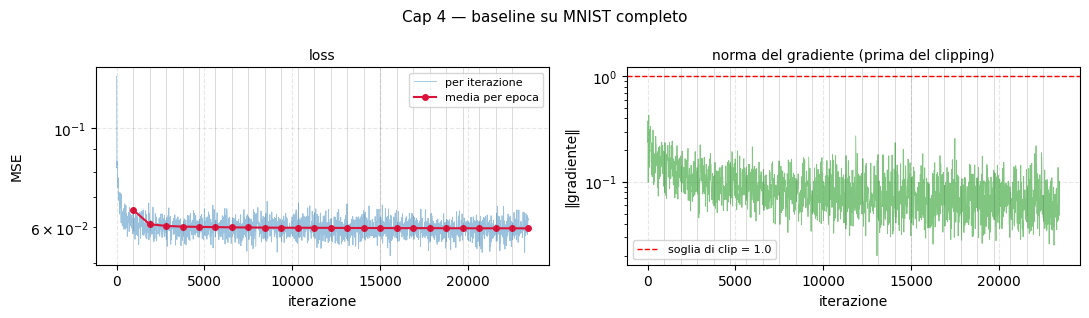

loss media per epoca: prima 0.06562 → ultima 0.05968 (25 epoche)


In [ ]:
model_base = ConditionalNCA(cfg).to(cfg.device)
model_base, hist_base, _ = load_or_train(
    model_base, "c_nca_mnist",
    lambda m: train_nca(m, train_loader, cfg,
                        monitor=LiveMonitor(cfg, plot_every=50,
                                            preview_steps=256, preview_every=32)),
    cfg)

plot_history(hist_base, cfg, "Cap 4 — baseline su MNIST completo")

### 4.2 - Test

I quattro test: crescita e omeostasi, resilienza ai danni,
interpolazione del condizionamento, plasticità.

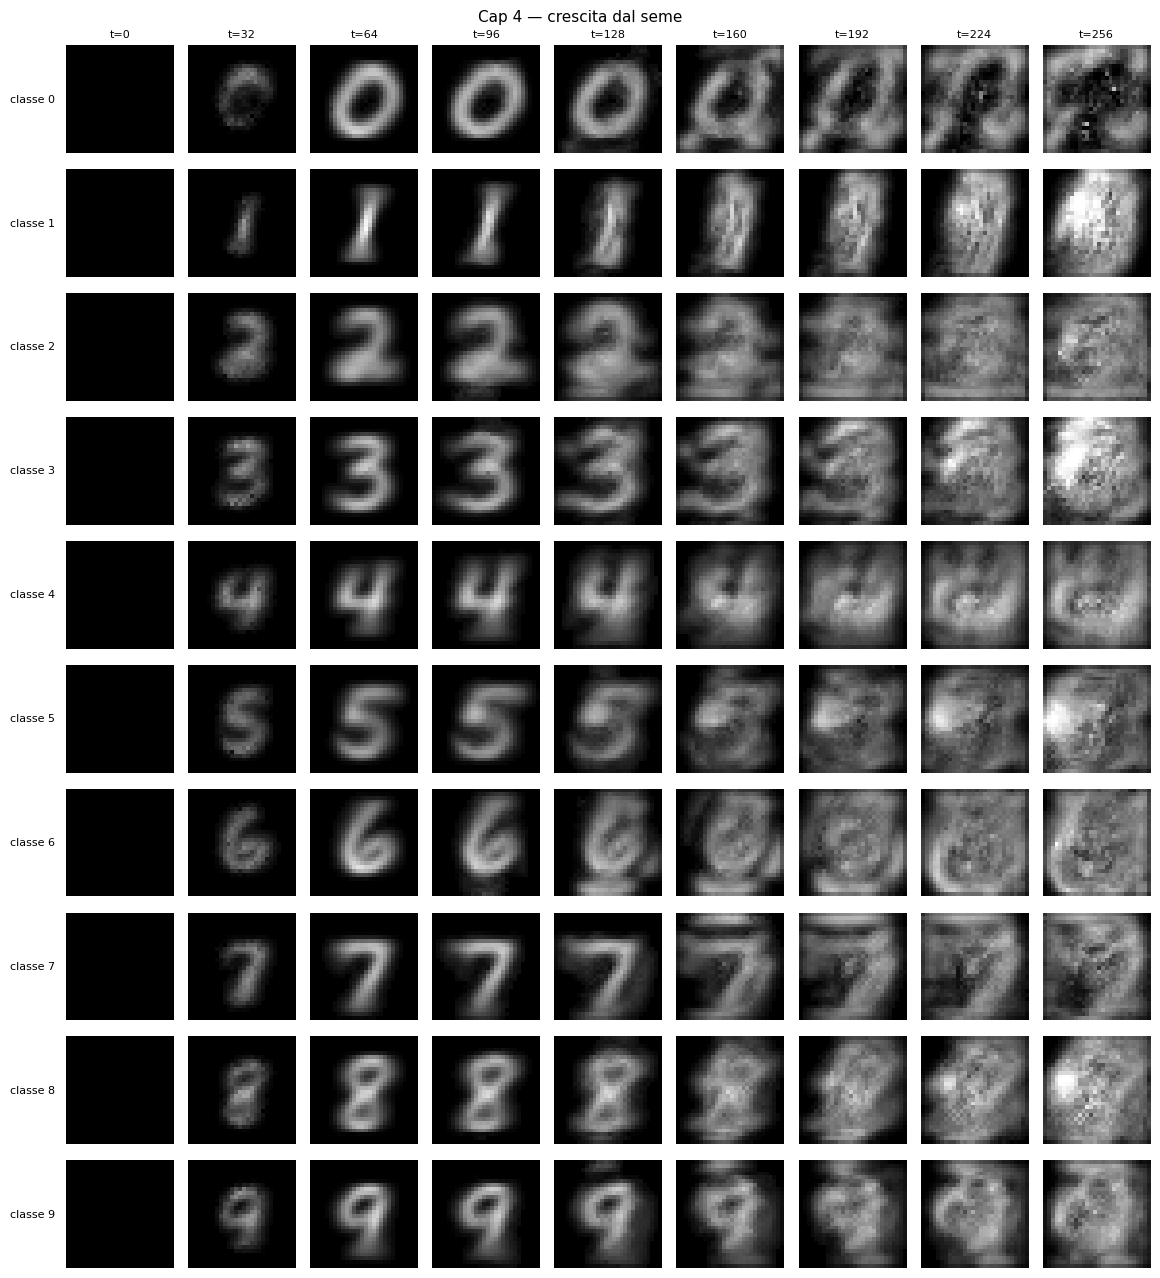

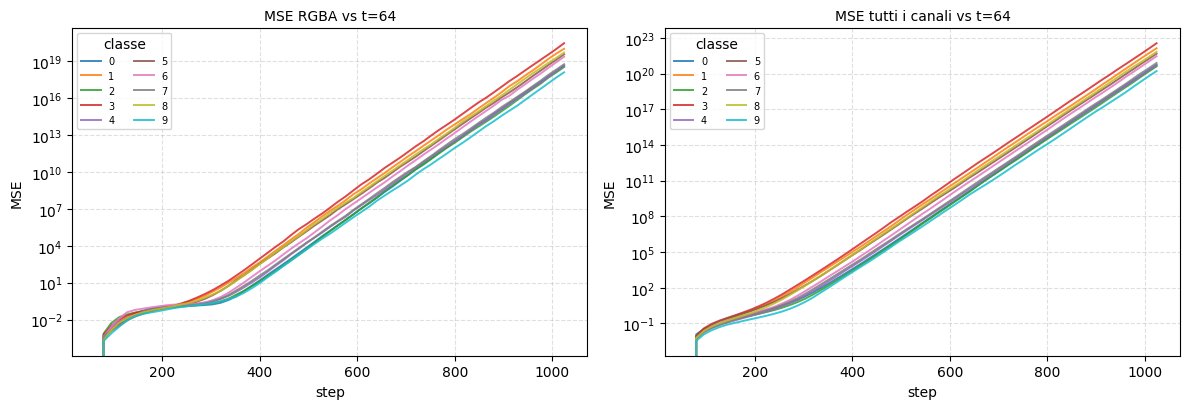

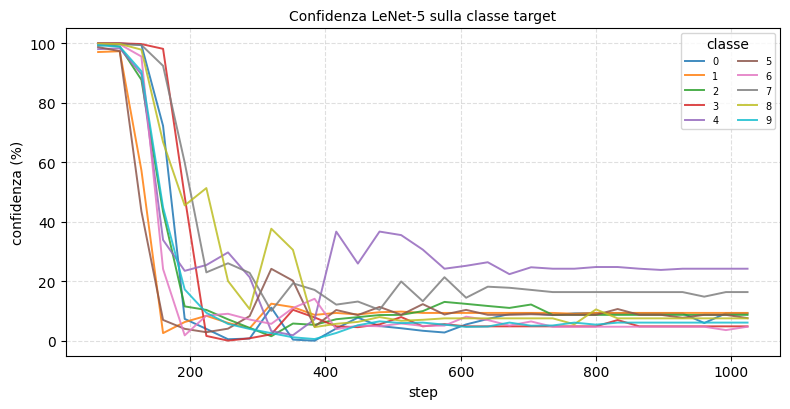

In [ ]:
# --- crescita e stabilita' nel tempo ----------------------------------------
show_growth(model_base, cfg, max_steps=256, every=32,
            title="Cap 4 — crescita dal seme")
df_home_base = homeostasis(model_base, cfg, max_steps=1024, ref_step=64,
                           every=16, seed=42)
df_lenet_base = lenet_confidence(model_base, lenet, cfg, max_steps=1024,
                                 ref_step=64, every=32, seed=42)

In [ ]:
final_step = df_home_base['step'].max()
mean_mse = df_home_base[df_home_base['step'] == final_step]['mse_rgba'].mean()
mean_conf = df_lenet_base[df_lenet_base['step'] == final_step]['confidence'].mean()
print(f"A t={final_step}: Loss media (MSE RGBA) = {mean_mse:.5f}, Confidenza LeNet media = {mean_conf:.2f}%")

A t=1024: Loss media (MSE RGBA) = 51490027301656485888.00000, Confidenza LeNet media = 9.89%


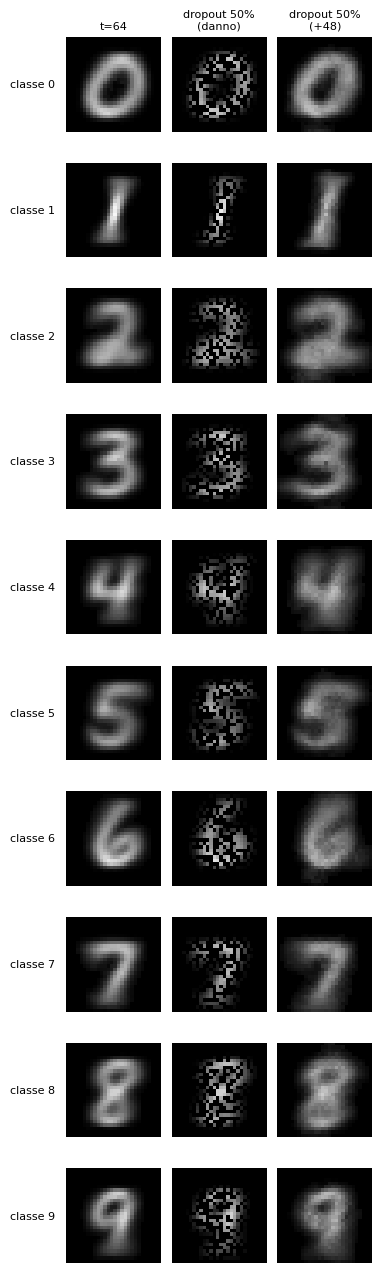

MSE RGBA dopo recupero,dropout 50%
digit,
0,0.0054
1,0.0045
2,0.0082
3,0.0069
4,0.0062
5,0.0045
6,0.0059
7,0.0032
8,0.0054


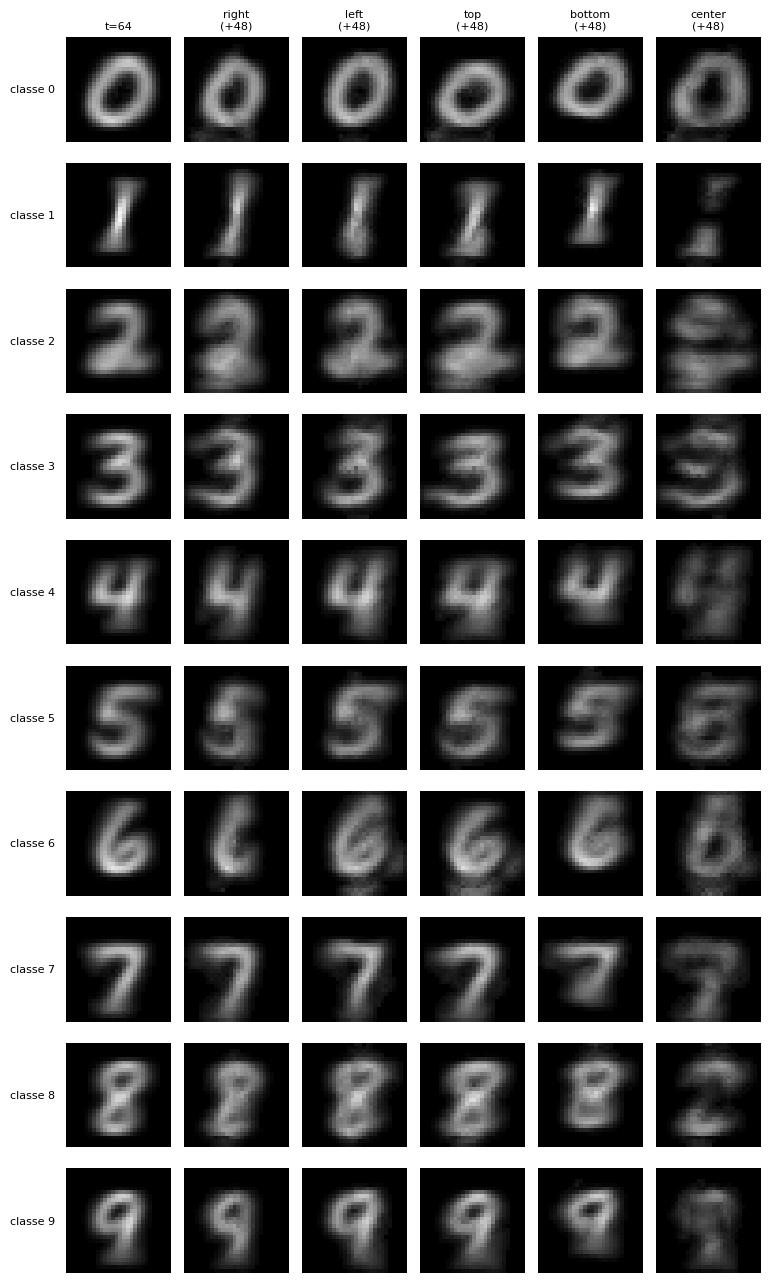

MSE RGBA dopo recupero,bottom,center,left,right,top
digit,,,,,
0,0.0234,0.0151,0.0069,0.0214,0.0126
1,0.0046,0.0211,0.0047,0.0059,0.0059
2,0.0123,0.0319,0.0047,0.0204,0.0113
3,0.0185,0.0200,0.0060,0.0125,0.0055
4,0.0067,0.0183,0.0040,0.0088,0.0042
5,0.0106,0.0104,0.0022,0.0072,0.0037
6,0.0131,0.0223,0.0113,0.0147,0.0122
7,0.0076,0.0134,0.0037,0.0067,0.0024
8,0.0092,0.0251,0.0042,0.0068,0.0040


In [ ]:
# --- resilienza ai danni ----------------------------------------------------
df_rnd_base = damage_experiment(model_base, cfg, {"dropout 50%": dropout_damage(0.5)},
                                steps_grow=64, steps_recover=48, seed=42,
                                show_damaged=True)
df_loc_base = damage_experiment(model_base, cfg, localized_damage_set(cfg),
                                steps_grow=64, steps_recover=48, seed=42)

In [ ]:
mean_recovery_loss = df_loc_base['mse_rgba'].mean()
print(f"Media della loss (MSE RGBA) dopo recupero per danni localizzati: {mean_recovery_loss:.5f}")

Media della loss (MSE RGBA) dopo recupero per danni localizzati: 0.01068


In [ ]:
# --- interpolazione fra due classi ------------------------------------------
_ = interpolation_widget(model_base, cfg)

interactive(children=(IntSlider(value=0, description='classe A', max=9), IntSlider(value=1, description='class…

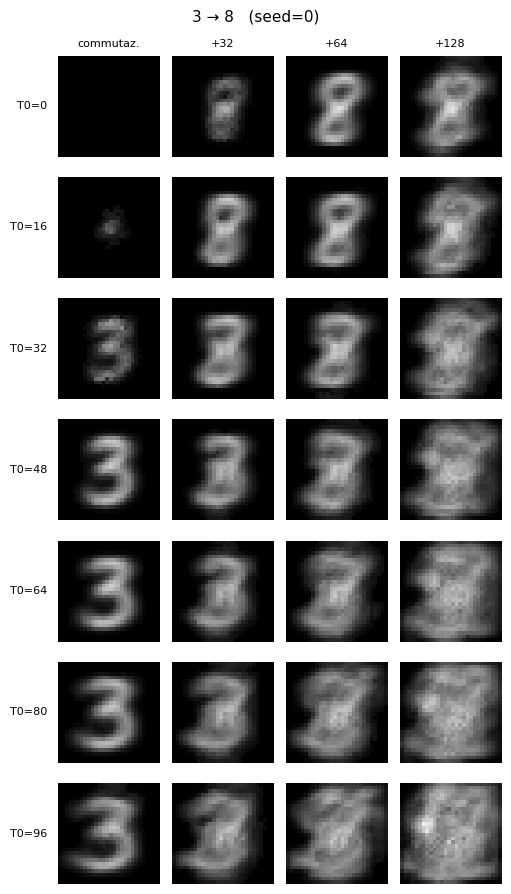

p_new_avg  p_new_sd  p_old_avg  p_old_sd  alive_avg  alive_sd  n_seed
t0 t1                                                                        
0  32       0.926     0.019      0.013     0.004    256.375     8.158       8
   64       0.999     0.000      0.000     0.000    382.375     1.061       8
   128      0.982     0.006      0.002     0.001    545.000     6.481       8
16 32       0.975     0.025      0.010     0.016    354.250     2.964       8
   64       0.998     0.000      0.000     0.000    399.500     5.831       8
   128      0.944     0.022      0.006     0.003    588.625     3.114       8
32 32       0.572     0.191      0.369     0.183    388.625     3.503       8
   64       0.988     0.005      0.005     0.003    459.125     4.422       8
   128      0.745     0.049      0.043     0.009    652.625     8.297       8
48 32       0.059     0.017      0.898     0.022    420.750     4.862       8
   64       0.735     0.134      0.202     0.115    534.500     7.690       8
   128      0.528     0.138      0.064     0.023    707.375     5.829       8
64 32       0.047     0.015      0.891     0.025    482.000     4.342       8
   64       0.719     0.099      0.171     0.071    608.750    11.659       8
   128      0.353     0.104      0.070     0.012    736.375     5.012       8
80 32       0.061     0.017      0.844     0.032    540.250     6.563       8
   64       0.752     0.057      0.117     0.036    664.500     6.845       8
   128      0.248     0.055      0.053     0.018    755.250     4.621       8
96 32       0.113     0.042      0.701     0.076    603.750     8.379       8
   64       0.631     0.098      0.169     0.068    712.875     7.586       8
   128      0.126     0.035      0.031     0.029    773.375     3.068       8

coppie di classi (T1=128):   0%|          | 0/90 [00:00<?, ?it/s]

T1=128  T0=32                       T0=64                       T0=96         \
misura  p_new         p_old         p_new         p_old         p_new          
stat      avg     sd    avg     sd    avg     sd    avg     sd    avg     sd   
coppia                                                                         
0→1     0.035  0.012  0.030  0.011  0.024  0.006  0.421  0.133  0.044  0.024   
0→2     0.423  0.065  0.040  0.007  0.167  0.051  0.116  0.019  0.176  0.080   
0→3     0.968  0.016  0.000  0.000  0.229  0.099  0.085  0.046  0.042  0.023   
0→4     0.196  0.034  0.070  0.017  0.146  0.046  0.165  0.074  0.118  0.045   
0→5     0.047  0.011  0.024  0.009  0.081  0.018  0.178  0.059  0.433  0.151   
...       ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
9→4     0.198  0.026  0.089  0.015  0.104  0.023  0.050  0.018  0.076  0.018   
9→5     0.192  0.036  0.076  0.016  0.164  0.033  0.026  0.004  0.129  0.025   
9→6     0.307  0.094  0.027  0.011  0.239  0.070  0.020  0.007  0.157  0.034   
9→7     0.909  0.034  0.015  0.008  0.859  0.034  0.041  0.007  0.443  0.153   
9→8     0.685  0.063  0.049  0.008  0.200  0.039  0.067  0.014  0.171  0.030   

T1=128               T0=128                       
misura  p_old         p_new         p_old         
stat      avg     sd    avg     sd    avg     sd  
coppia                                            
0→1     0.431  0.118  0.042  0.014  0.376  0.103  
0→2     0.133  0.054  0.132  0.030  0.133  0.043  
0→3     0.076  0.046  0.006  0.004  0.151  0.069  
0→4     0.236  0.081  0.113  0.042  0.296  0.160  
0→5     0.041  0.031  0.406  0.118  0.053  0.027  
...       ...    ...    ...    ...    ...    ...  
9→4     0.034  0.015  0.124  0.019  0.024  0.008  
9→5     0.014  0.004  0.098  0.015  0.011  0.002  
9→6     0.033  0.013  0.152  0.035  0.037  0.007  
9→7     0.208  0.121  0.285  0.099  0.133  0.054  
9→8     0.057  0.019  0.162  0.061  0.041  0.012  

[90 rows x 16 columns]

In [ ]:
# --- plasticita': una coppia in dettaglio, poi tutte le 90 coppie -----------
T0 = [0, 16, 32, 48, 64, 80, 96]
T1 = [32, 64, 128]
df_switch_base = switch_study(model_base, lenet, cfg, 3, 8, T0, T1, seeds=range(8))
display(df_switch_base.round(3))

mat_base = plasticity_matrix(model_base, lenet, cfg, [32, 64, 96, 128],
                             t1=128, seeds=range(8))
display(mat_base.round(3))

## Cap 5: Baseline su target fissi

A differenza del Capitolo 4, qui i bersagli sono immagini fisse (la medie delle classi). Inoltre ad ogni training step, per ogni classe vengono generati 8 stati e  fatti evolvere per 64 steps, formando così un batch di 80.



### 5.1 - Addestramento

[ckpt] pesi caricati da /content/drive/MyDrive/ProgettoDLAI/c_nca_mnist_fix.pth — training saltato


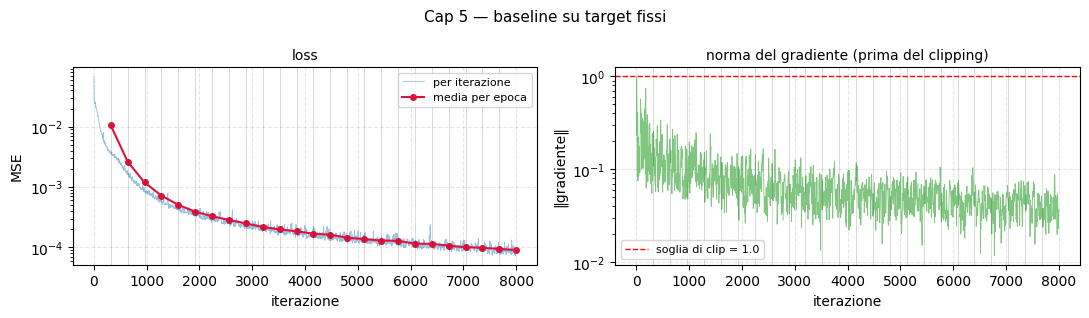

loss media per epoca: prima 0.01058 → ultima 0.00009 (25 epoche)


In [ ]:
model_base_fix = ConditionalNCA(cfg).to(cfg.device)
model_base_fix, hist_base_fix, _ = load_or_train(
    model_base_fix, "c_nca_mnist_fix",
    lambda m: train_nca_fixed(m, TARGETS_FIX, cfg, mode="baseline",
                              monitor=LiveMonitor(cfg, plot_every=20,
                                                  preview_steps=256, preview_every=32)),
    cfg)

plot_history(hist_base_fix, cfg, "Cap 5 — baseline su target fissi")

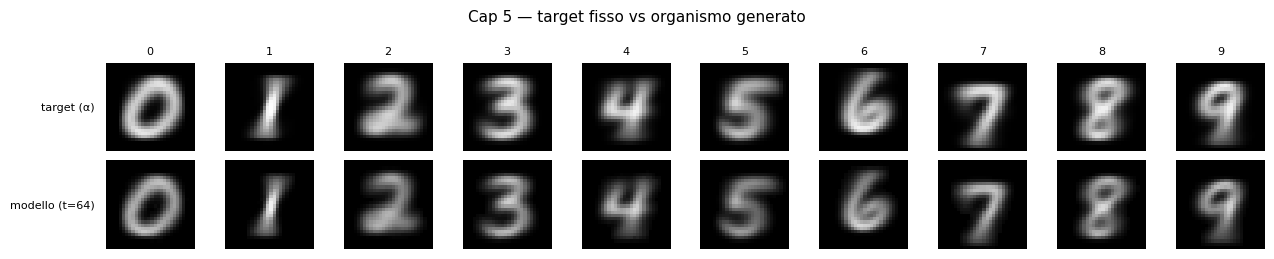

In [ ]:
# il target accanto a cio' che il modello produce: il confronto piu' informativo
out_fix, _ = grow(model_base_fix, onehot(torch.arange(10, device=cfg.device), cfg),
                  cfg.n_steps, cfg)
plot_grid([[TARGETS_FIX[d, 3].cpu().numpy() for d in range(10)],
           [as_image(out_fix, d, cfg) for d in range(10)]],
          row_labels=["target (α)", f"modello (t={cfg.n_steps})"],
          col_labels=[str(d) for d in range(10)],
          title="Cap 5 — target fisso vs organismo generato")

### 5.2 - Test

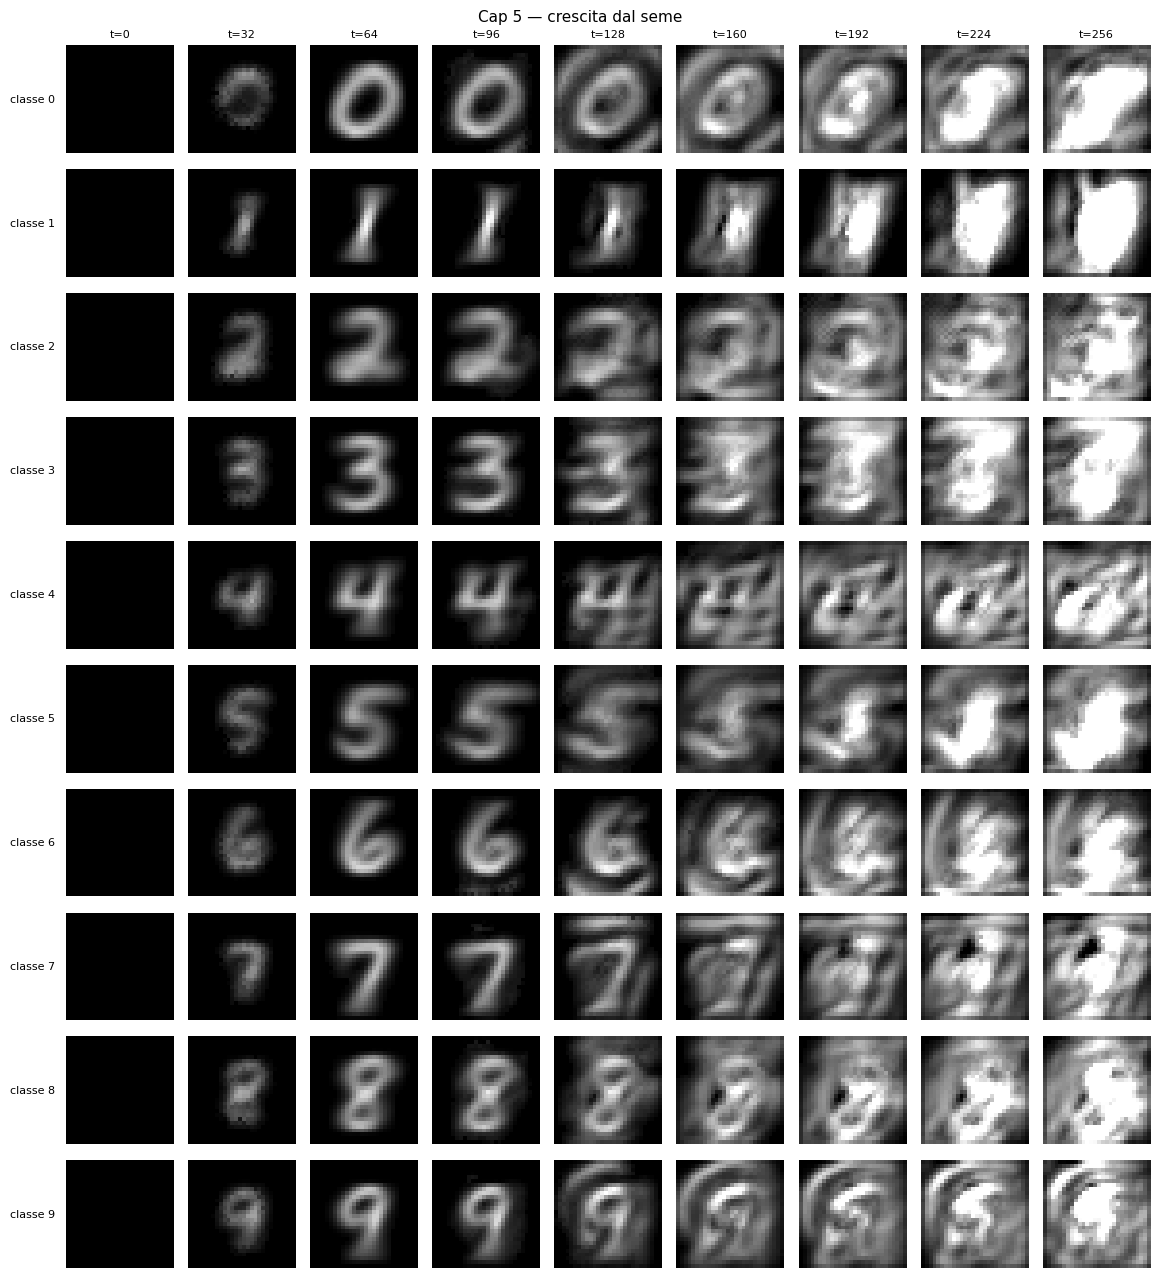

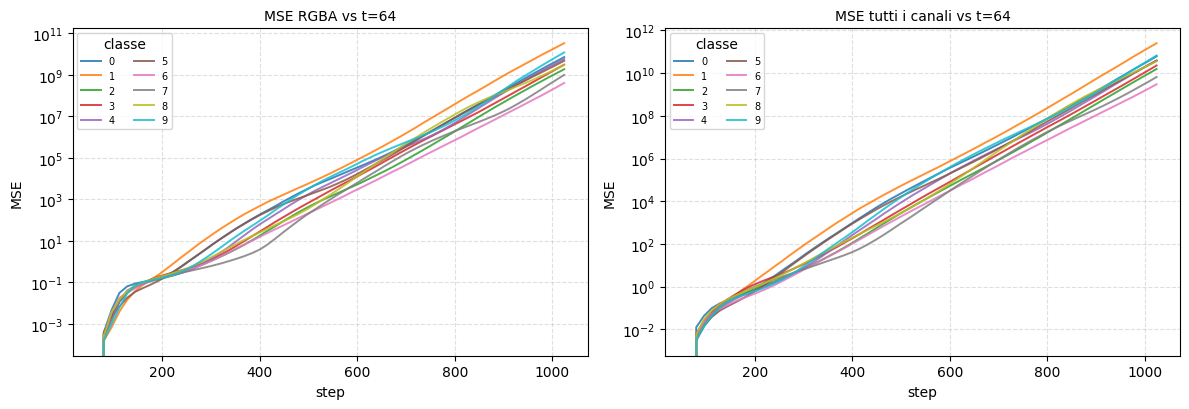

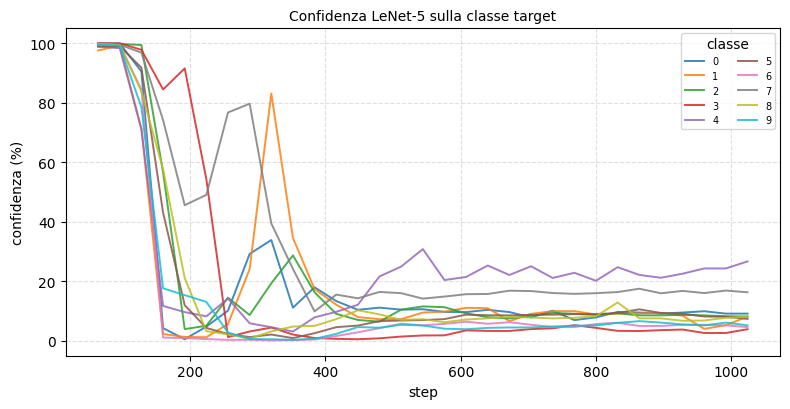

In [ ]:
# --- crescita e stabilita' nel tempo ----------------------------------------
show_growth(model_base_fix, cfg, max_steps=256, every=32,
            title="Cap 5 — crescita dal seme")
df_home_base_fix = homeostasis(model_base_fix, cfg, max_steps=1024, ref_step=64,
                               every=16, seed=42)
df_lenet_base_fix = lenet_confidence(model_base_fix, lenet, cfg, max_steps=1024,
                                     ref_step=64, every=32, seed=42)

In [ ]:
final_step = df_home_base_fix['step'].max()
mean_mse = df_home_base_fix[df_home_base_fix['step'] == final_step]['mse_rgba'].mean()
mean_conf = df_lenet_base_fix[df_lenet_base_fix['step'] == final_step]['confidence'].mean()
print(f"A t={final_step}: Loss media (MSE RGBA) = {mean_mse:.5f}, Confidenza LeNet media = {mean_conf:.2f}%")

A t=1024: Loss media (MSE RGBA) = 7261545571.20000, Confidenza LeNet media = 9.76%


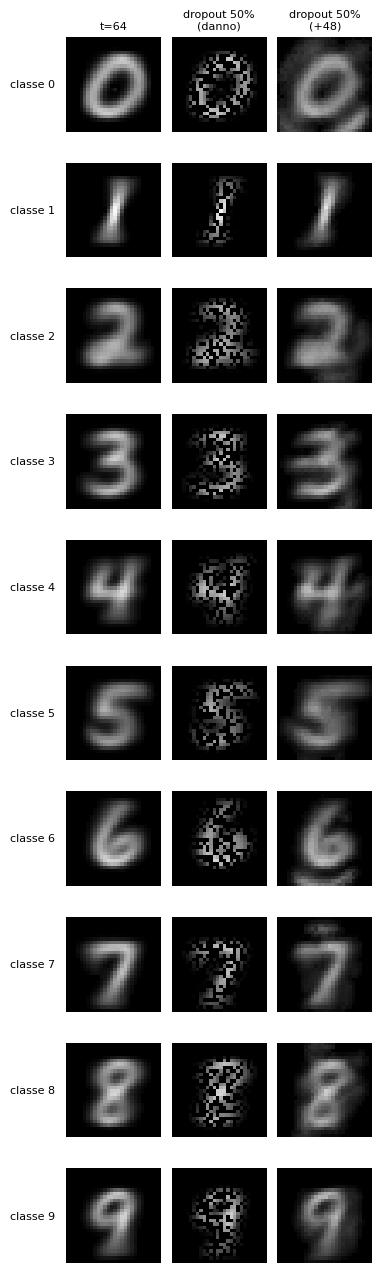

MSE RGBA dopo recupero,dropout 50%
digit,
0,0.0273
1,0.0014
2,0.0064
3,0.0068
4,0.0056
5,0.0037
6,0.0125
7,0.0052
8,0.0057


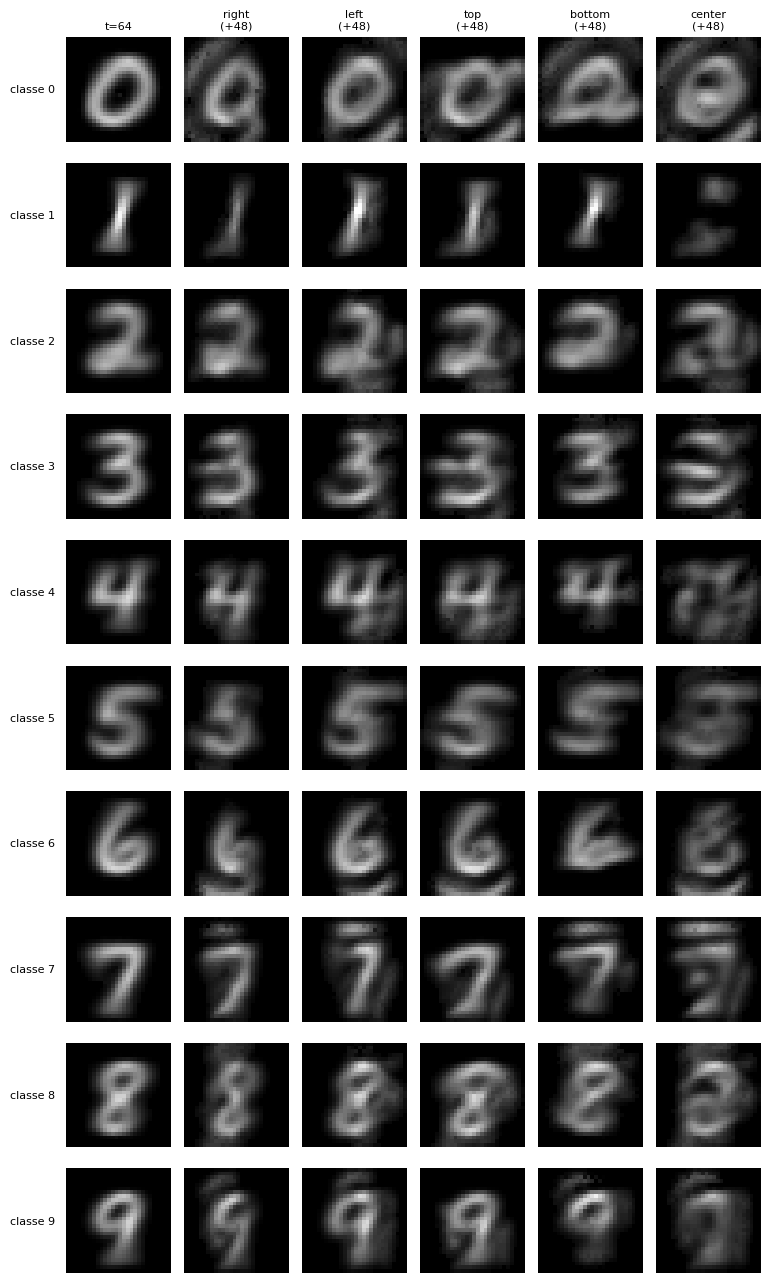

MSE RGBA dopo recupero,bottom,center,left,right,top
digit,,,,,
0,0.0315,0.0462,0.0212,0.0389,0.0303
1,0.0043,0.0231,0.0036,0.0120,0.0038
2,0.0127,0.0156,0.0118,0.0121,0.0102
3,0.0062,0.0221,0.0093,0.0189,0.0131
4,0.0062,0.0264,0.0096,0.0096,0.0095
5,0.0062,0.0147,0.0033,0.0142,0.0049
6,0.0094,0.0275,0.0111,0.0275,0.0201
7,0.0136,0.0298,0.0193,0.0129,0.0072
8,0.0110,0.0212,0.0076,0.0152,0.0103


In [ ]:
# --- resilienza ai danni ----------------------------------------------------
df_rnd_base_fix = damage_experiment(model_base_fix, cfg,
                                    {"dropout 50%": dropout_damage(0.5)},
                                    steps_grow=64, steps_recover=48, seed=42,
                                    show_damaged=True)
df_loc_base_fix = damage_experiment(model_base_fix, cfg, localized_damage_set(cfg),
                                    steps_grow=64, steps_recover=48, seed=42)

In [ ]:
mean_recovery_loss = df_loc_base_fix['mse_rgba'].mean()
print(f"Media della loss (MSE RGBA) dopo recupero per danni localizzati: {mean_recovery_loss:.5f}")

Media della loss (MSE RGBA) dopo recupero per danni localizzati: 0.01496


In [ ]:
# --- interpolazione fra due classi ------------------------------------------
_ = interpolation_widget(model_base_fix, cfg)

interactive(children=(IntSlider(value=0, description='classe A', max=9), IntSlider(value=1, description='class…

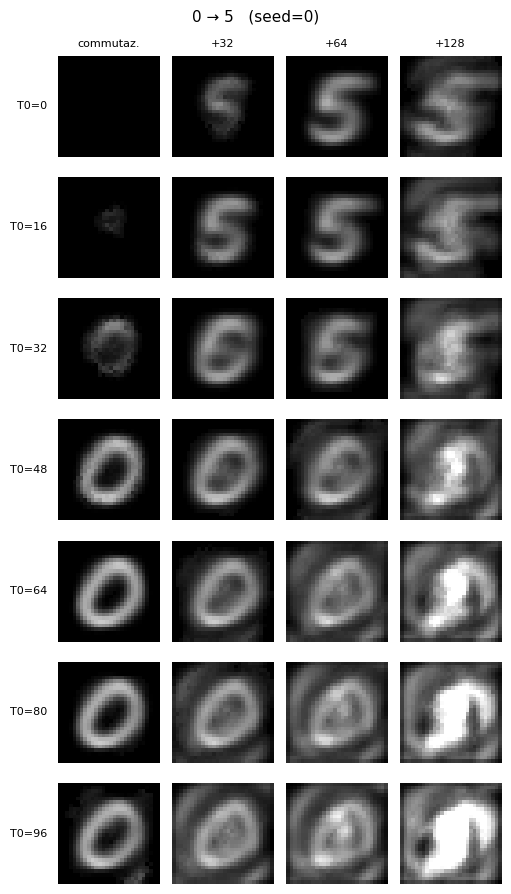

p_new_avg  p_new_sd  p_old_avg  p_old_sd  alive_avg  alive_sd  n_seed
t0 t1                                                                        
0  32       0.228     0.145      0.003     0.001    262.125    13.400       8
   64       0.989     0.001      0.000     0.000    414.500     2.928       8
   128      0.934     0.023      0.000     0.000    692.500     9.856       8
16 32       0.922     0.020      0.002     0.001    377.000     5.210       8
   64       0.986     0.002      0.000     0.000    416.250     1.982       8
   128      0.884     0.059      0.000     0.000    749.000     5.292       8
32 32       0.225     0.060      0.441     0.108    432.000     2.976       8
   64       0.742     0.066      0.023     0.010    456.500     8.452       8
   128      0.295     0.158      0.027     0.020    756.375     4.749       8
48 32       0.003     0.001      0.969     0.005    480.625     9.380       8
   64       0.071     0.020      0.565     0.065    716.500    17.271       8
   128      0.015     0.017      0.005     0.003    782.875     0.354       8
64 32       0.001     0.000      0.982     0.003    653.250    15.031       8
   64       0.018     0.008      0.802     0.073    780.875     0.354       8
   128      0.002     0.001      0.002     0.001    783.000     0.000       8
80 32       0.001     0.000      0.979     0.005    752.625     9.180       8
   64       0.021     0.009      0.604     0.157    780.750     0.463       8
   128      0.003     0.001      0.013     0.010    782.500     0.756       8
96 32       0.002     0.001      0.947     0.015    775.125     1.808       8
   64       0.020     0.004      0.311     0.144    782.500     0.926       8
   128      0.004     0.001      0.043     0.062    783.625     0.518       8

coppie di classi (T1=128):   0%|          | 0/90 [00:00<?, ?it/s]

T1=128  T0=32                       T0=64                       T0=96         \
misura  p_new         p_old         p_new         p_old         p_new          
stat      avg     sd    avg     sd    avg     sd    avg     sd    avg     sd   
coppia                                                                         
0→1     0.009  0.005  0.001  0.001  0.012  0.001  0.533  0.092  0.017  0.006   
0→2     0.039  0.027  0.001  0.000  0.017  0.012  0.002  0.001  0.016  0.004   
0→3     0.676  0.147  0.008  0.006  0.249  0.130  0.137  0.044  0.064  0.015   
0→4     0.009  0.005  0.000  0.000  0.014  0.007  0.201  0.082  0.060  0.031   
0→5     0.257  0.186  0.031  0.022  0.002  0.001  0.003  0.002  0.004  0.001   
...       ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
9→4     0.026  0.008  0.111  0.065  0.027  0.007  0.106  0.029  0.216  0.071   
9→5     0.019  0.009  0.317  0.040  0.010  0.006  0.465  0.068  0.003  0.001   
9→6     0.009  0.003  0.074  0.028  0.010  0.003  0.197  0.057  0.007  0.004   
9→7     0.169  0.036  0.104  0.020  0.049  0.016  0.064  0.017  0.114  0.080   
9→8     0.039  0.016  0.071  0.010  0.075  0.042  0.060  0.013  0.005  0.002   

T1=128               T0=128                       
misura  p_old         p_new         p_old         
stat      avg     sd    avg     sd    avg     sd  
coppia                                            
0→1     0.495  0.168  0.026  0.005  0.524  0.068  
0→2     0.024  0.010  0.007  0.002  0.015  0.004  
0→3     0.155  0.024  0.064  0.009  0.141  0.021  
0→4     0.011  0.006  0.298  0.046  0.009  0.002  
0→5     0.026  0.019  0.003  0.001  0.054  0.027  
...       ...    ...    ...    ...    ...    ...  
9→4     0.177  0.056  0.189  0.049  0.072  0.056  
9→5     0.050  0.014  0.013  0.003  0.002  0.001  
9→6     0.116  0.042  0.004  0.002  0.025  0.011  
9→7     0.010  0.006  0.130  0.129  0.013  0.010  
9→8     0.005  0.003  0.054  0.021  0.014  0.008  

[90 rows x 16 columns]

In [ ]:
# --- plasticita' ------------------------------------------------------------
T0 = [0, 16, 32, 48, 64, 80, 96]
T1 = [32, 64, 128]
df_switch_base_fix = switch_study(model_base_fix, lenet, cfg, 0, 5, T0, T1, seeds=range(8))
display(df_switch_base_fix.round(3))

mat_base_fix = plasticity_matrix(model_base_fix, lenet, cfg, [32, 64, 96, 128],
                                 t1=128, seeds=range(8))
display(mat_base_fix.round(3))

## Cap 6: Sample pool

Gli stati non ripartono più dal seme: vivono nel pool e continuano a evolvere. Il
modello è quindi progettato per aumentare la stabilità omeostatica.

Politica di refresh `"worst"` (Mordvintsev), nessun danno.

### 6.1 - Addestramento

[ckpt] pesi caricati da /content/drive/MyDrive/ProgettoDLAI/c_nca_mnist_pool_fix.pth — training saltato


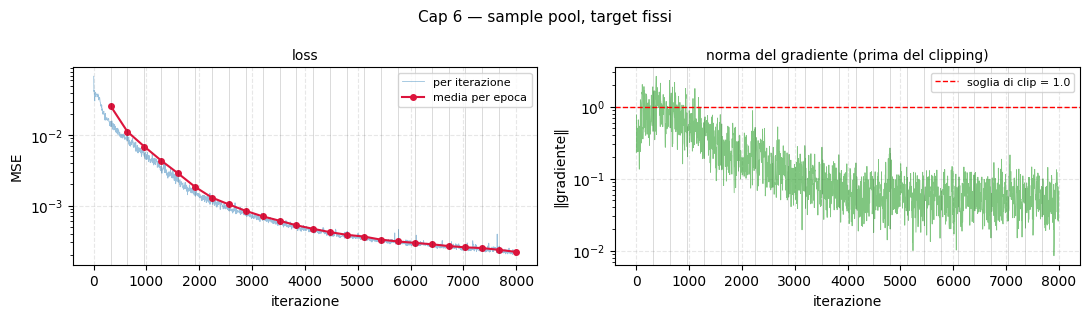

loss media per epoca: prima 0.02601 → ultima 0.00022 (25 epoche)


In [ ]:
model_pool_fix = ConditionalNCA(cfg).to(cfg.device)
model_pool_fix, hist_pool_fix, _ = load_or_train(
    model_pool_fix, "c_nca_mnist_pool_fix",
    lambda m: train_nca_fixed(m, TARGETS_FIX, cfg, mode="pool",
                              monitor=LiveMonitor(cfg, plot_every=20,
                                                  preview_steps=2048, preview_every=256)),
    cfg)

plot_history(hist_pool_fix, cfg, "Cap 6 — sample pool, target fissi")


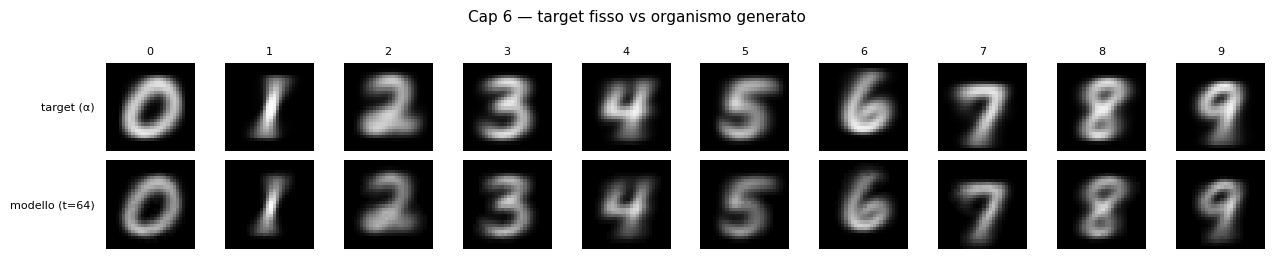

In [ ]:
out_pool, _ = grow(model_pool_fix, onehot(torch.arange(10, device=cfg.device), cfg),
                   cfg.n_steps, cfg)
plot_grid([[TARGETS_FIX[d, 3].cpu().numpy() for d in range(10)],
           [as_image(out_pool, d, cfg) for d in range(10)]],
          row_labels=["target (α)", f"modello (t={cfg.n_steps})"],
          col_labels=[str(d) for d in range(10)],
          title="Cap 6 — target fisso vs organismo generato")

### 6.2 - Test

Addestramento a target fissi con pooling, che nei capitoli 4 e 5: qui la domanda è proprio se
l'organismo regge oltre il tempo di addestramento.

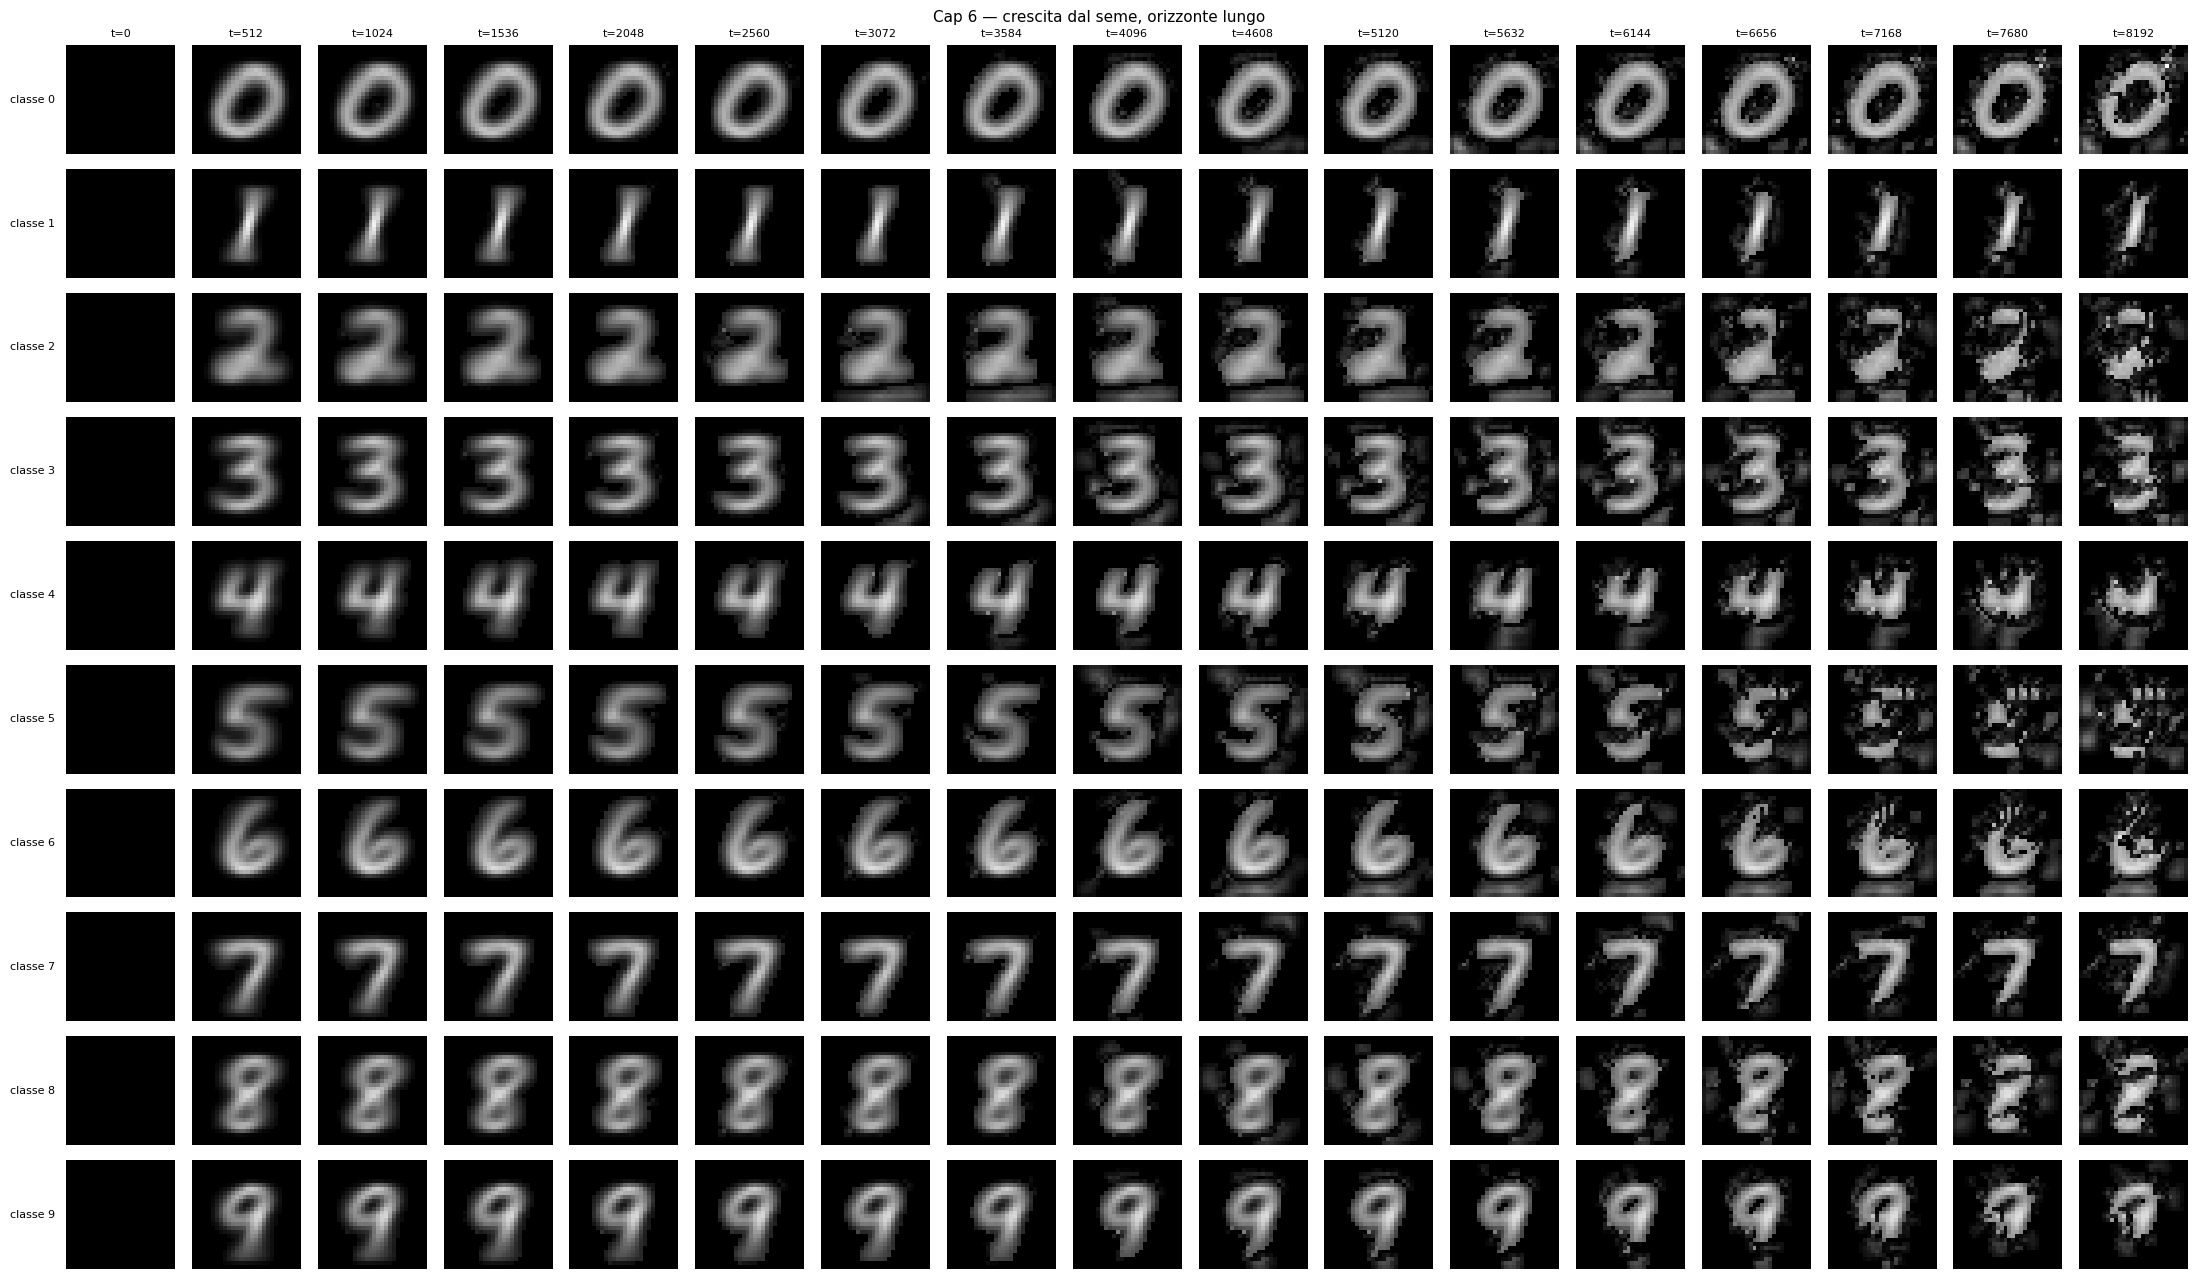

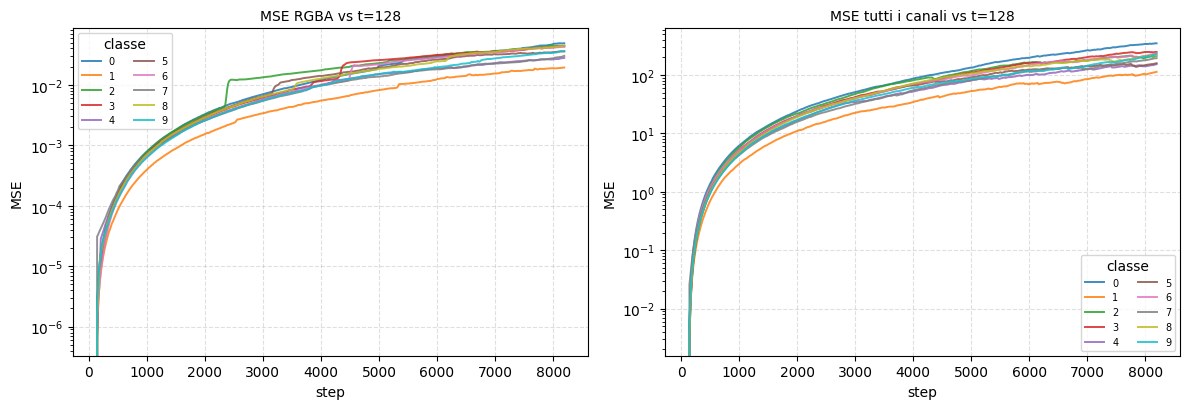

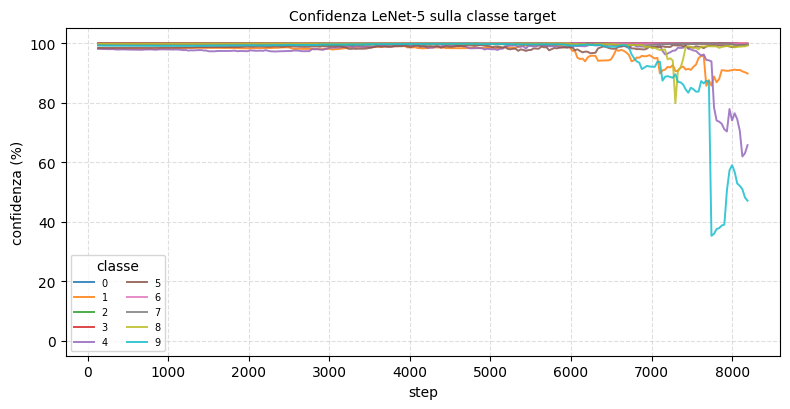

In [ ]:
# --- crescita e stabilita' nel tempo ----------------------------------------
show_growth(model_pool_fix, cfg, max_steps=8192, every=512,
            title="Cap 6 — crescita dal seme, orizzonte lungo")
df_home_pool_fix = homeostasis(model_pool_fix, cfg, max_steps=8192,ref_step=128,
                               every=16, seed=42)
df_lenet_pool_fix = lenet_confidence(model_pool_fix, lenet, cfg, max_steps=8192,
                                     ref_step=128, every=32, seed=42)

In [ ]:
final_step = df_home_pool_fix['step'].max()
mean_mse = df_home_pool_fix[df_home_pool_fix['step'] == final_step]['mse_rgba'].mean()
mean_conf = df_lenet_pool_fix[df_lenet_pool_fix['step'] == final_step]['confidence'].mean()
print(f"A t={final_step}: Loss media (MSE RGBA) = {mean_mse:.5f}, Confidenza LeNet media = {mean_conf:.2f}%")

A t=4096: Loss media (MSE RGBA) = 0.01165, Confidenza LeNet media = 99.54%


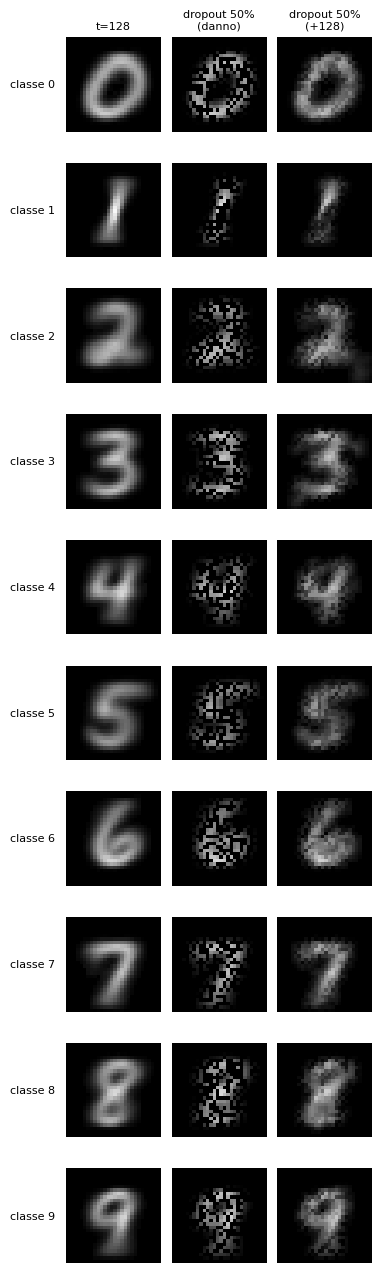

MSE RGBA dopo recupero,dropout 50%
digit,
0,0.0083
1,0.0120
2,0.0104
3,0.0068
4,0.0062
5,0.0075
6,0.0057
7,0.0054
8,0.0075


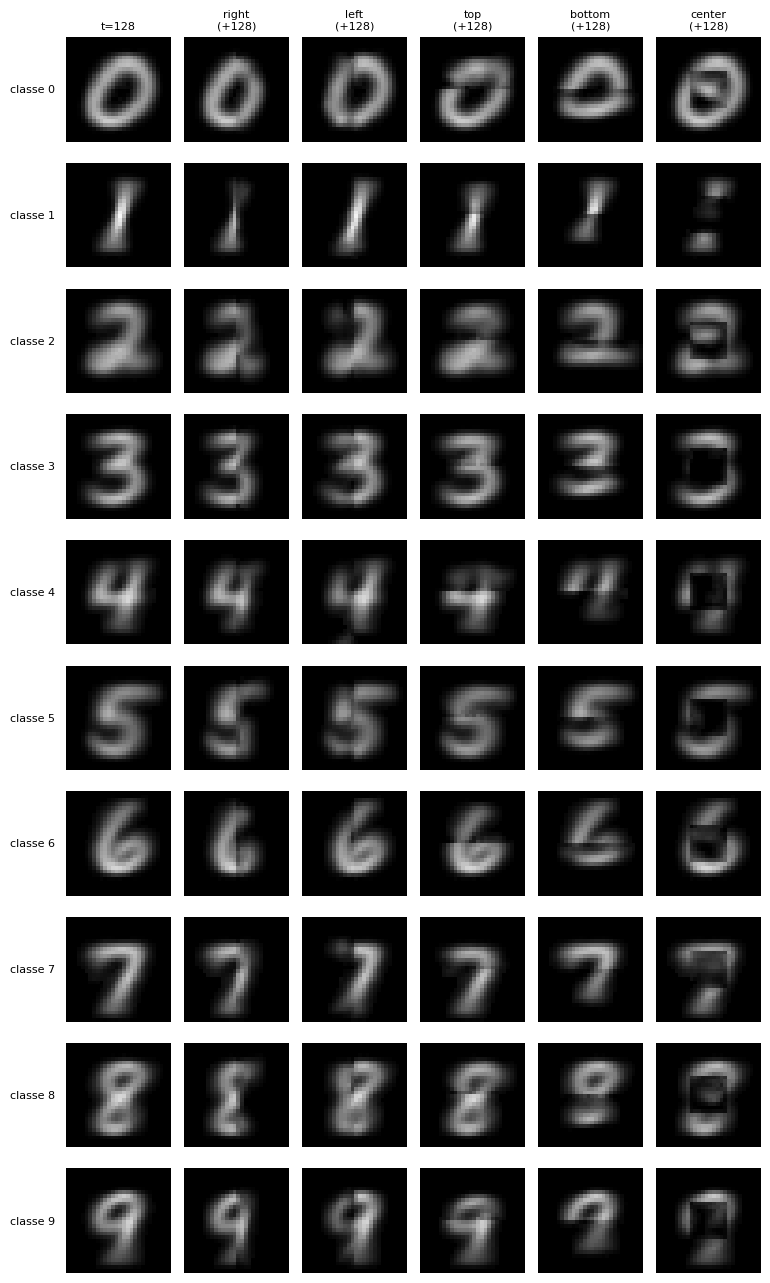

MSE RGBA dopo recupero,bottom,center,left,right,top
digit,,,,,
0,0.0214,0.0115,0.0058,0.0217,0.0061
1,0.0069,0.0193,0.0005,0.0147,0.0023
2,0.0123,0.0211,0.0047,0.0114,0.0029
3,0.0215,0.0245,0.0024,0.0130,0.0022
4,0.0201,0.0303,0.0032,0.0088,0.0061
5,0.0117,0.0182,0.0025,0.0071,0.0019
6,0.0198,0.0171,0.0020,0.0107,0.0035
7,0.0055,0.0142,0.0079,0.0119,0.0051
8,0.0178,0.0238,0.0024,0.0183,0.0025


In [ ]:
# --- resilienza ai danni ----------------------------------------------------
df_rnd_pool_fix = damage_experiment(model_pool_fix, cfg,
                                    {"dropout 50%": dropout_damage(0.5)},
                                    steps_grow=128, steps_recover=128, seed=42,
                                    show_damaged=True)
df_loc_pool_fix = damage_experiment(model_pool_fix, cfg, localized_damage_set(cfg),
                                    steps_grow=128, steps_recover=128, seed=42)

In [ ]:
mean_recovery_loss = df_loc_pool_fix['mse_rgba'].mean()
print(f"Media della loss (MSE RGBA) dopo recupero per danni localizzati: {mean_recovery_loss:.5f}")

Media della loss (MSE RGBA) dopo recupero per danni localizzati: 0.01120


In [ ]:
# --- interpolazione fra due classi ------------------------------------------
_ = interpolation_widget(model_pool_fix, cfg)

interactive(children=(IntSlider(value=0, description='classe A', max=9), IntSlider(value=1, description='class…

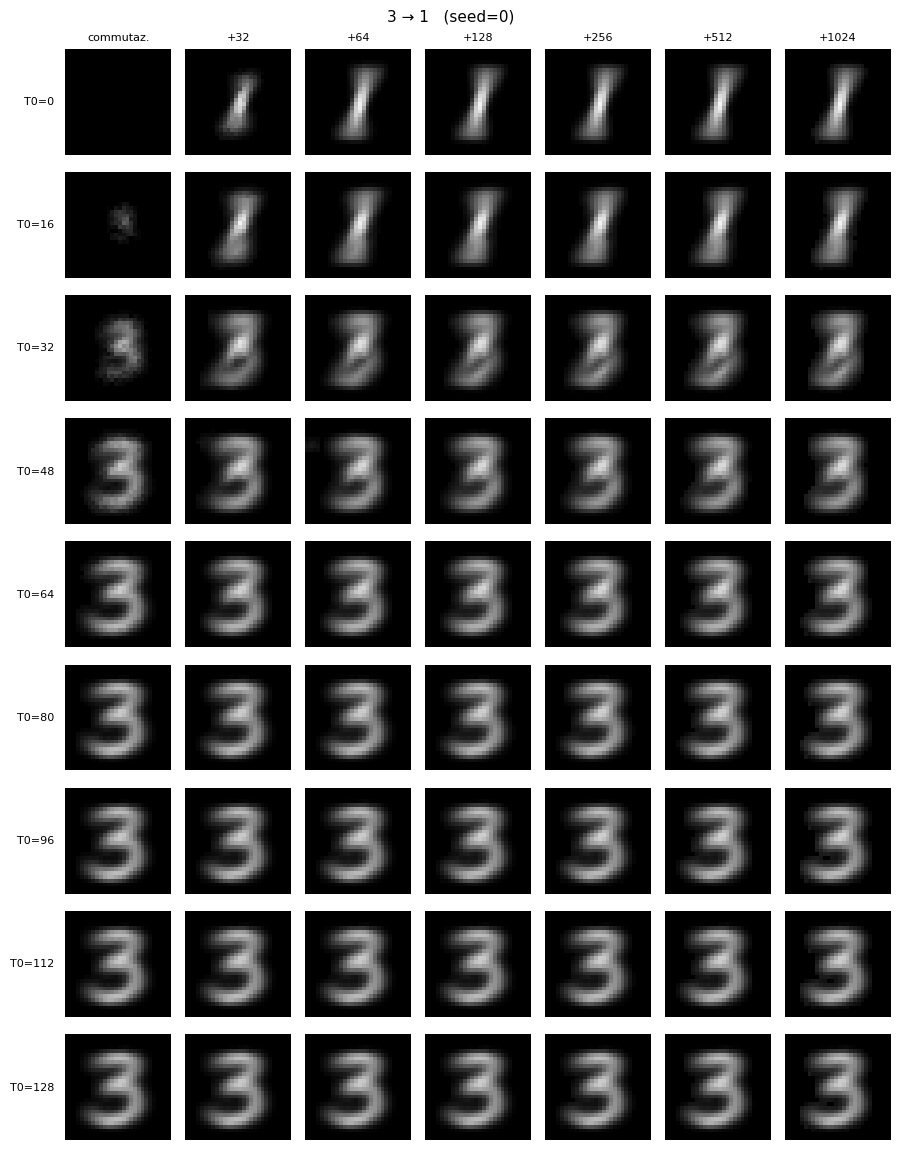

p_new_avg  p_new_sd  p_old_avg  p_old_sd  alive_avg  alive_sd  \
t0  t1                                                                    
0   32        0.690     0.067      0.001     0.001    179.375    10.980   
    64        0.967     0.006      0.000     0.000    234.500     2.878   
    128       0.971     0.005      0.000     0.000    230.500     4.781   
    256       0.970     0.005      0.000     0.000    226.875     3.357   
    512       0.970     0.005      0.000     0.000    222.750     4.621   
    1024      0.969     0.005      0.000     0.000    208.250     2.712   
16  32        0.415     0.133      0.004     0.002    273.750     6.798   
    64        0.801     0.076      0.001     0.001    278.375     4.033   
    128       0.819     0.068      0.001     0.001    274.000     4.986   
    256       0.810     0.071      0.001     0.001    267.375     5.317   
    512       0.809     0.077      0.001     0.001    259.000     7.111   
    1024      0.820     0.065      0.001     0.001    240.625     4.307   
32  32        0.003     0.002      0.904     0.096    357.750     4.268   
    64        0.006     0.003      0.793     0.144    352.000    10.810   
    128       0.006     0.003      0.837     0.118    342.250     4.166   
    256       0.006     0.003      0.852     0.112    334.125     4.883   
    512       0.006     0.003      0.848     0.108    324.875     5.083   
    1024      0.006     0.003      0.825     0.121    302.750     2.765   
48  32        0.000     0.000      0.999     0.000    390.875     5.718   
    64        0.000     0.000      0.998     0.001    385.250     6.777   
    128       0.000     0.000      0.998     0.001    376.875     2.357   
    256       0.000     0.000      0.998     0.001    372.250     2.605   
    512       0.000     0.000      0.997     0.001    360.625     3.204   
    1024      0.000     0.000      0.997     0.001    336.000     2.000   
64  32        0.000     0.000      1.000     0.000    391.000     2.204   
    64        0.000     0.000      1.000     0.000    388.250     2.435   
    128       0.000     0.000      1.000     0.000    384.625     1.061   
    256       0.000     0.000      1.000     0.000    380.875     1.126   
    512       0.000     0.000      1.000     0.000    374.250     2.252   
    1024      0.000     0.000      1.000     0.000    352.250     2.866   
80  32        0.000     0.000      1.000     0.000    405.500     2.878   
    64        0.000     0.000      1.000     0.000    403.125     2.949   
    128       0.000     0.000      1.000     0.000    400.875     2.031   
    256       0.000     0.000      1.000     0.000    393.375     3.926   
    512       0.000     0.000      1.000     0.000    380.625     2.326   
    1024      0.000     0.000      1.000     0.000    363.625     1.302   
96  32        0.000     0.000      1.000     0.000    408.875     1.808   
    64        0.000     0.000      1.000     0.000    407.125     1.642   
    128       0.000     0.000      1.000     0.000    403.625     2.722   
    256       0.000     0.000      1.000     0.000    397.125     2.588   
    512       0.000     0.000      1.000     0.000    386.125     2.696   
    1024      0.000     0.000      1.000     0.000    364.750     2.493   
112 32        0.000     0.000      1.000     0.000    408.125     1.458   
    64        0.000     0.000      1.000     0.000    406.750     1.753   
    128       0.000     0.000      1.000     0.000    403.750     2.816   
    256       0.000     0.000      1.000     0.000    397.000     2.673   
    512       0.000     0.000      1.000     0.000    385.875     2.475   
    1024      0.000     0.000      1.000     0.000    364.125     2.416   
128 32        0.000     0.000      1.000     0.000    407.875     1.553   
    64        0.000     0.000      1.000     0.000    406.875     1.959   
    128       0.000     0.000      1.000     0.000    403.750     2.964   
    256       0.000     0.000      

In [ ]:
# --- plasticita'singola coppia ------------------------------------------------------------
T0 = [0, 16, 32, 48, 64, 80, 96, 112, 128]
T1 = [32, 64, 128, 256, 512, 1024]
df_switch_pool_fix = switch_study(model_pool_fix, lenet, cfg, 3, 1, T0, T1, seeds=range(8))
display(df_switch_pool_fix.round(3))

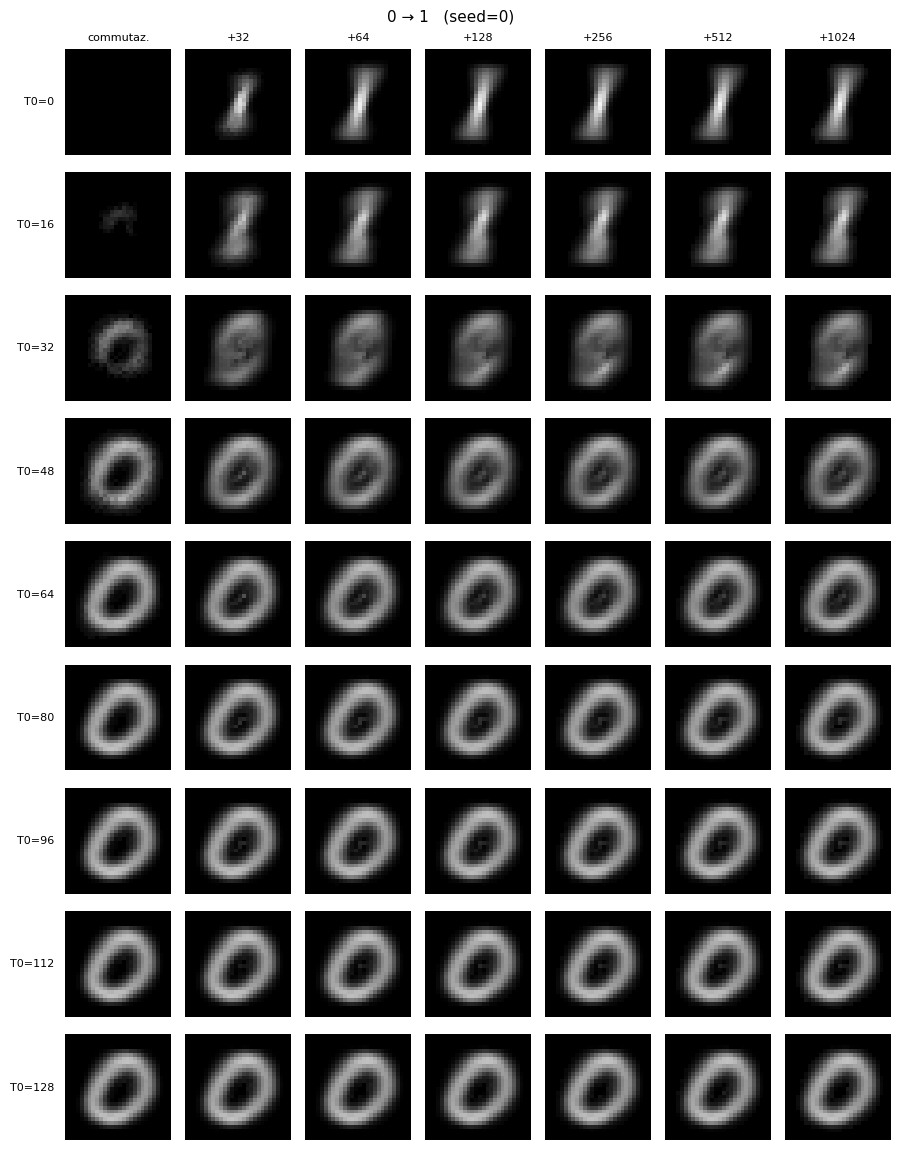

p_new_avg  p_new_sd  p_old_avg  p_old_sd  alive_avg  alive_sd  \
t0  t1                                                                    
0   32        0.690     0.067      0.003     0.001    179.375    10.980   
    64        0.967     0.006      0.000     0.000    234.500     2.878   
    128       0.971     0.005      0.000     0.000    230.500     4.781   
    256       0.970     0.005      0.000     0.000    226.875     3.357   
    512       0.970     0.005      0.000     0.000    222.750     4.621   
    1024      0.969     0.005      0.000     0.000    208.250     2.712   
16  32        0.332     0.098      0.007     0.002    271.625     4.470   
    64        0.855     0.054      0.002     0.001    285.125     4.190   
    128       0.881     0.042      0.001     0.000    280.500     3.854   
    256       0.880     0.041      0.001     0.000    274.500     3.625   
    512       0.875     0.045      0.001     0.000    264.125     3.796   
    1024      0.878     0.044      0.001     0.000    242.250     5.285   
32  32        0.010     0.002      0.292     0.162    358.125     5.915   
    64        0.013     0.003      0.209     0.123    357.875     7.680   
    128       0.014     0.003      0.195     0.105    352.125     4.051   
    256       0.014     0.004      0.202     0.103    345.000     3.381   
    512       0.014     0.003      0.207     0.104    335.875     5.436   
    1024      0.014     0.003      0.209     0.105    319.375     6.545   
48  32        0.000     0.000      0.993     0.002    414.500     5.682   
    64        0.000     0.000      0.988     0.003    412.625     5.553   
    128       0.000     0.000      0.985     0.005    408.625     4.502   
    256       0.000     0.000      0.985     0.005    403.250     5.285   
    512       0.000     0.000      0.985     0.005    395.000     6.141   
    1024      0.000     0.000      0.985     0.004    379.750     5.148   
64  32        0.000     0.000      0.999     0.000    438.000     2.268   
    64        0.000     0.000      0.999     0.000    436.500     1.927   
    128       0.000     0.000      0.999     0.000    433.750     1.832   
    256       0.000     0.000      0.998     0.000    429.875     2.949   
    512       0.000     0.000      0.999     0.000    422.250     4.432   
    1024      0.000     0.000      0.999     0.000    400.250     4.892   
80  32        0.000     0.000      0.999     0.000    438.875     2.100   
    64        0.000     0.000      0.999     0.000    437.000     1.773   
    128       0.000     0.000      0.999     0.000    435.625     2.387   
    256       0.000     0.000      0.999     0.000    432.125     3.357   
    512       0.000     0.000      0.999     0.000    425.500     3.928   
    1024      0.000     0.000      0.999     0.000    405.375     7.190   
96  32        0.000     0.000      1.000     0.000    438.125     1.885   
    64        0.000     0.000      0.999     0.000    436.875     2.416   
    128       0.000     0.000      0.999     0.000    435.375     2.200   
    256       0.000     0.000      0.999     0.000    432.750     3.327   
    512       0.000     0.000      0.999     0.000    425.500     4.000   
    1024      0.000     0.000      0.999     0.000    405.875     5.817   
112 32        0.000     0.000      1.000     0.000    437.625     2.200   
    64        0.000     0.000      0.999     0.000    436.875     2.416   
    128       0.000     0.000      0.999     0.000    435.000     2.449   
    256       0.000     0.000      0.999     0.000    432.375     2.973   
    512       0.000     0.000      0.999     0.000    424.875     3.907   
    1024      0.000     0.000      1.000     0.000    402.000     5.425   
128 32        0.000     0.000      1.000     0.000    436.625     2.066   
    64        0.000     0.000      1.000     0.000    435.500     2.204   
    128       0.000     0.000      1.000     0.000    434.125     2.031   
    256       0.000     0.000      

coppie di classi (T1=256):   0%|          | 0/90 [00:00<?, ?it/s]

T1=256  T0=32                       T0=64                       T0=96       \
misura  p_new         p_old         p_new         p_old         p_new        
stat      avg     sd    avg     sd    avg     sd    avg     sd    avg   sd   
coppia                                                                       
0→1     0.014  0.003  0.206  0.107  0.000  0.000  0.998  0.000  0.000  0.0   
0→2     0.635  0.117  0.158  0.089  0.001  0.000  0.998  0.000  0.000  0.0   
0→3     0.025  0.023  0.483  0.228  0.000  0.000  0.999  0.000  0.000  0.0   
0→4     0.041  0.014  0.028  0.038  0.000  0.000  0.997  0.001  0.000  0.0   
0→5     0.592  0.129  0.120  0.116  0.000  0.000  0.999  0.000  0.000  0.0   
...       ...    ...    ...    ...    ...    ...    ...    ...    ...  ...   
9→4     0.032  0.009  0.939  0.015  0.004  0.000  0.991  0.001  0.003  0.0   
9→5     0.276  0.095  0.665  0.085  0.000  0.000  0.990  0.001  0.000  0.0   
9→6     0.208  0.078  0.038  0.007  0.000  0.000  0.943  0.026  0.000  0.0   
9→7     0.757  0.143  0.208  0.135  0.008  0.001  0.982  0.002  0.004  0.0   
9→8     0.731  0.210  0.085  0.056  0.002  0.000  0.989  0.001  0.001  0.0   

T1=256               T0=128                     
misura  p_old         p_new       p_old         
stat      avg     sd    avg   sd    avg     sd  
coppia                                          
0→1     0.999  0.000  0.000  0.0  1.000  0.000  
0→2     0.999  0.000  0.000  0.0  1.000  0.000  
0→3     0.999  0.000  0.000  0.0  1.000  0.000  
0→4     0.999  0.000  0.000  0.0  0.999  0.000  
0→5     0.999  0.000  0.000  0.0  1.000  0.000  
...       ...    ...    ...  ...    ...    ...  
9→4     0.992  0.001  0.003  0.0  0.992  0.001  
9→5     0.992  0.001  0.000  0.0  0.992  0.001  
9→6     0.989  0.001  0.000  0.0  0.992  0.001  
9→7     0.990  0.001  0.004  0.0  0.991  0.001  
9→8     0.991  0.001  0.001  0.0  0.992  0.001  

[90 rows x 16 columns]

In [ ]:
# --- plasticita' complessiva------------------------------------------------------------

mat_pool_fix = plasticity_matrix(model_pool_fix, lenet, cfg, [32, 64, 96, 128],
                                 t1=256, seeds=range(8))
display(mat_pool_fix.round(3))

In [ ]:
# Ordinamento delle coppie per p_new crescente a T0=128 e T1=256 (Capitolo 6)
p_new_128_pool = mat_pool_fix[("T0=128", "p_new", "avg")]
p_new_128_pool_sd = mat_pool_fix[("T0=128", "p_new", "sd")]
sorted_pairs_pool = p_new_128_pool.sort_values(ascending=True)

print("Cap 6: Coppie in ordine di p_new crescente (T0=128, T1=256):")
display(sorted_pairs_pool.to_frame(name="p_new_avg"))

# Calcolo della SD aggregata (legge della varianza totale)
n, k = 8, len(p_new_128_pool)  # 8 seeds, 90 coppie
overall_mean_pool = p_new_128_pool.mean()
ss_within_pool = ((n - 1) * p_new_128_pool_sd**2).sum()
ss_between_pool = (n * (p_new_128_pool - overall_mean_pool)**2).sum()
overall_sd_pool = np.sqrt((ss_within_pool + ss_between_pool) / (n * k - 1))

print(f"Media di p_new a T0=128, T1=256: {overall_mean_pool:.4f} ± {overall_sd_pool:.4f}")


Cap 6: Coppie in ordine di p_new crescente (T0=128, T1=256):


,p_new_avg
coppia,
3→0,1.520747e-09
3→6,4.614941e-09
3→4,1.251488e-07
0→8,4.473343e-07
0→1,4.842806e-07
...,...
4→9,5.037811e-03
4→7,5.709265e-03
1→2,7.726930e-03


Media di p_new a T0=128, T1=256: 0.0010 ± 0.0029


## Cap 7: Sample pool + danno

Come il capitolo 6, ma durante il training gli stati con loss **migliore** ricevono un
danno circolare casuale prima del rollout. È l'unico dei tre training in cui la
rigenerazione è esplicitamente nell'obiettivo: negli altri, se compare, è un effetto collaterale.


### 7.1 - Addestramento

[ckpt] pesi caricati da /content/drive/MyDrive/ProgettoDLAI/c_nca_mnist_damage_fix.pth — training saltato


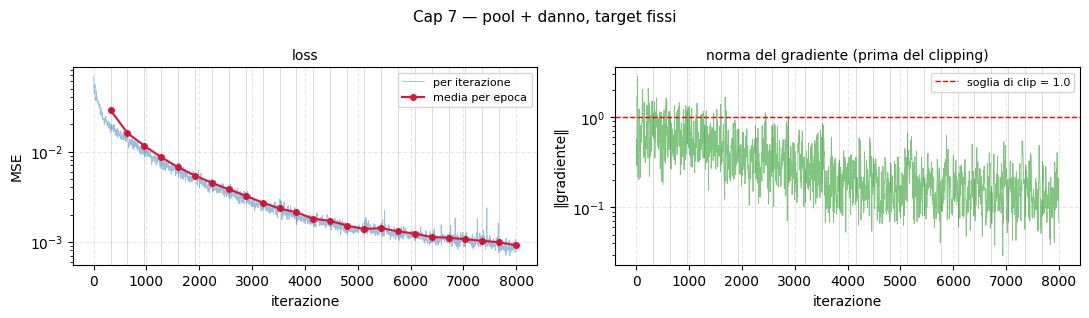

loss media per epoca: prima 0.02880 → ultima 0.00091 (25 epoche)


In [ ]:
model_damage_fix = ConditionalNCA(cfg).to(cfg.device)
model_damage_fix, hist_damage_fix, _ = load_or_train(
    model_damage_fix, "c_nca_mnist_damage_fix",
    lambda m: train_nca_fixed(m, TARGETS_FIX, cfg, mode="pool_damage",
                              monitor=LiveMonitor(cfg, plot_every=20,
                                                  preview_steps=2048, preview_every=256)),
    cfg)

plot_history(hist_damage_fix, cfg, "Cap 7 — pool + danno, target fissi")


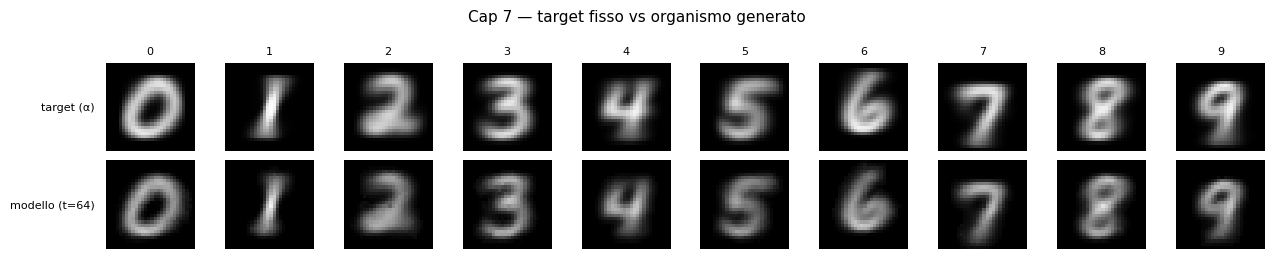

In [ ]:
out_dam, _ = grow(model_damage_fix, onehot(torch.arange(10, device=cfg.device), cfg),
                  cfg.n_steps, cfg)
plot_grid([[TARGETS_FIX[d, 3].cpu().numpy() for d in range(10)],
           [as_image(out_dam, d, cfg) for d in range(10)]],
          row_labels=["target (α)", f"modello (t={cfg.n_steps})"],
          col_labels=[str(d) for d in range(10)],
          title="Cap 7 — target fisso vs organismo generato")

### 7.2 - Test

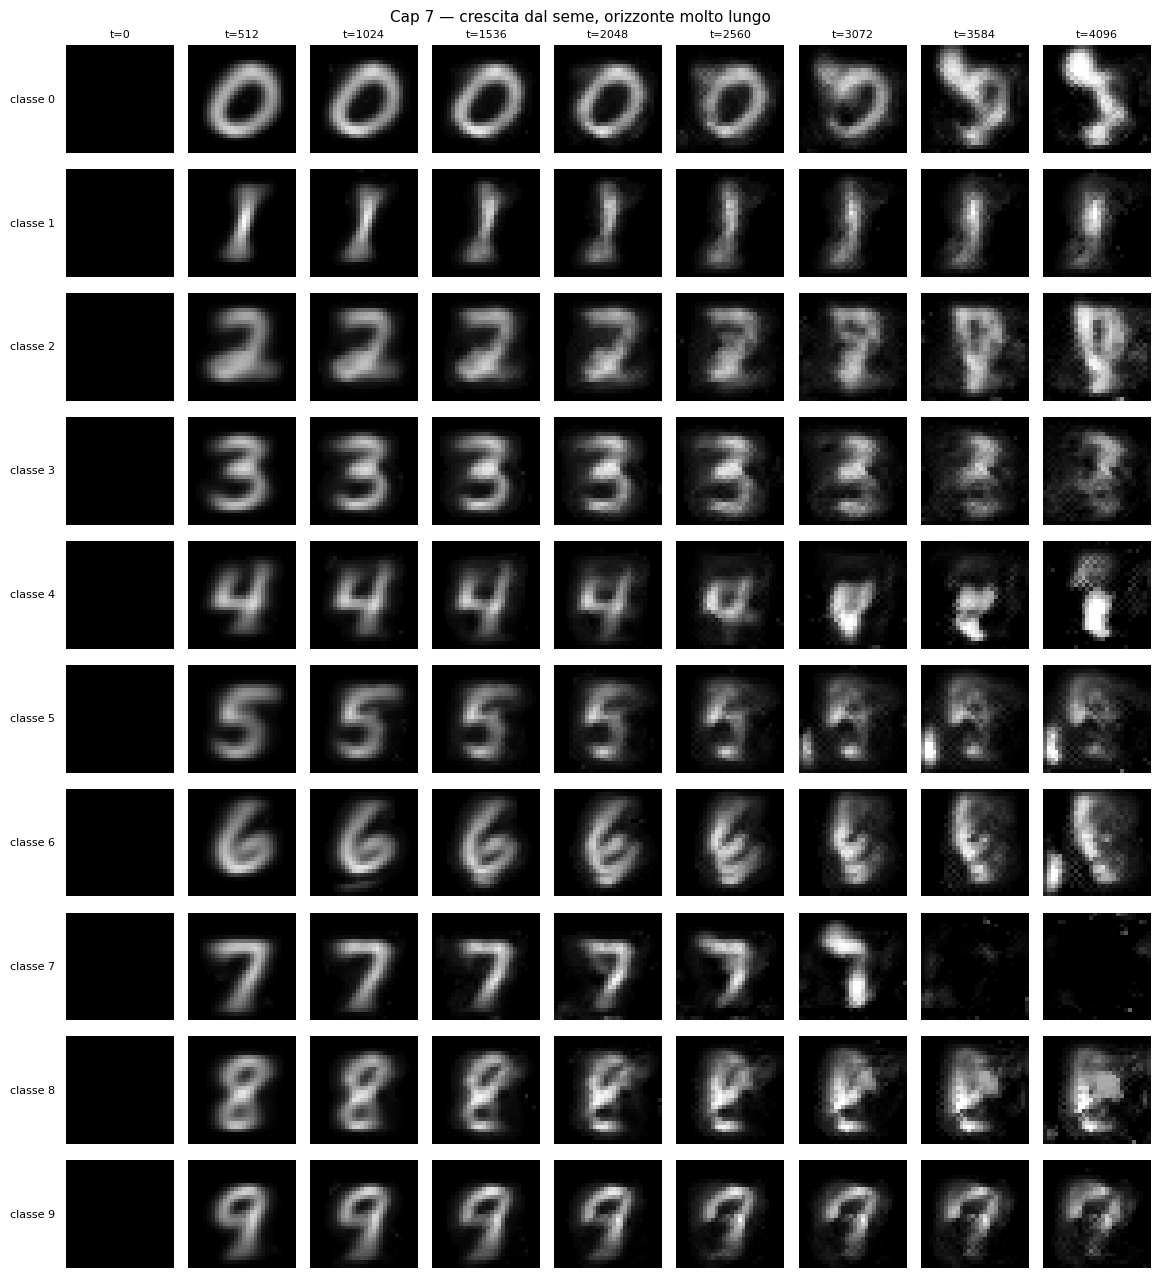

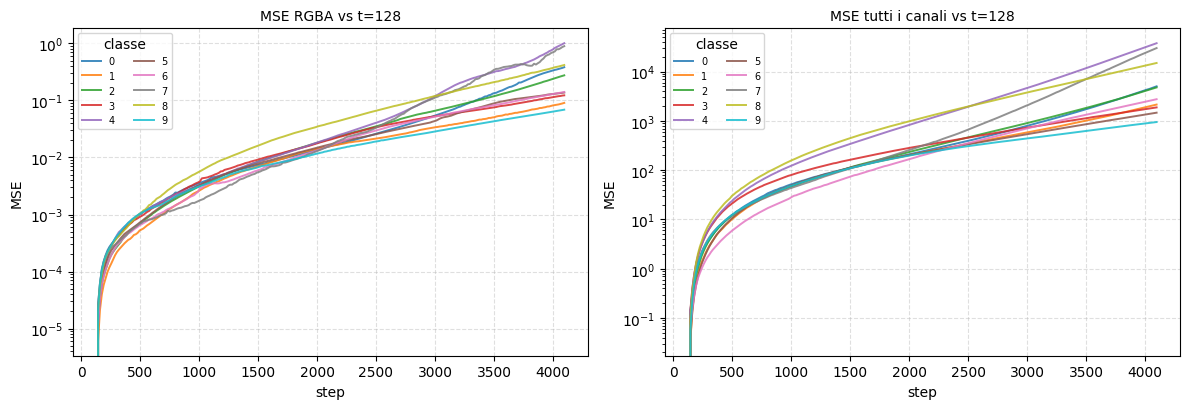

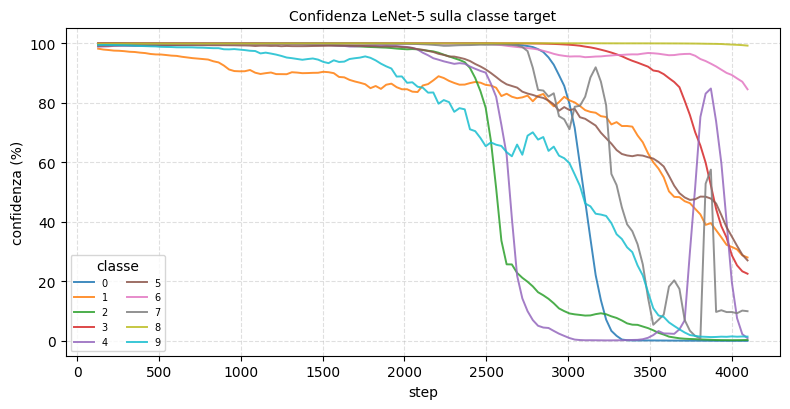

In [ ]:
# --- crescita e stabilita' nel tempo ----------------------------------------
show_growth(model_damage_fix, cfg, max_steps=4096, every=512,
            title="Cap 7 — crescita dal seme, orizzonte molto lungo")
df_home_dam_fix = homeostasis(model_damage_fix, cfg, max_steps=4096, ref_step=128,
                              every=16, seed=42)
df_lenet_dam_fix = lenet_confidence(model_damage_fix, lenet, cfg, max_steps=4096,
                                    ref_step=128, every=32, seed=42)

In [ ]:
final_step = df_home_dam_fix['step'].max()
mean_mse = df_home_dam_fix[df_home_dam_fix['step'] == final_step]['mse_rgba'].mean()
mean_conf = df_lenet_dam_fix[df_lenet_dam_fix['step'] == final_step]['confidence'].mean()
print(f"A t={final_step}: Loss media (MSE RGBA) = {mean_mse:.5f}, Confidenza LeNet media = {mean_conf:.2f}%")

A t=4096: Loss media (MSE RGBA) = 0.35431, Confidenza LeNet media = 27.39%


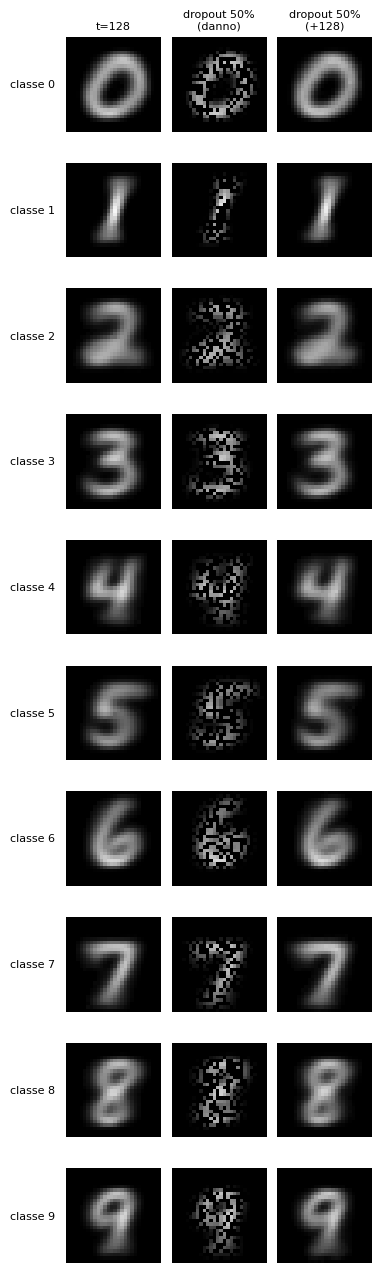

MSE RGBA dopo recupero,dropout 50%
digit,
0,0.0004
1,0.0004
2,0.0004
3,0.0003
4,0.0004
5,0.0004
6,0.0003
7,0.0003
8,0.0004


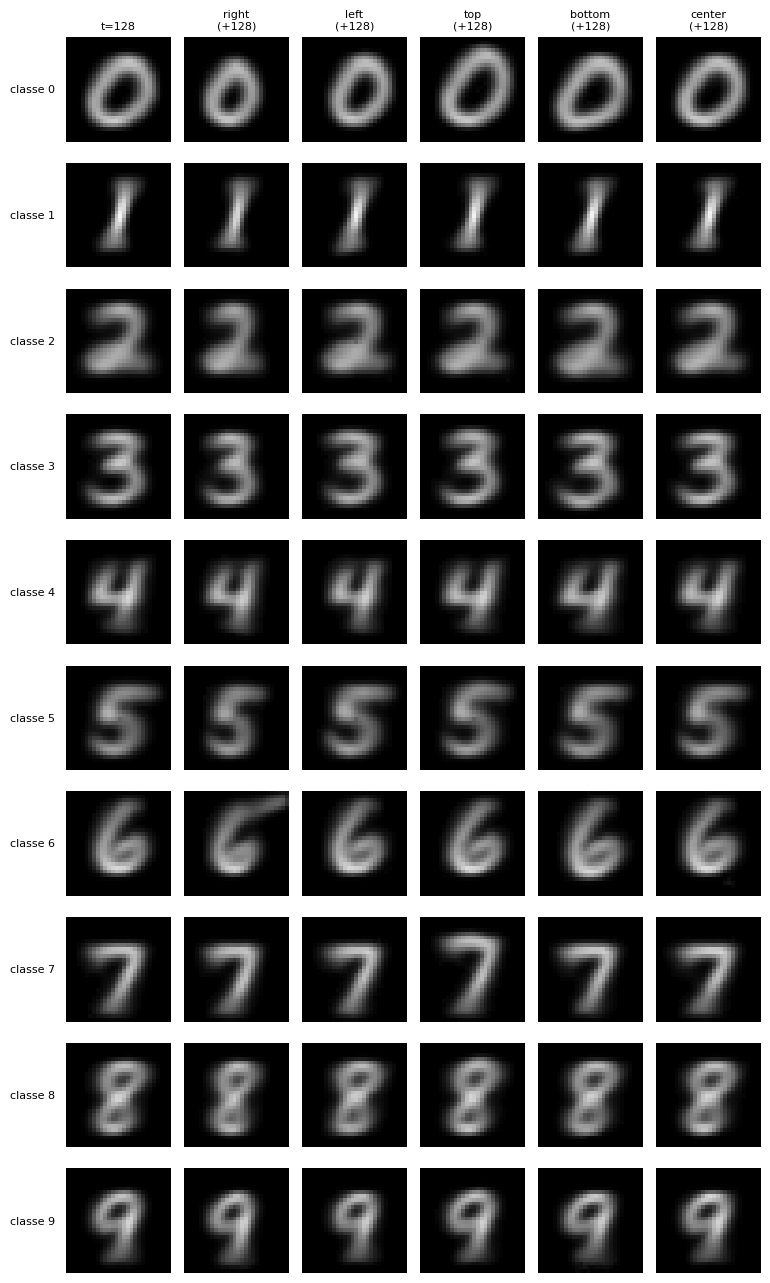

MSE RGBA dopo recupero,bottom,center,left,right,top
digit,,,,,
0,0.0035,0.0003,0.0109,0.0328,0.0104
1,0.0003,0.0003,0.0004,0.0021,0.0002
2,0.0012,0.0002,0.0007,0.0076,0.0003
3,0.0018,0.0003,0.0011,0.0067,0.0008
4,0.0006,0.0002,0.0018,0.0028,0.0002
5,0.0005,0.0002,0.0005,0.0039,0.0008
6,0.0035,0.0005,0.0002,0.0089,0.0006
7,0.0009,0.0003,0.0007,0.0015,0.0206
8,0.0003,0.0003,0.0007,0.0049,0.0010


GIF salvata: localized_damage_recovery.gif


In [ ]:
# --- resilienza ai danni (con la GIF del recupero) --------------------------
df_rnd_dam_fix = damage_experiment(model_damage_fix, cfg,
                                   {"dropout 50%": dropout_damage(0.5)},
                                   steps_grow=128, steps_recover=128, seed=42,
                                   show_damaged=True)
df_loc_dam_fix = damage_experiment(model_damage_fix, cfg, localized_damage_set(cfg),
                                   steps_grow=128, steps_recover=128, seed=42,
                                   gif_path="localized_damage_recovery.gif")

In [ ]:
mean_recovery_loss = df_loc_dam_fix['mse_rgba'].mean()
print(f"Media della loss (MSE RGBA) dopo recupero per danni localizzati: {mean_recovery_loss:.5f}")

Media della loss (MSE RGBA) dopo recupero per danni localizzati: 0.00292


In [ ]:
# --- interpolazione fra due classi ------------------------------------------
_ = interpolation_widget(model_damage_fix, cfg)

interactive(children=(IntSlider(value=0, description='classe A', max=9), IntSlider(value=1, description='class…

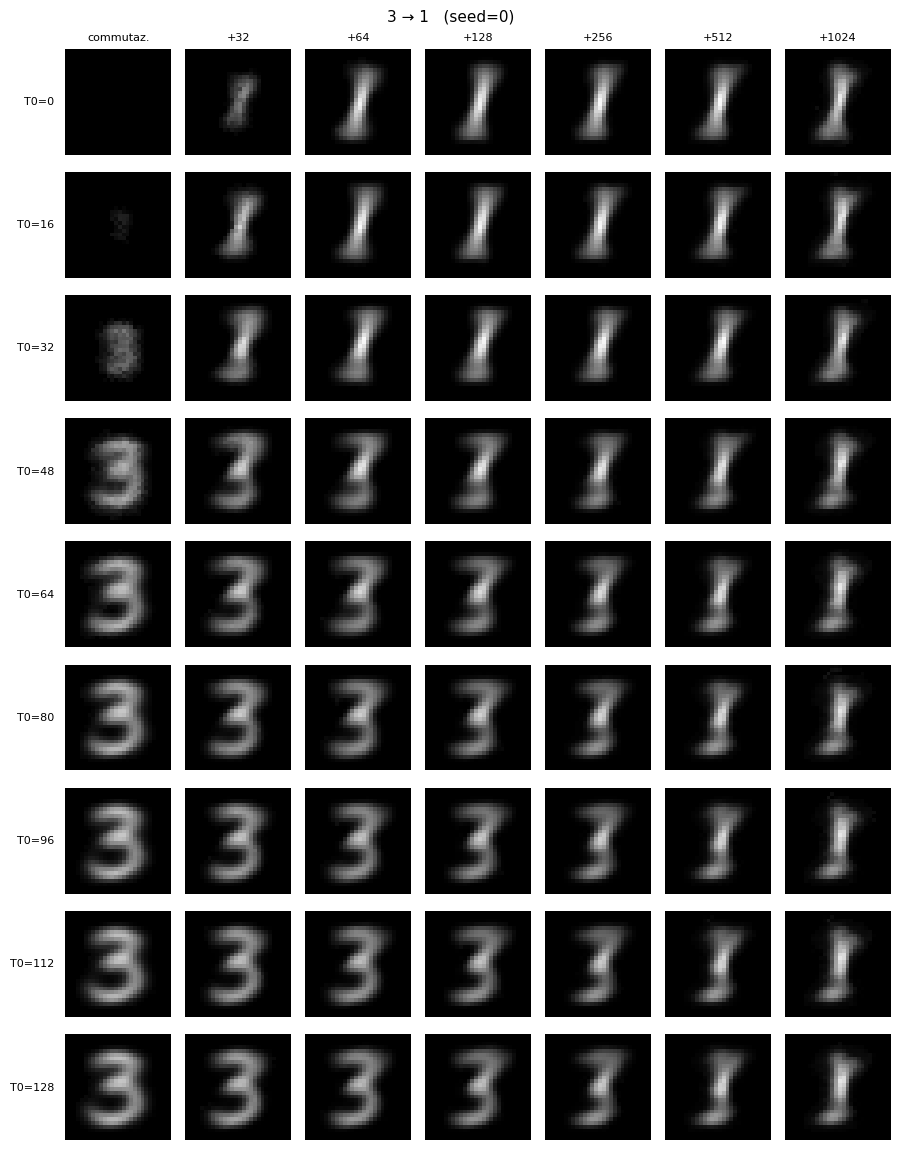

p_new_avg  p_new_sd  p_old_avg  p_old_sd  alive_avg  alive_sd  \
t0  t1                                                                    
0   32        0.130     0.043      0.088     0.048    140.250    12.303   
    64        0.963     0.007      0.000     0.000    245.500     7.309   
    128       0.984     0.003      0.000     0.000    241.625     7.009   
    256       0.979     0.006      0.000     0.000    258.000     5.477   
    512       0.967     0.013      0.000     0.000    273.750     7.344   
    1024      0.928     0.036      0.000     0.000    298.375     6.323   
16  32        0.777     0.116      0.001     0.002    220.625     5.528   
    64        0.987     0.004      0.000     0.000    244.625     2.875   
    128       0.987     0.003      0.000     0.000    241.750     3.105   
    256       0.978     0.005      0.000     0.000    258.750     4.027   
    512       0.964     0.013      0.000     0.000    272.125     7.240   
    1024      0.918     0.033      0.000     0.000    299.125     4.549   
32  32        0.862     0.063      0.031     0.025    275.250     6.065   
    64        0.979     0.005      0.000     0.000    268.250     4.921   
    128       0.984     0.003      0.000     0.000    259.500     5.425   
    256       0.985     0.004      0.000     0.000    263.250     7.265   
    512       0.981     0.006      0.000     0.000    283.625     8.088   
    1024      0.928     0.022      0.000     0.000    304.625     9.164   
48  32        0.001     0.000      0.995     0.002    339.625     7.050   
    64        0.051     0.093      0.860     0.117    322.875     5.194   
    128       0.487     0.179      0.238     0.116    303.125     5.987   
    256       0.918     0.027      0.006     0.004    296.500     4.175   
    512       0.962     0.008      0.000     0.000    300.500     4.811   
    1024      0.881     0.023      0.000     0.000    316.500     6.071   
64  32        0.000     0.000      0.999     0.000    369.500     4.375   
    64        0.001     0.000      0.994     0.001    352.250     6.923   
    128       0.007     0.002      0.948     0.011    333.000     3.625   
    256       0.269     0.072      0.465     0.086    317.875     4.941   
    512       0.876     0.038      0.005     0.003    309.750     5.497   
    1024      0.851     0.045      0.000     0.000    338.125    11.243   
80  32        0.000     0.000      1.000     0.000    378.500     3.928   
    64        0.000     0.000      0.999     0.000    366.875     4.970   
    128       0.002     0.001      0.987     0.004    346.000     5.264   
    256       0.064     0.016      0.781     0.036    323.500     5.264   
    512       0.797     0.051      0.019     0.009    319.375     9.680   
    1024      0.789     0.027      0.001     0.000    339.000     9.798   
96  32        0.000     0.000      1.000     0.000    381.375     4.438   
    64        0.000     0.000      0.999     0.000    369.250     5.175   
    128       0.001     0.000      0.995     0.001    348.000     4.209   
    256       0.026     0.006      0.886     0.021    329.125     1.885   
    512       0.773     0.039      0.030     0.011    323.750     5.651   
    1024      0.772     0.047      0.001     0.000    334.875     6.105   
112 32        0.000     0.000      1.000     0.000    386.000     2.138   
    64        0.000     0.000      1.000     0.000    373.125     2.997   
    128       0.000     0.000      0.997     0.000    351.625     2.925   
    256       0.014     0.004      0.933     0.017    339.375     5.344   
    512       0.761     0.034      0.042     0.020    326.500     4.536   
    1024      0.747     0.050      0.001     0.000    334.875     6.707   
128 32        0.000     0.000      1.000     0.000    388.625     1.768   
    64        0.000     0.000      1.000     0.000    377.625     4.241   
    128       0.000     0.000      0.998     0.001    358.500     4.175   
    256       0.013     0.004      

In [ ]:
# --- plasticita' singola coppia ------------------------------------------------------------
T0 = [0, 16, 32, 48, 64, 80, 96, 112, 128]
T1 = [32, 64, 128, 256, 512, 1024]
df_switch_dam_fix = switch_study(model_damage_fix, lenet, cfg, 3, 1, T0, T1, seeds=range(8))
display(df_switch_dam_fix.round(3))

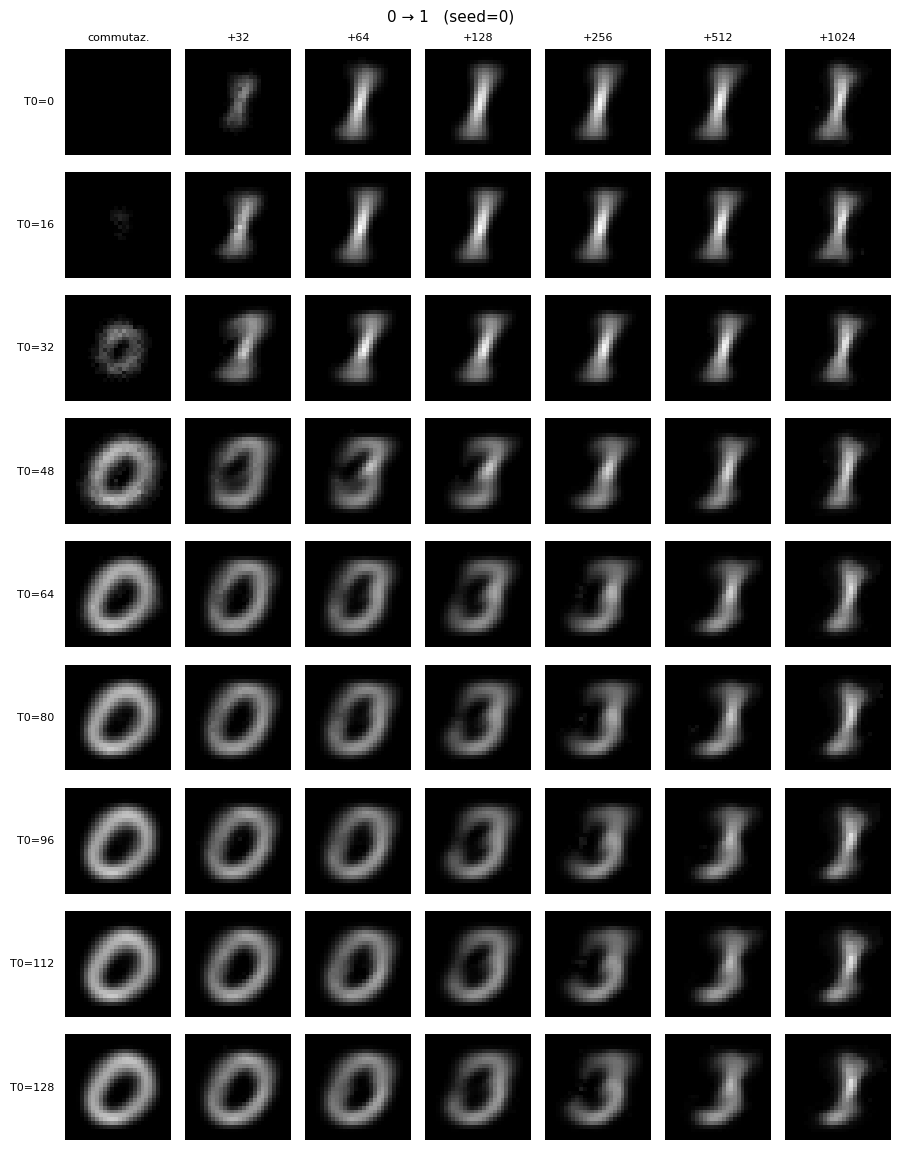

p_new_avg  p_new_sd  p_old_avg  p_old_sd  alive_avg  alive_sd  \
t0  t1                                                                    
0   32        0.130     0.043      0.031     0.009    140.250    12.303   
    64        0.963     0.007      0.000     0.000    245.500     7.309   
    128       0.984     0.003      0.000     0.000    241.625     7.009   
    256       0.979     0.006      0.000     0.000    258.000     5.477   
    512       0.967     0.013      0.000     0.000    273.750     7.344   
    1024      0.928     0.036      0.000     0.000    298.375     6.323   
16  32        0.742     0.101      0.001     0.001    218.375     5.655   
    64        0.988     0.004      0.000     0.000    243.250     2.493   
    128       0.990     0.003      0.000     0.000    241.750     4.833   
    256       0.985     0.004      0.000     0.000    254.250     2.915   
    512       0.970     0.007      0.000     0.000    271.500     5.099   
    1024      0.914     0.017      0.000     0.000    298.375     3.852   
32  32        0.668     0.153      0.002     0.002    277.125     6.749   
    64        0.973     0.018      0.000     0.000    260.875     4.518   
    128       0.983     0.014      0.000     0.000    256.000     3.338   
    256       0.991     0.004      0.000     0.000    256.625     5.181   
    512       0.991     0.003      0.000     0.000    262.625     8.501   
    1024      0.962     0.020      0.000     0.000    289.875    10.960   
48  32        0.018     0.003      0.287     0.087    385.750     6.018   
    64        0.005     0.002      0.001     0.000    368.125     6.578   
    128       0.051     0.018      0.001     0.000    325.625     6.653   
    256       0.785     0.065      0.002     0.001    296.875     2.748   
    512       0.967     0.009      0.000     0.000    288.000     4.036   
    1024      0.983     0.003      0.000     0.000    312.500     4.811   
64  32        0.001     0.001      0.939     0.028    432.250     4.234   
    64        0.012     0.004      0.455     0.178    420.625     2.722   
    128       0.016     0.006      0.005     0.009    381.500     7.838   
    256       0.159     0.040      0.001     0.001    341.125    12.159   
    512       0.775     0.141      0.005     0.003    311.250     9.765   
    1024      0.948     0.038      0.001     0.001    322.375     3.739   
80  32        0.000     0.000      0.984     0.005    444.625     3.815   
    64        0.002     0.001      0.883     0.055    438.875     4.086   
    128       0.023     0.009      0.071     0.075    407.500     7.426   
    256       0.088     0.033      0.001     0.001    361.500    11.439   
    512       0.613     0.183      0.008     0.004    329.750     5.946   
    1024      0.909     0.084      0.003     0.004    329.375     3.926   
96  32        0.000     0.000      0.991     0.002    448.000     6.459   
    64        0.001     0.000      0.963     0.008    444.375     3.962   
    128       0.018     0.003      0.279     0.063    422.250     4.027   
    256       0.053     0.014      0.001     0.000    379.375     7.110   
    512       0.416     0.122      0.007     0.001    340.625     9.070   
    1024      0.919     0.042      0.002     0.002    337.375     7.009   
112 32        0.000     0.000      0.994     0.001    450.000     4.243   
    64        0.000     0.000      0.978     0.005    445.125     5.055   
    128       0.012     0.002      0.458     0.080    429.500     5.581   
    256       0.045     0.019      0.002     0.001    389.000     5.451   
    512       0.289     0.072      0.005     0.001    346.625     7.249   
    1024      0.900     0.049      0.003     0.002    340.375     6.906   
128 32        0.000     0.000      0.995     0.001    450.750     5.064   
    64        0.000     0.000      0.984     0.004    448.250     5.312   
    128       0.009     0.001      0.588     0.070    435.250     6.756   
    256       0.035     0.013      

coppie di classi (T1=256):   0%|          | 0/90 [00:00<?, ?it/s]

T1=256  T0=32                       T0=64                       T0=96         \
misura  p_new         p_old         p_new         p_old         p_new          
stat      avg     sd    avg     sd    avg     sd    avg     sd    avg     sd   
coppia                                                                         
0→1     0.990  0.005  0.000  0.000  0.151  0.036  0.001  0.001  0.062  0.024   
0→2     0.991  0.001  0.003  0.000  0.978  0.005  0.016  0.003  0.924  0.012   
0→3     1.000  0.000  0.000  0.000  0.999  0.000  0.000  0.000  0.998  0.001   
0→4     0.988  0.001  0.000  0.000  0.922  0.020  0.001  0.000  0.758  0.065   
0→5     0.990  0.001  0.000  0.000  0.932  0.020  0.002  0.001  0.783  0.031   
...       ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
9→4     0.993  0.001  0.001  0.000  0.922  0.041  0.057  0.033  0.801  0.080   
9→5     0.982  0.003  0.015  0.002  0.944  0.008  0.051  0.008  0.901  0.007   
9→6     0.874  0.035  0.000  0.000  0.174  0.040  0.009  0.002  0.203  0.050   
9→7     0.998  0.000  0.000  0.000  0.997  0.000  0.001  0.000  0.996  0.001   
9→8     0.998  0.000  0.000  0.000  0.992  0.001  0.003  0.001  0.986  0.002   

T1=256               T0=128                       
misura  p_old         p_new         p_old         
stat      avg     sd    avg     sd    avg     sd  
coppia                                            
0→1     0.002  0.001  0.036  0.016  0.002  0.002  
0→2     0.065  0.011  0.833  0.022  0.150  0.022  
0→3     0.000  0.000  0.997  0.000  0.000  0.000  
0→4     0.003  0.001  0.575  0.024  0.007  0.001  
0→5     0.021  0.005  0.646  0.025  0.063  0.011  
...       ...    ...    ...    ...    ...    ...  
9→4     0.161  0.072  0.695  0.082  0.255  0.077  
9→5     0.094  0.007  0.870  0.007  0.124  0.006  
9→6     0.014  0.003  0.142  0.031  0.016  0.004  
9→7     0.002  0.000  0.996  0.001  0.002  0.000  
9→8     0.006  0.001  0.971  0.006  0.019  0.006  

[90 rows x 16 columns]

In [ ]:
# --- plasticita' complessiva ------------------------------------------------------------
mat_dam_fix = plasticity_matrix(model_damage_fix, lenet, cfg, [32, 64, 96, 128],
                                t1=256, seeds=range(8))
display(mat_dam_fix.round(3))

In [ ]:
# Ordinamento delle coppie per p_new crescente a T0=128 e T1=256 (Capitolo 7)
p_new_128_dam = mat_dam_fix[("T0=128", "p_new", "avg")]
p_new_128_dam_sd = mat_dam_fix[("T0=128", "p_new", "sd")]
sorted_pairs_dam = p_new_128_dam.sort_values(ascending=True)

print("Cap 7: Coppie in ordine di p_new crescente (T0=128, T1=256):")
display(sorted_pairs_dam.to_frame(name="p_new_avg"))

# Calcolo della SD aggregata (legge della varianza totale)
n, k = 8, len(p_new_128_dam)
overall_mean_dam = p_new_128_dam.mean()
ss_within_dam = ((n - 1) * p_new_128_dam_sd**2).sum()
ss_between_dam = (n * (p_new_128_dam - overall_mean_dam)**2).sum()
overall_sd_dam = np.sqrt((ss_within_dam + ss_between_dam) / (n * k - 1))

print(f"Media di p_new a T0=128, T1=256: {overall_mean_dam:.4f} ± {overall_sd_dam:.4f}")


Cap 7: Coppie in ordine di p_new crescente (T0=128, T1=256):


,p_new_avg
coppia,
3→8,0.010318
3→1,0.010750
7→1,0.031980
0→1,0.036071
7→6,0.063438
...,...
7→3,0.997999
5→3,0.999268
5→0,0.999420


Media di p_new a T0=128, T1=256: 0.7008 ± 0.3076


## Cap 8: c-NCA v2

Stesso training del capitolo 7 (pool + danno, target fissi), modello diverso: percezione
fissa, condizionamento **FiLM**, maschera di vitalità prima e dopo l'update. Tenendo
fisso tutto il resto, qualunque differenza nei test è attribuibile all'architettura.

Una nota per la lettura del pannello dei gradienti: con i filtri fissi `perceive` non riceve gradiente, quindi il numero di tensori addestrabili e la composizione della norma globale sono diversi da quelli della v1. Le due curve sono confrontabili solo qualitativamente.

### 8.1 - Addestramento

[ckpt] pesi caricati da /content/drive/MyDrive/ProgettoDLAI/c_nca_v2_fix.pth — training saltato


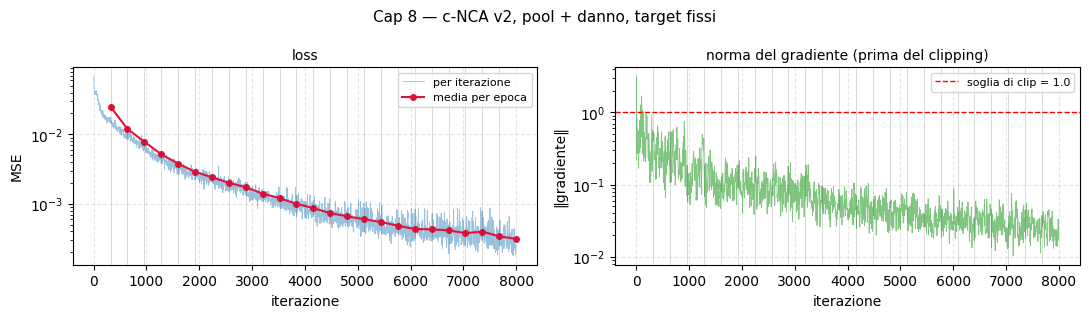

loss media per epoca: prima 0.02492 → ultima 0.00031 (25 epoche)


In [ ]:
model_v2_fix = ConditionalNCAv2(cfg).to(cfg.device)
model_v2_fix, hist_v2_fix, _ = load_or_train(
    model_v2_fix, "c_nca_v2_fix",
    lambda m: train_nca_fixed(m, TARGETS_FIX, cfg, mode="pool_damage",
                              monitor=LiveMonitor(cfg, plot_every=20,
                                                  preview_steps=2048, preview_every=256)),
    cfg)

plot_history(hist_v2_fix, cfg, "Cap 8 — c-NCA v2, pool + danno, target fissi")


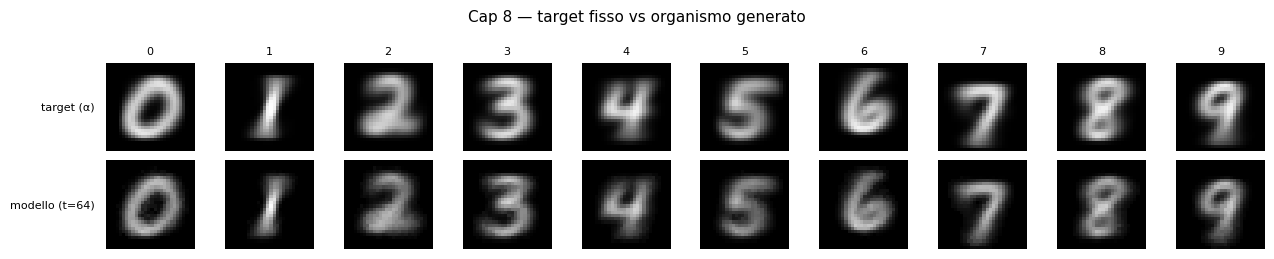

In [ ]:
out_v2, _ = grow(model_v2_fix, onehot(torch.arange(10, device=cfg.device), cfg),
                 cfg.n_steps, cfg)
plot_grid([[TARGETS_FIX[d, 3].cpu().numpy() for d in range(10)],
           [as_image(out_v2, d, cfg) for d in range(10)]],
          row_labels=["target (α)", f"modello (t={cfg.n_steps})"],
          col_labels=[str(d) for d in range(10)],
          title="Cap 8 — target fisso vs organismo generato")

### 8.2 - Test

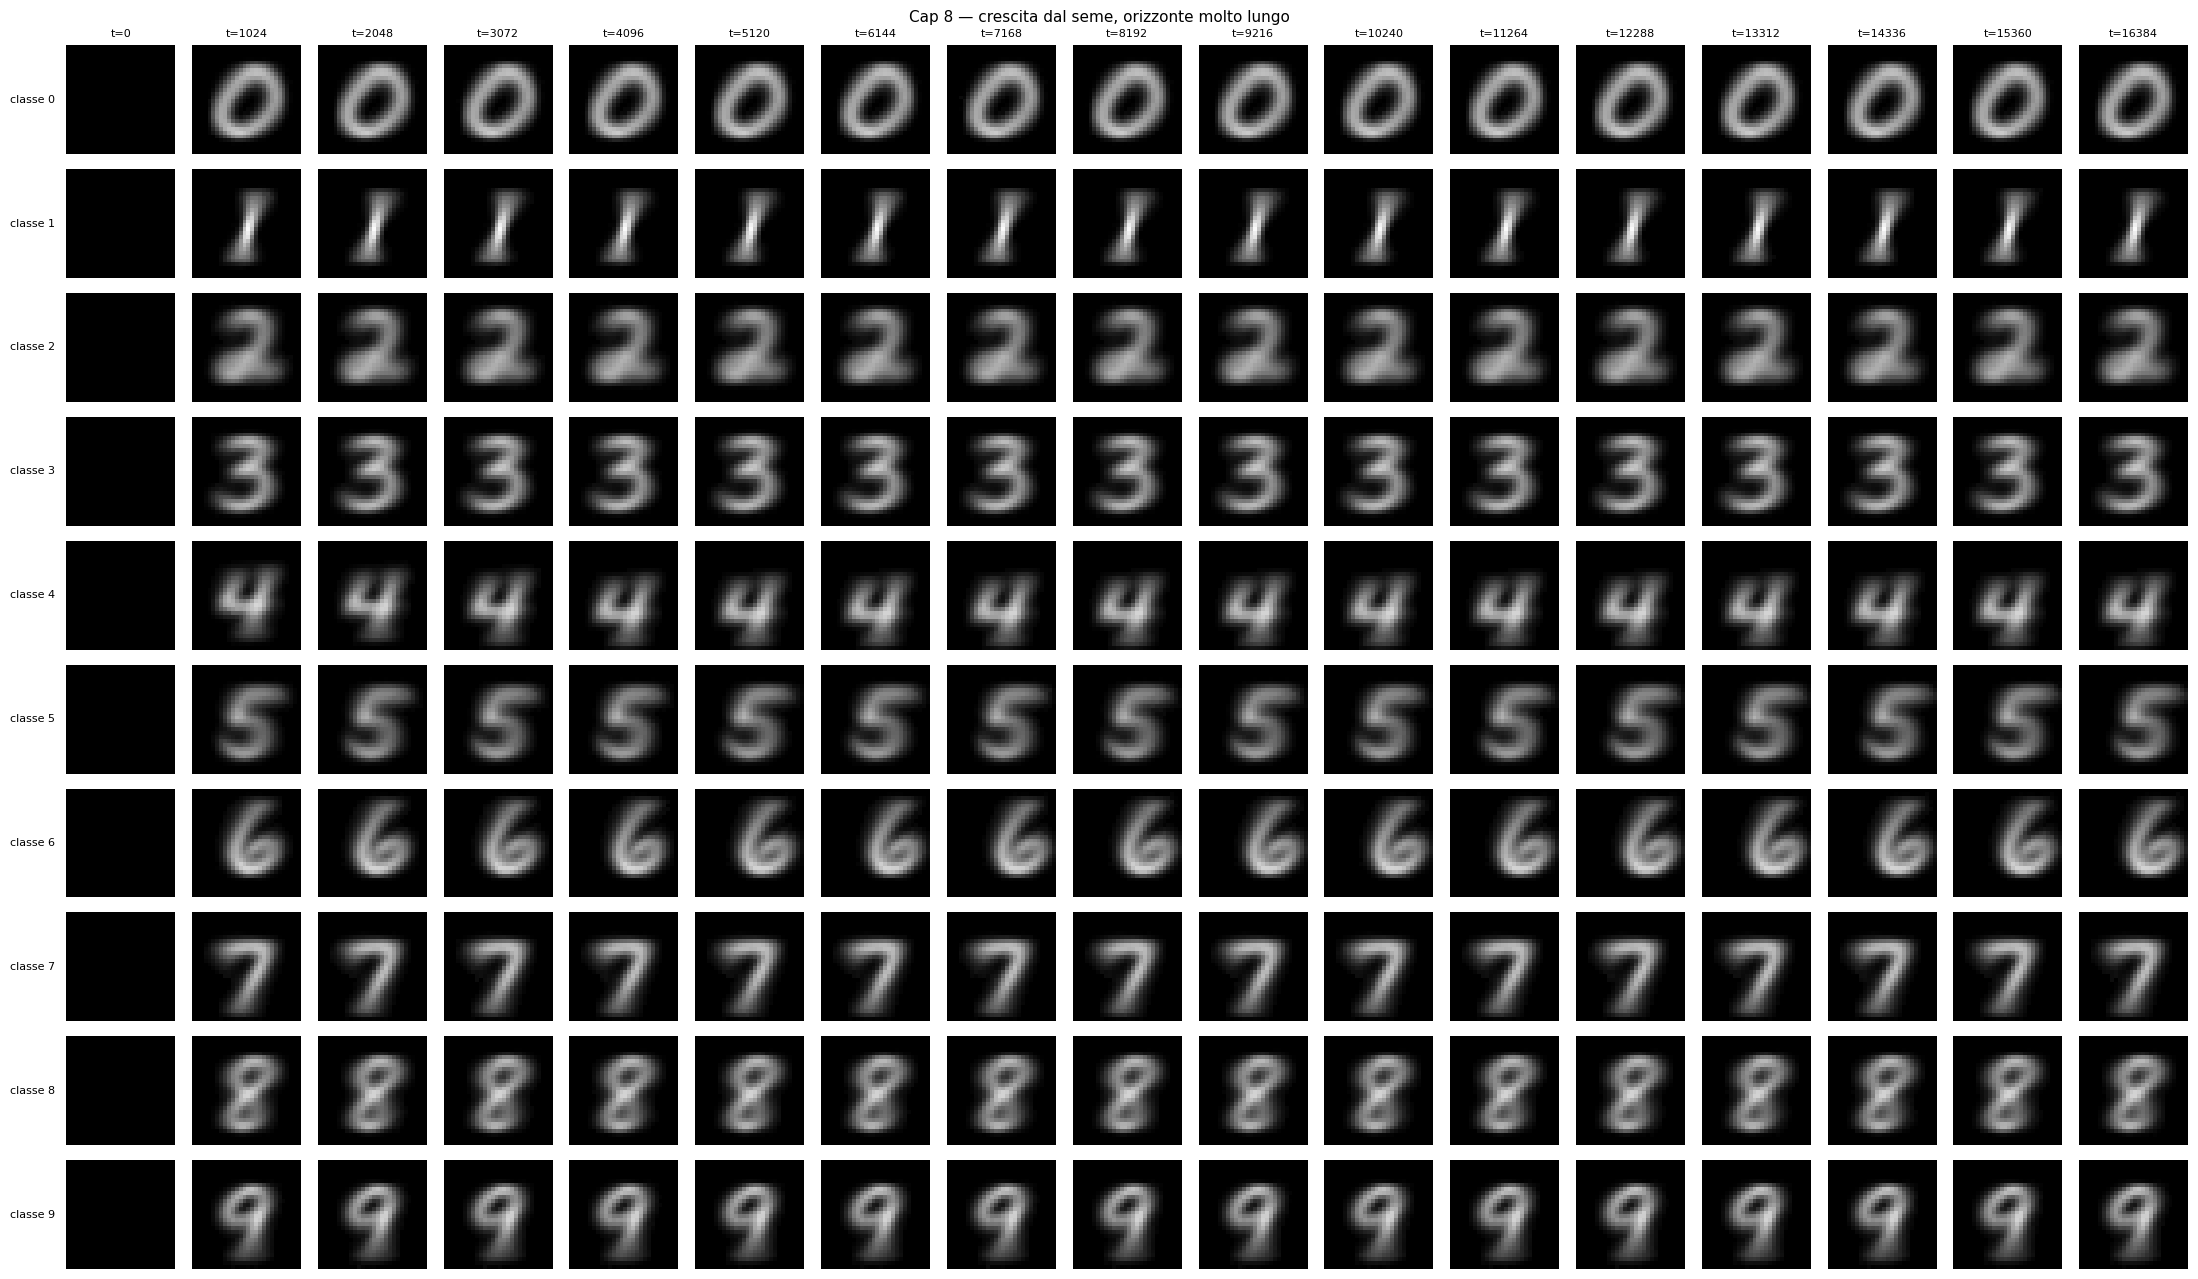

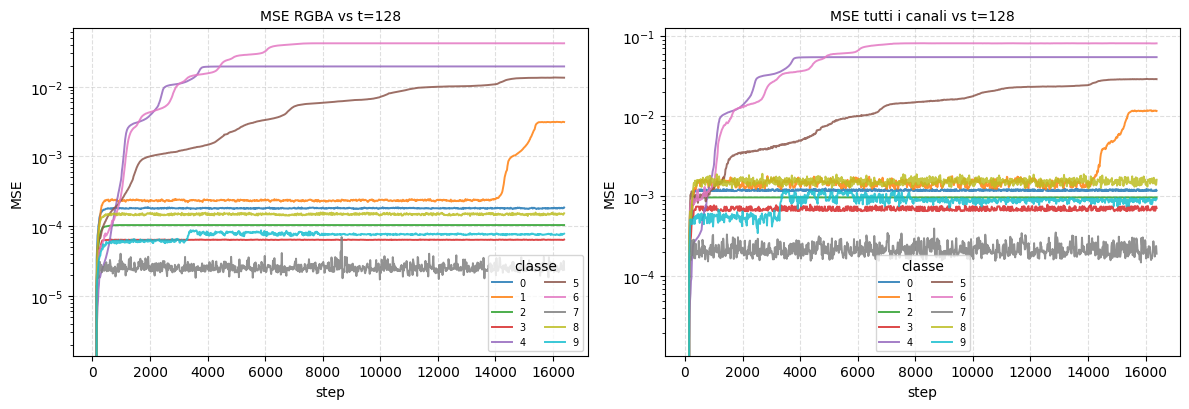

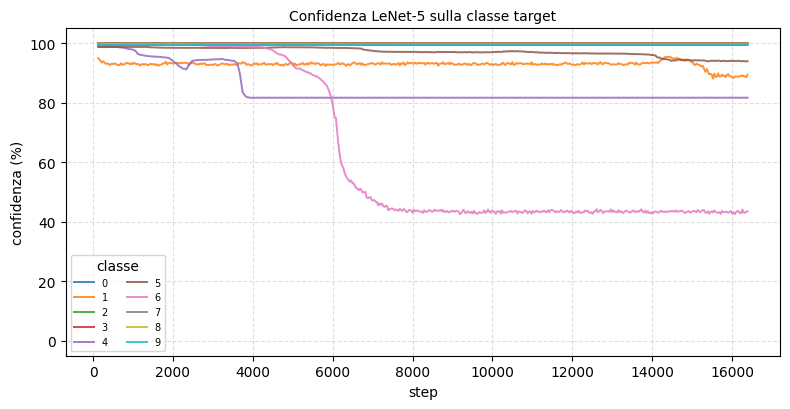

In [ ]:
# --- crescita e stabilita' nel tempo ----------------------------------------
show_growth(model_v2_fix, cfg, max_steps=4096
, every=1024,
            title="Cap 8 — crescita dal seme, orizzonte molto lungo")
df_home_v2_fix = homeostasis(model_v2_fix, cfg, max_steps=4096, ref_step=128,
                             every=16, seed=42)
df_lenet_v2_fix = lenet_confidence(model_v2_fix, lenet, cfg, max_steps=4096
,
                                   ref_step=128, every=32, seed=42)

In [ ]:
final_step = df_home_v2_fix['step'].max()
mean_mse = df_home_v2_fix[df_home_v2_fix['step'] == final_step]['mse_rgba'].mean()
mean_conf = df_lenet_v2_fix[df_lenet_v2_fix['step'] == final_step]['confidence'].mean()
print(f"A t={final_step}: Loss media (MSE RGBA) = {mean_mse:.5f}, Confidenza LeNet media = {mean_conf:.2f}%")

A t=4096: Loss media (MSE RGBA) = 0.00376, Confidenza LeNet media = 97.06%


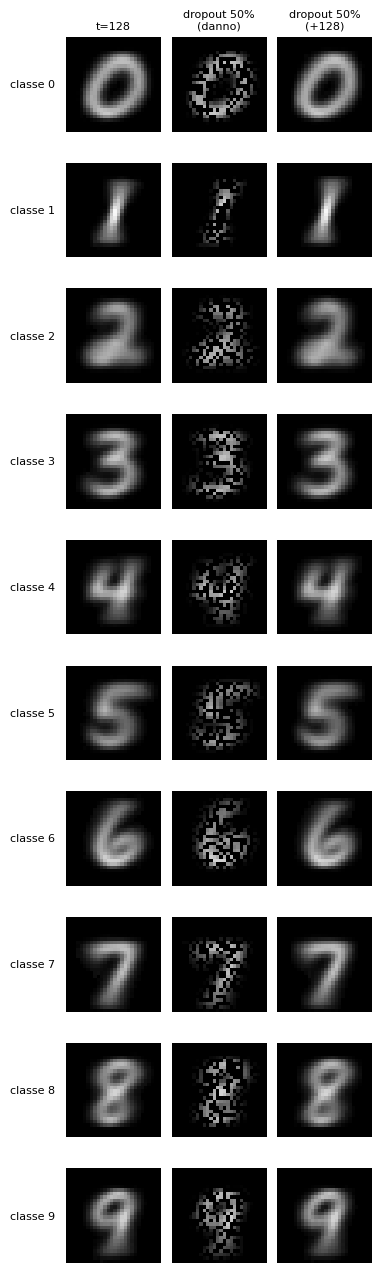

MSE RGBA dopo recupero,dropout 50%
digit,
0,0.0003
1,0.0003
2,0.0004
3,0.0001
4,0.0001
5,0.0001
6,0.0004
7,0.0001
8,0.0002


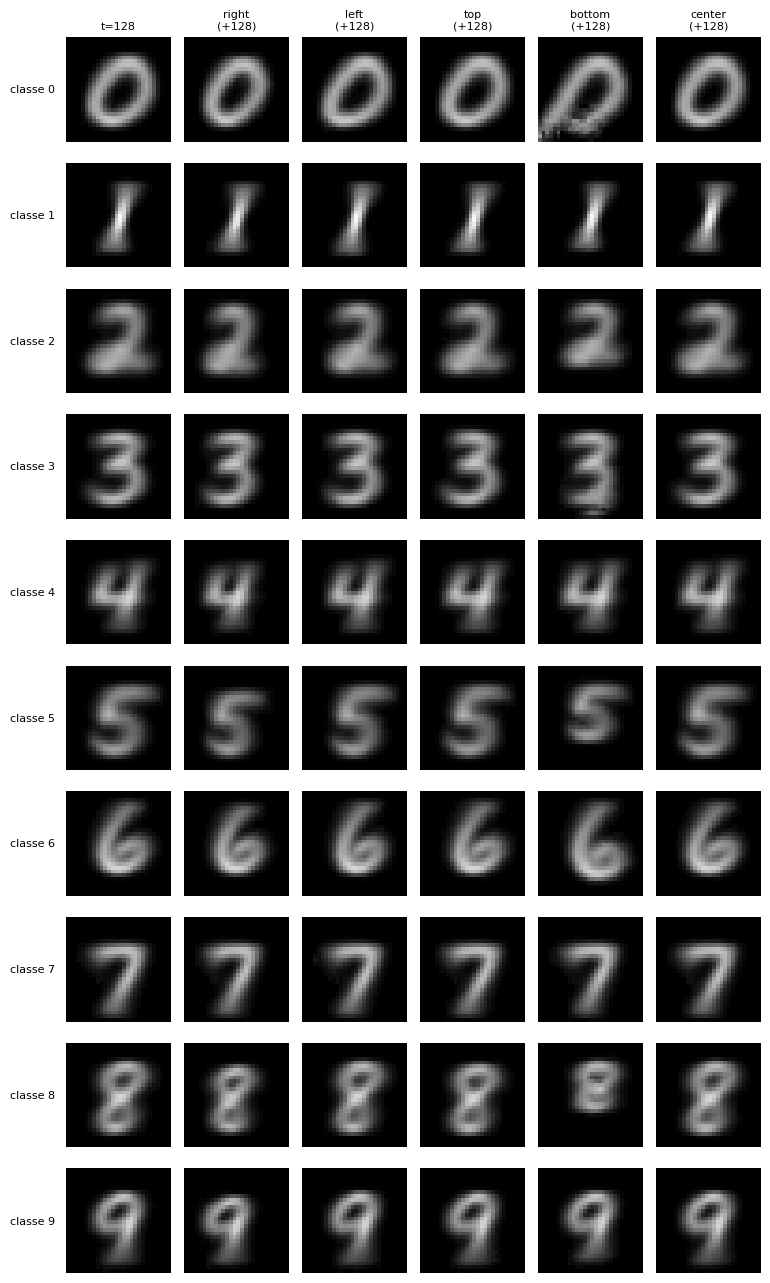

MSE RGBA dopo recupero,bottom,center,left,right,top
digit,,,,,
0,0.0190,0.0001,0.0009,0.0075,0.0001
1,0.0003,0.0002,0.0003,0.0009,0.0002
2,0.0082,0.0001,0.0008,0.0110,0.0015
3,0.0044,0.0001,0.0003,0.0081,0.0004
4,0.0001,0.0000,0.0003,0.0149,0.0000
5,0.0194,0.0001,0.0012,0.0086,0.0003
6,0.0112,0.0001,0.0009,0.0010,0.0005
7,0.0002,0.0000,0.0001,0.0048,0.0002
8,0.0226,0.0002,0.0007,0.0136,0.0020


In [ ]:
# --- resilienza ai danni ----------------------------------------------------
df_rnd_v2_fix = damage_experiment(model_v2_fix, cfg,
                                  {"dropout 50%": dropout_damage(0.5)},
                                  steps_grow=128, steps_recover=128, seed=42,
                                  show_damaged=True)
df_loc_v2_fix = damage_experiment(model_v2_fix, cfg, localized_damage_set(cfg),
                                  steps_grow=128, steps_recover=128, seed=42)

In [ ]:
mean_recovery_loss = df_loc_v2_fix['mse_rgba'].mean()
print(f"Media della loss (MSE RGBA) dopo recupero per danni localizzati: {mean_recovery_loss:.5f}")

Media della loss (MSE RGBA) dopo recupero per danni localizzati: 0.00386


In [ ]:
# --- interpolazione fra due classi ------------------------------------------
_ = interpolation_widget(model_v2_fix, cfg)

interactive(children=(IntSlider(value=0, description='classe A', max=9), IntSlider(value=1, description='class…

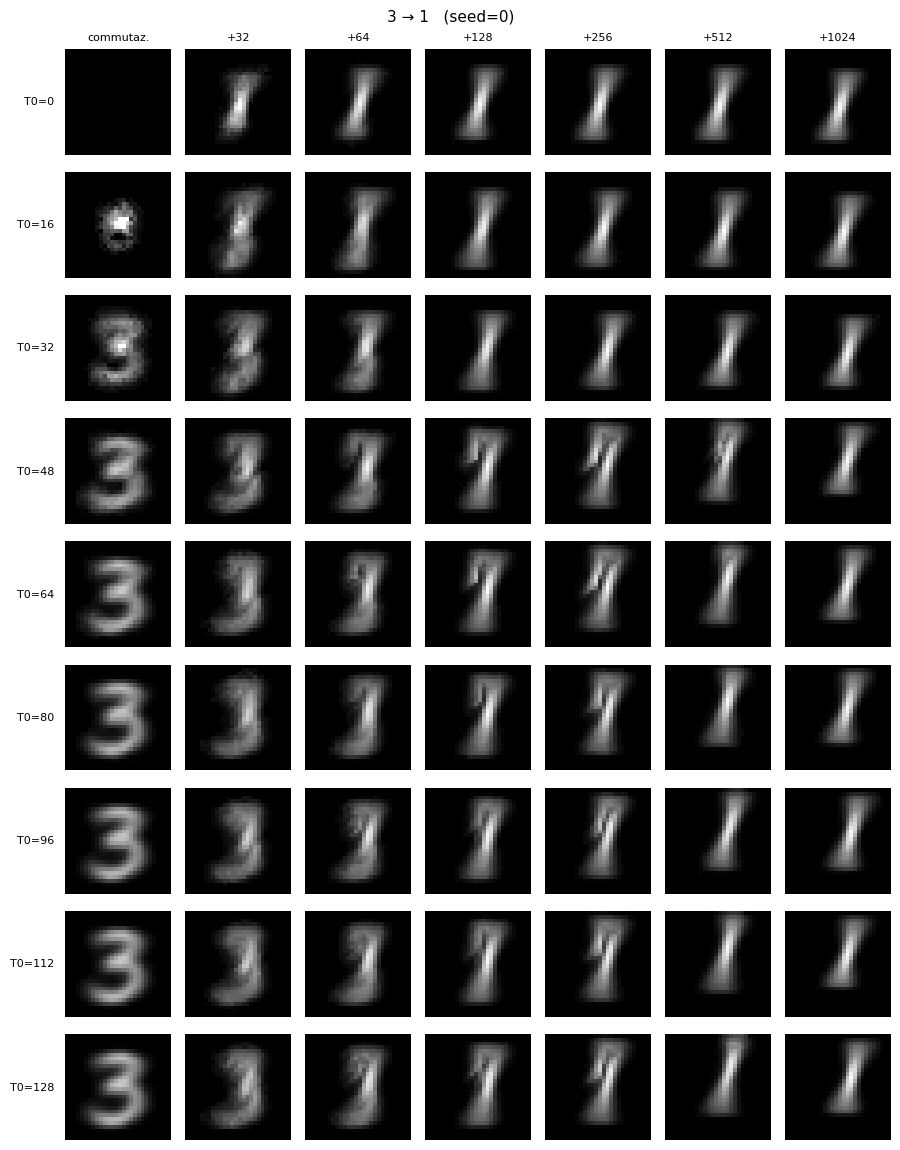

p_new_avg  p_new_sd  p_old_avg  p_old_sd  alive_avg  alive_sd  \
t0  t1                                                                    
0   32        0.474     0.096      0.001     0.000    238.875    11.630   
    64        0.959     0.009      0.000     0.000    243.000     6.633   
    128       0.965     0.005      0.000     0.000    239.125     4.998   
    256       0.966     0.003      0.000     0.000    239.750     1.909   
    512       0.961     0.006      0.000     0.000    237.375     4.241   
    1024      0.937     0.008      0.000     0.000    232.500     3.338   
16  32        0.526     0.180      0.021     0.031    324.375    10.649   
    64        0.974     0.009      0.000     0.000    293.875     8.741   
    128       0.985     0.005      0.000     0.000    261.375     3.662   
    256       0.979     0.010      0.000     0.000    252.250     3.412   
    512       0.957     0.023      0.000     0.000    244.125     3.643   
    1024      0.911     0.045      0.000     0.000    240.750     5.392   
32  32        0.040     0.031      0.791     0.103    348.375     8.331   
    64        0.785     0.164      0.072     0.088    307.000    10.623   
    128       0.984     0.010      0.000     0.000    264.875     6.621   
    256       0.975     0.005      0.000     0.000    250.375     3.623   
    512       0.967     0.011      0.000     0.000    246.750     4.400   
    1024      0.917     0.048      0.001     0.000    236.375     5.854   
48  32        0.021     0.015      0.867     0.076    346.875    10.999   
    64        0.654     0.150      0.079     0.056    319.000     9.381   
    128       0.909     0.056      0.001     0.001    302.125    11.532   
    256       0.922     0.055      0.000     0.000    312.500     9.103   
    512       0.974     0.017      0.000     0.000    268.250    12.068   
    1024      0.901     0.048      0.000     0.000    234.750     4.234   
64  32        0.029     0.014      0.842     0.068    357.250     9.270   
    64        0.581     0.126      0.092     0.064    325.500     8.089   
    128       0.909     0.050      0.001     0.001    314.000     9.055   
    256       0.930     0.032      0.000     0.000    314.125     4.794   
    512       0.977     0.013      0.000     0.000    252.125     9.819   
    1024      0.953     0.043      0.000     0.000    240.500     3.505   
80  32        0.023     0.013      0.876     0.051    361.000    10.392   
    64        0.502     0.130      0.130     0.064    325.250    10.714   
    128       0.935     0.038      0.001     0.001    306.250    14.350   
    256       0.951     0.028      0.000     0.000    303.625    21.941   
    512       0.982     0.014      0.000     0.000    251.125     8.271   
    1024      0.951     0.040      0.000     0.000    238.500     8.315   
96  32        0.018     0.005      0.880     0.029    359.375     7.909   
    64        0.391     0.083      0.155     0.055    326.750     9.223   
    128       0.928     0.092      0.001     0.001    304.750    16.577   
    256       0.930     0.092      0.000     0.000    304.250    26.321   
    512       0.981     0.012      0.000     0.000    260.125    16.181   
    1024      0.953     0.041      0.000     0.000    240.125     8.903   
112 32        0.017     0.004      0.882     0.030    354.375     5.854   
    64        0.425     0.067      0.137     0.034    327.000     6.279   
    128       0.958     0.017      0.001     0.000    303.750     7.630   
    256       0.960     0.037      0.000     0.000    303.375     8.450   
    512       0.964     0.025      0.000     0.000    258.250    12.926   
    1024      0.899     0.050      0.000     0.000    234.750     7.005   
128 32        0.016     0.005      0.890     0.029    356.750     5.726   
    64        0.514     0.092      0.118     0.051    328.875     5.842   
    128       0.963     0.016      0.000     0.000    305.125     6.289   
    256       0.959     0.031      

In [ ]:
# --- plasticita' complessiva------------------------------------------------------------
T0 = [0, 16, 32, 48, 64, 80, 96, 112, 128]
T1 = [32, 64, 128, 256, 512, 1024]
df_switch_v2_fix = switch_study(model_v2_fix, lenet, cfg, 3, 1, T0, T1, seeds=range(8))
display(df_switch_v2_fix.round(3))

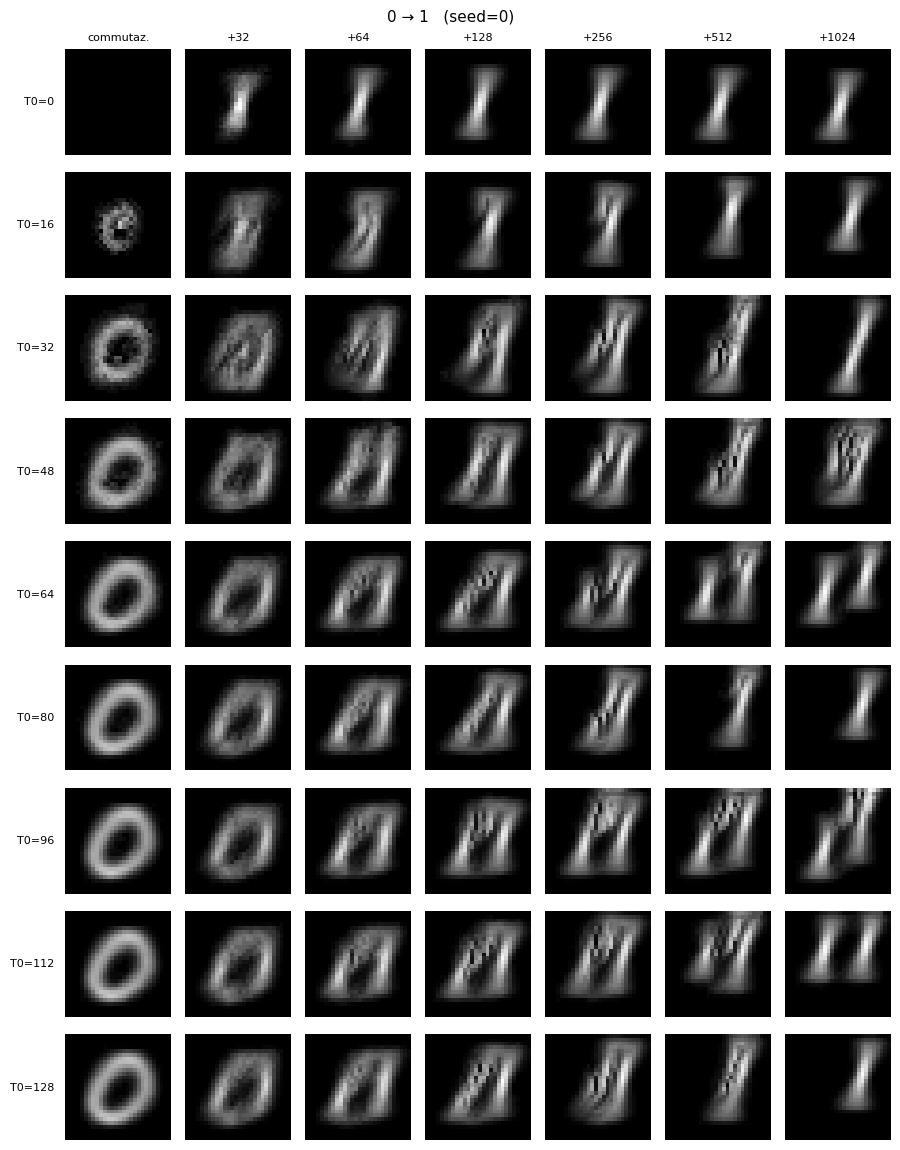

p_new_avg  p_new_sd  p_old_avg  p_old_sd  alive_avg  alive_sd  \
t0  t1                                                                    
0   32        0.474     0.096      0.002     0.000    238.875    11.630   
    64        0.959     0.009      0.000     0.000    243.000     6.633   
    128       0.965     0.005      0.000     0.000    239.125     4.998   
    256       0.966     0.003      0.000     0.000    239.750     1.909   
    512       0.961     0.006      0.000     0.000    237.375     4.241   
    1024      0.937     0.008      0.000     0.000    232.500     3.338   
16  32        0.164     0.077      0.011     0.006    364.000    18.639   
    64        0.350     0.193      0.021     0.012    334.500    16.009   
    128       0.654     0.247      0.005     0.003    300.500    18.150   
    256       0.836     0.173      0.002     0.001    279.500    21.448   
    512       0.972     0.017      0.000     0.000    250.375     6.435   
    1024      0.950     0.041      0.000     0.000    240.750     6.840   
32  32        0.023     0.011      0.338     0.205    447.000    10.474   
    64        0.285     0.212      0.062     0.059    429.000    15.166   
    128       0.912     0.102      0.004     0.006    415.625    17.896   
    256       0.931     0.062      0.003     0.003    396.250    11.107   
    512       0.878     0.073      0.001     0.001    347.625    29.923   
    1024      0.990     0.007      0.000     0.000    263.250    11.449   
48  32        0.002     0.001      0.966     0.005    448.375     5.423   
    64        0.109     0.046      0.848     0.063    445.500     8.602   
    128       0.903     0.077      0.055     0.064    425.250    11.081   
    256       0.863     0.063      0.055     0.078    396.000    17.550   
    512       0.791     0.191      0.056     0.082    348.250    39.881   
    1024      0.703     0.366      0.006     0.009    306.875    68.372   
64  32        0.000     0.000      0.996     0.001    443.875     3.796   
    64        0.009     0.010      0.986     0.012    439.375     4.868   
    128       0.225     0.260      0.730     0.291    437.000    15.062   
    256       0.353     0.198      0.461     0.304    429.000    28.163   
    512       0.489     0.318      0.084     0.139    389.125    48.292   
    1024      0.674     0.369      0.003     0.005    358.125    81.306   
80  32        0.000     0.000      0.997     0.000    443.375     4.565   
    64        0.003     0.001      0.994     0.002    441.500     5.707   
    128       0.094     0.185      0.879     0.224    448.875     5.617   
    256       0.210     0.174      0.625     0.341    447.250    37.270   
    512       0.417     0.396      0.257     0.431    406.375    74.793   
    1024      0.501     0.370      0.040     0.074    356.250   100.862   
96  32        0.000     0.000      0.998     0.001    440.500     3.505   
    64        0.004     0.002      0.993     0.003    436.875     4.549   
    128       0.065     0.056      0.911     0.076    449.250    10.846   
    256       0.330     0.157      0.438     0.314    438.000    27.370   
    512       0.325     0.317      0.244     0.309    422.000    39.345   
    1024      0.465     0.405      0.114     0.195    401.750    69.574   
112 32        0.000     0.000      0.998     0.000    439.375     2.326   
    64        0.003     0.001      0.993     0.002    435.500     4.036   
    128       0.188     0.184      0.757     0.225    444.375     9.650   
    256       0.277     0.151      0.468     0.286    450.750    37.190   
    512       0.564     0.352      0.081     0.127    417.500    57.151   
    1024      0.520     0.416      0.021     0.034    379.125    71.959   
128 32        0.000     0.000      0.998     0.000    437.250     1.165   
    64        0.005     0.002      0.992     0.002    433.125     5.463   
    128       0.180     0.109      0.773     0.131    439.875    11.482   
    256       0.475     0.172      

coppie di classi (T1=256):   0%|          | 0/90 [00:00<?, ?it/s]

T1=256  T0=32                       T0=64                       T0=96         \
misura  p_new         p_old         p_new         p_old         p_new          
stat      avg     sd    avg     sd    avg     sd    avg     sd    avg     sd   
coppia                                                                         
0→1     0.922  0.083  0.002  0.003  0.370  0.198  0.374  0.245  0.348  0.098   
0→2     0.957  0.011  0.025  0.005  0.993  0.002  0.005  0.001  0.994  0.001   
0→3     0.998  0.001  0.000  0.000  0.987  0.016  0.000  0.000  0.994  0.007   
0→4     0.969  0.013  0.002  0.002  0.993  0.001  0.000  0.000  0.994  0.001   
0→5     0.993  0.001  0.000  0.000  0.992  0.001  0.000  0.000  0.993  0.000   
...       ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
9→4     0.989  0.000  0.003  0.000  0.990  0.000  0.003  0.000  0.990  0.000   
9→5     0.985  0.003  0.013  0.002  0.981  0.001  0.015  0.001  0.982  0.001   
9→6     0.996  0.001  0.000  0.000  0.985  0.003  0.000  0.000  0.968  0.004   
9→7     0.993  0.001  0.003  0.000  0.994  0.001  0.003  0.000  0.994  0.001   
9→8     0.995  0.003  0.001  0.001  0.997  0.000  0.000  0.000  0.997  0.000   

T1=256               T0=128                       
misura  p_old         p_new         p_old         
stat      avg     sd    avg     sd    avg     sd  
coppia                                            
0→1     0.505  0.188  0.392  0.181  0.363  0.261  
0→2     0.004  0.001  0.995  0.000  0.003  0.000  
0→3     0.000  0.000  0.996  0.004  0.000  0.000  
0→4     0.000  0.000  0.994  0.001  0.000  0.000  
0→5     0.000  0.000  0.993  0.000  0.000  0.000  
...       ...    ...    ...    ...    ...    ...  
9→4     0.003  0.000  0.990  0.000  0.003  0.000  
9→5     0.015  0.001  0.983  0.000  0.014  0.000  
9→6     0.000  0.000  0.965  0.005  0.000  0.000  
9→7     0.003  0.000  0.994  0.001  0.003  0.000  
9→8     0.000  0.000  0.997  0.000  0.000  0.000  

[90 rows x 16 columns]

In [ ]:
# --- plasticita' complessiva------------------------------------------------------------
mat_v2_fix = plasticity_matrix(model_v2_fix, lenet, cfg, [32, 64, 96, 128],
                               t1=256, seeds=range(8))
display(mat_v2_fix.round(3))

In [ ]:
# Ordinamento delle coppie per p_new crescente a T0=128 e T1=256 (Capitolo 8)
p_new_128_v2 = mat_v2_fix[("T0=128", "p_new", "avg")]
p_new_128_v2_sd = mat_v2_fix[("T0=128", "p_new", "sd")]
sorted_pairs_v2 = p_new_128_v2.sort_values(ascending=True)

print("Cap 8: Coppie in ordine di p_new crescente (T0=128, T1=256):")
display(sorted_pairs_v2.to_frame(name="p_new_avg"))

# Calcolo della SD aggregata (legge della varianza totale)
n, k = 8, len(p_new_128_v2)
overall_mean_v2 = p_new_128_v2.mean()
ss_within_v2 = ((n - 1) * p_new_128_v2_sd**2).sum()
ss_between_v2 = (n * (p_new_128_v2 - overall_mean_v2)**2).sum()
overall_sd_v2 = np.sqrt((ss_within_v2 + ss_between_v2) / (n * k - 1))

print(f"Media di p_new a T0=128, T1=256: {overall_mean_v2:.4f} ± {overall_sd_v2:.4f}")


Cap 8: Coppie in ordine di p_new crescente (T0=128, T1=256):


,p_new_avg
coppia,
1→0,0.019147
7→0,0.076968
0→1,0.392327
6→1,0.417372
2→0,0.551164
...,...
7→3,0.999607
5→0,0.999714
4→3,0.999847


Media di p_new a T0=128, T1=256: 0.9238 ± 0.1802


## Cap 9: Analisi trasversali

Tre domande che non riguardano un modello in particolare ma la regola in sé.

1. **I kernel appresi.** Nella v1 la percezione è una depthwise conv appresa, a differenza di Growing NCA in cui vengno utilizzati identità e filtri di Sobel per stimare il gradiente come prior biologico. Il modello riscopre spontaneamente qualcosa di
   equivalente a `Span{I, Sobel_x, Sobel_y}`? Il confronto è stato effettuato con gli angoli principali fra sottospazi, e la significatività contro una distribuzione nulla di
   sottospazi 3-dimensionali casuali in $\mathbb R^9$.
2. **La regolarità del condizionamento.** Muovendosi lungo il segmento fra due vettori
   di classe, a tempo fissato, l'immagine generata cambia in modo graduale o a scatti? Proviamo a quantificare quanto visot con l'interpolation widget stimando le derivate direzionali lungo i segmenti che congiungono i vettori one-hot.

La variabile `target_model` sceglie il modello analizzato: cambiala per rifare le analisi su un altro dei modelli addestrati sopra.

In [ ]:
# modelli disponibili: model_base, model_base_fix, model_pool_fix,
#                      model_damage_fix, model_v2_fix
target_model = model_base

### 9.1 - I kernel di percezione

Vale **solo per la v1**: nella v2 `perceive` è un buffer con i Sobel dentro, quindi non
c'è niente da scoprire.

Abbiamo calcolato due tabelle. La prima misura il **rango** dei tre filtri di ogni canale (se collassano
su meno di 3 direzioni indipendenti, la percezione di quel canale è degenere) e quello
della mappa effettiva verso il layer nascosto. La seconda misura **quanto lo spazio
generato dai tre filtri si sovrappone** a `Span{I, Sobel_x, Sobel_y}`, con il p-value
calcolato contro sottospazi casuali.

In [ ]:
SOBEL_X = np.array([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]])
REF_KERNELS = {"I": np.array([[0., 0., 0.], [0., 1., 0.], [0., 0., 0.]]),
               "sobel_x": SOBEL_X, "sobel_y": SOBEL_X.T.copy()}


def _base(M):
    """
    Base ortonormale del sottospazio generato dalle RIGHE di M.
    swapaxes(-1,-2) traspone solo le ultime due dimensioni, quindi la funzione accetta
    anche un batch di matrici (np.linalg.qr lavora sull'ultimo blocco 2D).
    E' una base valida solo se M ha rango pieno: un altro motivo per cui il test sul
    rango deve venire prima.
    """
    return np.linalg.qr(np.swapaxes(M, -1, -2))[0]


def _cond3(M):
    """
    sigma_1 / sigma_3. Per K (3x9) e V (Hx3) e' il numero di condizionamento usuale;
    per A (Hx9), che ha rango strutturalmente <= 3, e' il condizionamento sul
    sottospazio che conta -- sigma_1/sigma_min darebbe infinito sempre, senza dire nulla.
    """
    s = np.linalg.svd(M, compute_uv=False)
    return s[0] / s[2] if s[2] > 0 else np.inf


@torch.no_grad()
def channel_activity(model, cfg: Config, steps=None):
    """Deviazione standard spaziale media per canale su un rollout: trova i canali morti."""
    steps = steps or cfg.n_steps
    labels = torch.arange(cfg.num_classes, device=cfg.device)
    out, _ = grow(model, onehot(labels, cfg), steps, cfg)
    return out.std(dim=(2, 3)).mean(dim=0).cpu().numpy()


def kernel_subspace_report(model, cfg: Config, n_null=20000, seed=0, alpha=0.05):
    """
    Confronta, canale per canale, il sottospazio generato dai tre filtri appresi con
    Span{I, sobel_x, sobel_y}. Solo modelli v1: la v2 ha i filtri fissi.

    Per il canale c:
      K   [3,9]  i tre filtri appiattiti, uno per riga
      V   [H,3]  le tre colonne del primo layer che leggono la percezione di c
      A = V @ K  la mappa effettiva "intorno 3x3 di c -> layer nascosto"

    Colonne:
      cond_K, cond_V, cond_A   sigma_1/sigma_3: il test di rango, in forma numerica
      ang_min, ang_max         angoli principali estremi, in gradi
      shared                   somma dei cos^2 degli angoli, in [0,3]: 3 = stesso
                               sottospazio, 1 = quanto ci si aspetta a caso
      p                        p-value a una coda contro sottospazi 3-dim uniformi
      res_*                    residuo relativo di ciascun kernel di riferimento
                               proiettato sullo spazio appreso (0 = contenuto, 1 = ortogonale)
      act                      attivita' del canale: se e' ~0 i filtri non sono addestrati
    """
    assert hasattr(model, "update_net"), \
        "questa analisi vale solo per ConditionalNCA (v1): la v2 ha i filtri fissi"
    model.eval()
    C = model.channel_n
    K_all = model.perceive.weight.detach().cpu().numpy().reshape(C, 3, 9)
    # update_net[0].weight e' [hidden, 3C+num_classes, 1, 1]: teniamo le prime 3C
    # colonne, quelle che leggono la percezione e non il condizionamento.
    Wp  = model.update_net[0].weight.detach().cpu().numpy()[:, :3 * C, 0, 0]
    act = channel_activity(model, cfg)

    Q_ref = _base(np.stack([v.ravel() for v in REF_KERNELS.values()]))       # [9,3]
    # Distribuzione nulla: tre righe gaussiane indipendenti in R^9 generano un
    # sottospazio 3-dimensionale uniforme sulla Grassmanniana Gr(3,9).
    rng  = np.random.default_rng(seed)
    null = ((Q_ref.T @ _base(rng.standard_normal((n_null, 3, 9)))) ** 2).sum(axis=(1, 2))

    recs = []
    for c in range(C):
        K, V = K_all[c], Wp[:, 3 * c:3 * c + 3]
        Q_c  = _base(K)
        # i valori singolari di Q_ref^T Q_c SONO i coseni degli angoli principali
        cos = np.linalg.svd(Q_ref.T @ Q_c, compute_uv=False)
        ang = np.degrees(np.arccos(np.clip(cos, -1, 1)))    # clip: difende dall'arrotondamento
        sh  = float((cos ** 2).sum())
        res = {f"res_{n}": float(np.linalg.norm(v.ravel() - Q_c @ (Q_c.T @ v.ravel()))
                                 / np.linalg.norm(v)) for n, v in REF_KERNELS.items()}
        recs.append(dict(ch=c, cond_K=_cond3(K), cond_V=_cond3(V), cond_A=_cond3(V @ K),
                         ang_min=ang.min(), ang_max=ang.max(), shared=sh,
                         # (1+k)/(1+n): stimatore standard, non restituisce mai 0
                         p=(1 + int((null >= sh).sum())) / (1 + n_null),
                         act=act[c], **res))
    df = pd.DataFrame(recs).set_index("ch")

    vivi = df.act > 1e-3
    print(f"nulla: media {null.mean():.4f} (valore esatto pq/n = 1.0000), sd {null.std():.4f}")
    print(f"rango pieno (cond_A < 1e6):  {(df.cond_A < 1e6).sum()}/{C}")
    print(f"canali vivi (act > 1e-3):    {int(vivi.sum())}/{C}")
    print(f"p < {alpha}:                    {(df.p < alpha).sum()}/{C} ")
    print(f"vivi E significativi:        {int((vivi & (df.p < alpha)).sum())}/{C}")
    print(f"dimensioni condivise: media {df.shared.mean():.3f} vs 1.000 attesa a caso")
    return df


df_kernels = kernel_subspace_report(target_model, cfg, n_null=20000, seed=0)
display(df_kernels.round(3))

nulla: media 0.9975 (valore esatto pq/n = 1.0000), sd 0.3029
rango pieno (cond_A < 1e6):  16/16
canali vivi (act > 1e-3):    16/16
p < 0.05:                    4/16 
vivi E significativi:        4/16
dimensioni condivise: media 1.309 vs 1.000 attesa a caso


,cond_K,cond_V,cond_A,ang_min,ang_max,shared,p,act,res_I,res_sobel_x,res_sobel_y
ch,,,,,,,,,,,
0,2.461,2.623,4.747,17.785,66.915,1.362,0.118,0.206,0.383,0.913,0.810
1,2.171,4.573,9.586,20.139,76.490,1.047,0.424,0.200,0.361,0.963,0.946
2,1.405,1.113,1.466,32.495,88.445,0.798,0.740,0.206,0.633,0.987,0.909
3,1.735,2.233,3.546,19.540,87.782,1.546,0.040,0.250,0.488,0.578,0.939
4,2.422,1.296,2.853,21.329,60.850,1.617,0.024,0.252,0.735,0.519,0.757
5,2.399,2.215,4.765,25.983,80.800,1.073,0.394,0.288,0.458,0.872,0.979
6,2.144,1.877,3.020,28.814,42.882,1.862,0.003,0.194,0.679,0.492,0.660
7,2.793,1.463,3.452,31.423,68.592,1.233,0.217,0.446,0.620,0.789,0.872
8,3.311,1.172,3.545,17.384,79.720,1.388,0.104,0.277,0.463,0.936,0.722


### 9.2 - Regolarità del condizionamento

Domanda: **muovendosi da una classe all'altra lungo il segmento fra i due vettori
one-hot, a tempo fissato, l'immagine generata cambia con continuità o a scatti?**

La misura è il rapporto incrementale centrale della mappa `w -> immagine finale`:

$$ D(w) \;=\; \frac{\lVert F(w+h) - F(w-h)\rVert}{2h} $$

dove `F(w)` è lo stato RGBA dopo `steps` passi condizionati da
`(1-w)·e_a + w·e_b`. Il seme è fissato, quindi `F(w+h)` e `F(w-h)` vedono la **stessa**
sequenza di maschere di aggiornamento: la differenza fra i due è attribuibile al
condizionamento e non al rumore.

Un profilo basso e piatto significa che la famiglia di organismi cambia gradualmente lungo il segmento; un picco significa che c'è un `w` in cui l'organismo *salta* da una
forma all'altra.

Poichè la stima avviene con il rapporto incrementale centrale (dato che ha errore dell' ordine di $O(h^2)$ rispetto al forward che ha errore di $O(h)$) per evitare off-by i pesi vengono campionati in $[h, 1-h]$ anzichè $[0, 1]$.

coppie di classi:   0%|          | 0/45 [00:00<?, ?it/s]

,count,mean,std,min,25%,50%,75%,max
max,45.0,60.819,18.556,31.746,47.085,58.524,72.341,118.383
mean,45.0,22.180,5.256,12.454,19.270,21.682,24.984,39.377


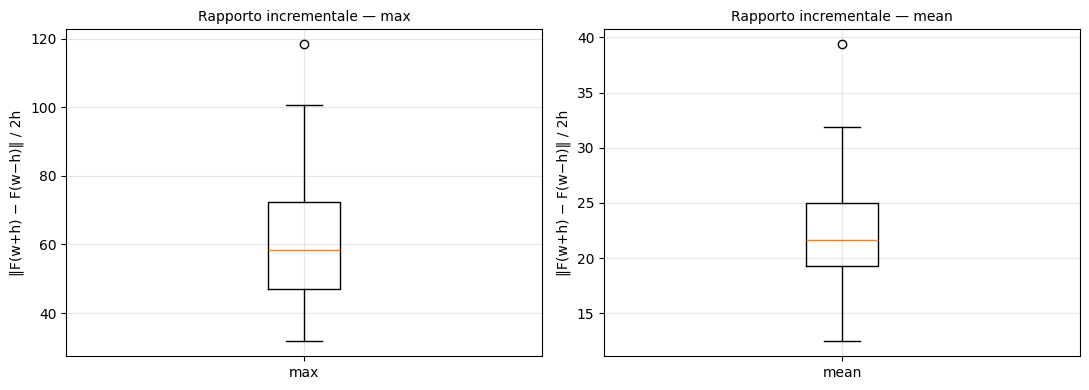

coppie con il salto piu' alto:


,pair,max,mean
1,0-2,118.383,24.452
41,6-9,100.708,27.195
39,6-7,95.801,27.204
0,0-1,87.497,39.377
21,2-7,85.758,24.199


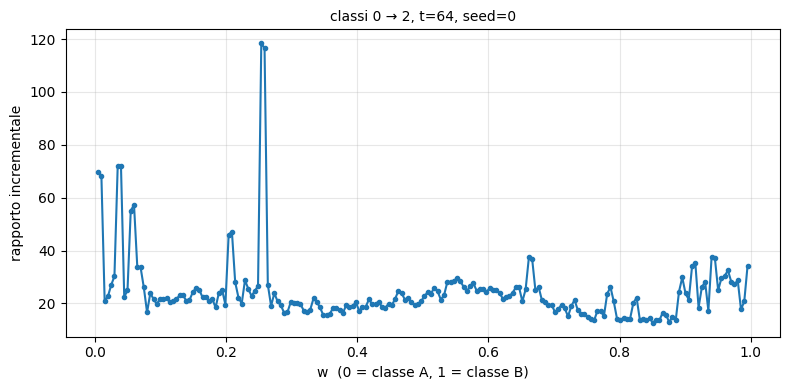

In [ ]:
def rollout_single_point(model, cfg: Config, a, b, w, steps, seed):
    """
    Un rollout dal seme, condizionato dalla combinazione convessa (1-w)*e_a + w*e_b.

    model  il modello da valutare
    a, b   indici delle due classi
    w      peso della classe b: 0 = solo a, 1 = solo b
    steps  passi di evoluzione
    seed   fissa le maschere stocastiche, cosi' due valori vicini di w danno
           traiettorie confrontabili

    Ritorna lo stato finale [1, C, H, W].
    """
    torch.manual_seed(seed)
    model.eval()
    class_vec = mix_onehot(a, b, float(w), cfg)
    x = make_seed(1, cfg)
    for _ in range(steps):
        x = model.step(x, class_vec)
    return x


def sweep_pair(model, cfg: Config, a, b, ws, h, steps, seed):
    """
    Scansione lungo il segmento fra due classi: il rapporto incrementale in ogni punto.

    ws  i pesi da campionare (devono stare in [h, 1-h])
    h   passo del rapporto incrementale centrale

    Ritorna la lista di ‖F(w+h) - F(w-h)‖ / (2h), uno per ogni w.
    """
    diffs = []
    for w in ws:
        out_plus = rollout_single_point(model, cfg, a, b, w + h, steps, seed)
        out_minus = rollout_single_point(model, cfg, a, b, w - h, steps, seed)
        # solo i 4 canali visibili: i latenti non sono l'immagine
        diffs.append((out_plus[:, :4] - out_minus[:, :4]).norm().item() / (2.0 * h))
    return diffs


def interpolation_regularity(model, cfg: Config, pairs=None, n_w=200, h=5e-3,
                             steps=64, seed=0):
    """
    Ripete la scansione su molte coppie di classi e ne riassume il profilo.

    pairs  coppie da testare; None = tutte le 45 combinazioni non ordinate
    n_w    quanti valori di w campionare per coppia
    steps  passi di evoluzione (il "tempo fissato" a cui si misura)

    Ritorna una tabella con una riga per coppia: `max` (il salto peggiore lungo il
    segmento) e `mean` (quanto varia in media).
    """
    pairs = pairs or list(itertools.combinations(range(cfg.num_classes), 2))
    ws = torch.linspace(h, 1 - h, n_w)      # dentro il simplesso anche dopo il +-h
    recs = []
    for a, b in tqdm(pairs, desc="coppie di classi"):
        diffs = sweep_pair(model, cfg, a, b, ws, h, steps, seed)
        recs.append(dict(pair=f"{a}-{b}", max=max(diffs), mean=sum(diffs) / len(diffs)))
    return pd.DataFrame(recs)


def plot_interpolation_regularity(df):
    """Distribuzione di `max` e `mean` sulle coppie, con le coppie piu' irregolari."""
    display(df[["max", "mean"]].describe().round(3).T)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, metric in zip(axes, ["max", "mean"]):
        ax.boxplot(df[metric])
        ax.set_xticklabels([metric])
        ax.set_title(f"Rapporto incrementale — {metric}", fontsize=10)
        ax.set_ylabel("‖F(w+h) − F(w−h)‖ / 2h")
        ax.grid(alpha=.3)
    plt.tight_layout()
    plt.show()

    print("coppie con il salto piu' alto:")
    display(df.sort_values("max", ascending=False).head(5).round(3))


def plot_worst_pair(model, cfg: Config, df, steps=64, n_w=200, h=5e-3, seed=0):
    """Il profilo completo della coppia con il salto piu' alto: dove sta il picco."""
    worst = df.sort_values("max", ascending=False).iloc[0]["pair"]
    a, b = map(int, worst.split("-"))
    ws = torch.linspace(h, 1 - h, n_w)
    diffs = sweep_pair(model, cfg, a, b, ws, h, steps, seed)

    plt.figure(figsize=(8, 4))
    plt.plot(ws.tolist(), diffs, marker="o", ms=3)
    plt.xlabel("w  (0 = classe A, 1 = classe B)")
    plt.ylabel("rapporto incrementale")
    plt.title(f"classi {a} → {b}, t={steps}, seed={seed}", fontsize=10)
    plt.grid(alpha=.3)
    plt.tight_layout()
    plt.show()


# 45 coppie x 200 valori di w x 2 rollout da 64 passi: qualche minuto su GPU.
# Per una prova rapida: pairs=[(3, 8), (4, 9)]
H_STEP = 5e-3
df_interp = interpolation_regularity(target_model, cfg, pairs=None, n_w=200,
                                     h=H_STEP, steps=64, seed=0)
plot_interpolation_regularity(df_interp)
plot_worst_pair(target_model, cfg, df_interp, n_w=200, h=H_STEP)

## Appendice: dominio a colori 64x64

Per concludere abbiamo provato a spingere un po' al limite il modello c-NCA v2, provando ad addestrarlo su 10 immagini fisse di nostra creazione RGB 64x64.

I cambiamenti apportati sono i seguenti:

**Il target è premoltiplicato**, come in *Growing NCA*: `img[..., :3] *= img[..., 3:]`. Nei capitoli su MNIST il target segue invece la costruzione del codice di riferimento c-NCA, con RGB grezzo. La premoltiplicazione ha due conseguenze: il vuoto è
`(0,0,0,0)` e una cella morta vale `(0,0,0,0)`, quindi il residuo è esattamente zero dove non c'è organismo; e l'errore di colore risulta pesato per l'opacità, perché se il
modello azzecca alpha ma sbaglia colore paga `α²‖ĉ−c‖²`.

**Budget incrementato.**, Al fine di riuscire ad addestrare con successo il modello su 10 classi così pesanti e dettagliate abbiamo dovuto aumentare significativamente il budget: il batch è bassato da 80 a 100 (10 per classe) e il numero di iterazioni per "epoca" è passato da 320 a 400.

**Abbiamo incrementato il tempo di rollout**
Il fronte vivo avanza al più di una cella per passo e il centro dista 32 celle dall'angolo, considerando pero che `fire_rate=0.5` il numero di passi minimo atteso affinchè l'organismo riempa la griglia 64x64 è 64. Per tanto abbiamo dovuto shiftare di 16 steps in avanti l'intervallo di rollout durante il training protandolo a $[80,112]$. Questo incremento per quanto piccolo in apparenza ha comunque un impatto forte sulla memoria a causa di BPPT, andando a motivare ulteriormente l'adozione del microbatching.

**Micro-batching.** Il rollout entra tutto nel grafo delle derivate, e a 64x64 con batch 100 le attivazioni non ci stanno in memoria. È stato quindi necessario spezzare il batch in micro-batch su cui calcolare il gradiente separatamente. Poiché la funzione di costo restituisce la media sul batch, per ottenere l'esatto gradiente del batch completo ogni loss intermedia è stata scalata per il rapporto $n / N$ (dove $n$ è la taglia del micro-batch e $N$ quella del batch totale) prima di accumulare i gradienti tramite BPTT.

**cosine annealing per il learning rate.** Con `lr=1-e3`costante abbiamo notato una certa difficoltà per quanro riguarda la velocità di convergenza nelle epoche più alte. Adottando lo sheduler cosine annealing tra `lr` e `lr/10` questo comportanto è risultato mitigato.

**La geometria dei danni scala con la griglia.** I raggi dei danni durante il training e il lato del quadrato sono frazioni d'area, quindi `damage_frac_*` produce a 64x64 danni in proporzione con quelli prodotti sulla griglia 28x28.

In [ ]:
# replace() e non cfg.image_size = 64: mutare cfg renderebbe silenziosamente sbagliati
# make_seed, i danni e i target di TUTTI i capitoli gia' eseguiti.
cfg64 = replace(
    cfg,
    image_size=64,
    in_ch=3,
    render_bg=1.0,                 # le immagini a colori si guardano su fondo bianco
    pool_size_per_class=1600,      # per tenere la stesso numero atteso di volte che uno stato viene estratto dal pool in 25 epoche
    steps_range=(80, 113),
    per_class_fix=10,
    pool_n_reset=2,                # empiricamente 1/8 è risultato troppo poco (gli organismi disimparavano a replicarsi dal seme) e 2/8 troppo (troppa poca omeostasi)
    pool_n_dam=4,                  # per questo abbiamo cambiato i rapporti in questo modo: 2 reset, 4 danneggiati, 4 fermi

    iters_fix=400,
)

pool_gb = (cfg64.num_classes * cfg64.pool_size_per_class * cfg64.channel_n
           * cfg64.image_size ** 2 * 4 / 2 ** 30)
print(f"rollout ∈ {cfg64.steps_range} | pool: {pool_gb:.2f} GB")
print(f"batch = {cfg64.num_classes * cfg64.per_class_fix} stati "
      f"({cfg64.pool_n_reset} al seme / {cfg64.pool_n_dam} danneggiati / "
      f"{cfg64.per_class_fix - cfg64.pool_n_reset - cfg64.pool_n_dam} intatti per classe)")

rollout ∈ (80, 113) | pool: 3.91 GB
batch = 100 stati (2 al seme / 4 danneggiati / 4 intatti per classe)


### A.1 - I target a colori

Dieci PNG RGBA (`img_0.png` ... `img_9.png`) in una cartella su Drive.

L'ordine delle due operazioni è **vincolante**: si premoltiplica *prima* di
ridimensionare. Sotto i pixel trasparenti il valore RGB è indefinito e, dopo un ritocco
in un editor, vale qualunque cosa (spesso bianco o nero pieno); ridimensionando prima,
il filtro bilineare lo mescolerebbe nei pixel di bordo e lascerebbe una frangia intorno
all'organismo — invisibile a occhio ma presente nel target.

target: (10, 4, 64, 64) | alpha medio 0.338


,alpha_mean,alpha_center,is_binary
0,0.2080,1.0,False
1,0.5160,1.0,False
2,0.2816,1.0,False
3,0.2789,1.0,False
4,0.3766,1.0,False
5,0.4065,1.0,False
6,0.3674,1.0,False
7,0.3517,1.0,False
8,0.2483,1.0,False
9,0.3434,1.0,False


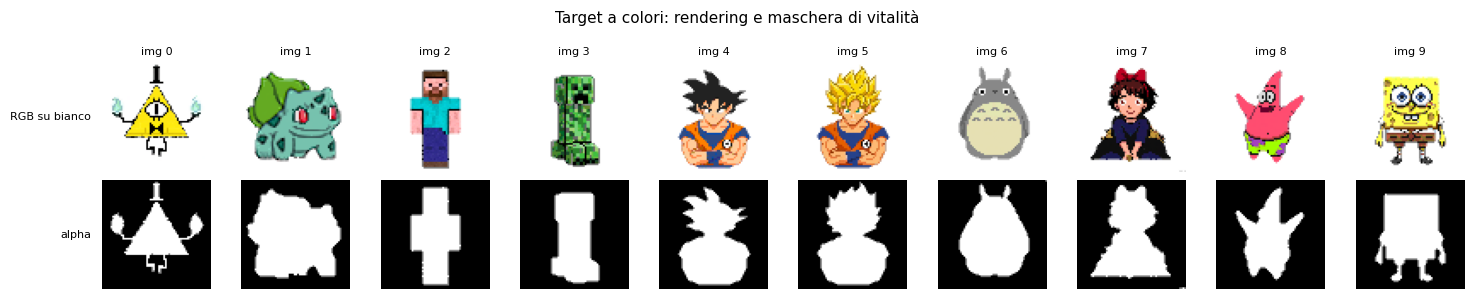

In [ ]:
from PIL import Image


def load_color_dataset(folder, cfg: Config, n=10):
    """
    Carica n PNG RGBA e li porta a [n, 4, H, W] premoltiplicati, nel formato della loss.

    folder cartella che contiene img_0.png ... img_{n-1}.png
    n      quante immagini caricare

    convert("RGBA") tiene il canale alpha del file (che e' il dato che ci serve, non un
    dettaglio); la premoltiplicazione avviene PRIMA del resize, per non sbavare i pixel
    trasparenti nel bordo dell'organismo.
    """
    out = []
    for i in range(n):
        path = os.path.join(folder, f"img_{i}.png")
        assert os.path.exists(path), f"manca {path}"
        a = np.float32(Image.open(path).convert("RGBA")) / 255.0     # [H, W, 4]
        a[..., :3] *= a[..., 3:]                                     # premoltiplica
        t = torch.from_numpy(a).permute(2, 0, 1)[None]               # [1, 4, H, W]
        out.append(F.interpolate(t, (cfg.image_size,) * 2, mode="bilinear",
                                 antialias=True, align_corners=False)[0])
    return torch.stack(out).to(cfg.device)


def target_alpha_audit(targets, cfg: Config):
    """
    Controlli sul canale alpha dei target: media, valore al centro (dove nasce il seme)
    e se alpha e' binaria invece che continua.
    """
    alpha, c = targets[:, 3], cfg.center
    return pd.DataFrame({
        "alpha_mean": alpha.mean(dim=(1, 2)).cpu().numpy(),
        "alpha_center": alpha[:, c, c].cpu().numpy(),
        "is_binary": [len(torch.unique(alpha[i])) <= 2 for i in range(len(alpha))],
    })


TARGETS_COLOR = load_color_dataset(os.path.join(cfg64.ckpt_dir, "color_images"), cfg64)
alpha = TARGETS_COLOR[:, 3]
print(f"target: {tuple(TARGETS_COLOR.shape)} | alpha medio {alpha.mean():.3f}")

# ogni controllo intercetta un modo diverso di sbagliare l'export dei PNG
assert (TARGETS_COLOR[:, :3] * (alpha[:, None] <= 0)).abs().max() == 0, \
    "RGB non nullo dove alpha=0: la premoltiplicazione non e' stata applicata"
if alpha.mean() > 0.85:
    print("  ATTENZIONE: alpha ~ 1 -> il PNG e' OPACO, l'export in trasparenza non ha "
          "funzionato e la alive mask non discriminerebbe nulla.")
if alpha.unique().numel() <= 2:
    print("  ATTENZIONE: alpha BINARIA -> il bordo perde l'antialiasing e il fronte di "
          "crescita trova uno scalino invece di una rampa.")

display(target_alpha_audit(TARGETS_COLOR, cfg64).round(4))

plot_grid([[as_image(TARGETS_COLOR, i, cfg64) for i in range(10)],
           [TARGETS_COLOR[i, 3].cpu().numpy() for i in range(10)]],
          row_labels=["RGB su bianco", "alpha"],
          col_labels=[f"img {i}" for i in range(10)],
          title="Target a colori: rendering e maschera di vitalità", scale=1.5)

### A.2 - Un solo bersaglio

Prima di provare con dieci classi abbiamo provato solo su spongebob. Così da separare la difficoltà del dominio (64x64 a
colori) da quella del condizionamento (dieci classi in una sola rete).

In [ ]:
target_single = TARGETS_COLOR[9:10]                       # [1, 4, H, W]
cfg_single = replace(cfg64, num_classes=1, n_epochs=25)

model_single = ConditionalNCAv2(cfg_single).to(cfg_single.device)
model_single, hist_single, _ = load_or_train(
    model_single, "c_nca_v2_color_single",
    lambda m: train_nca_fixed(m, target_single, cfg_single, mode="pool_damage",
                              monitor=LiveMonitor(cfg_single, digits=[0], plot_every=20,
                                                  preview_steps=512, preview_every=64)),
    cfg_single)

plot_history(hist_single, cfg_single, "Appendice — un solo bersaglio a colori")


[ckpt] pesi caricati da /content/drive/MyDrive/ProgettoDLAI/c_nca_v2_color_single.pth — training saltato
nessuna statistica di training salvata per questo modello


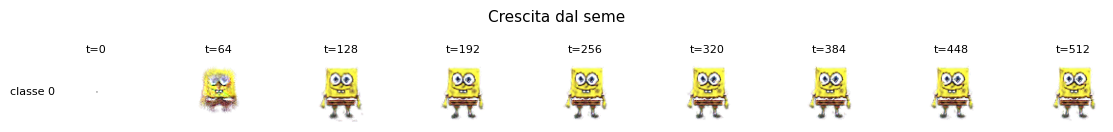

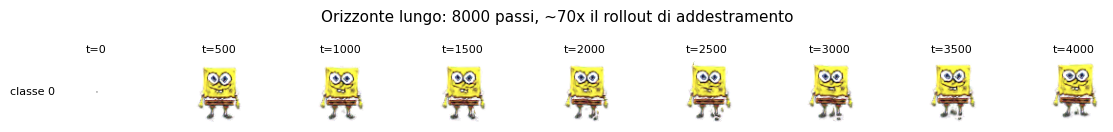

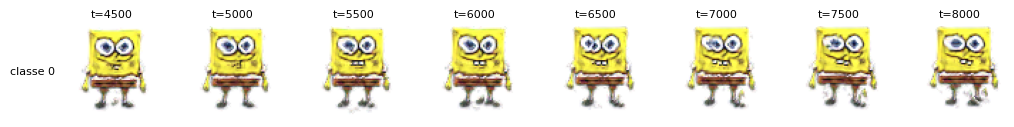

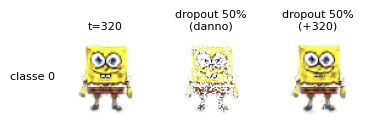

MSE RGBA dopo recupero,dropout 50%
digit,
0,0.0086


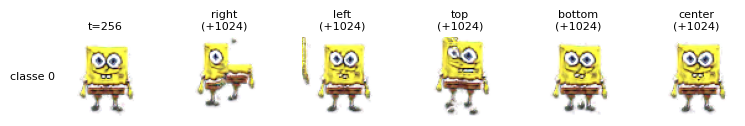

MSE RGBA dopo recupero,bottom,center,left,right,top
digit,,,,,
0,0.0177,0.0242,0.0418,0.0963,0.0714


In [ ]:
show_growth(model_single, cfg_single, max_steps=512, every=64, digits=[0],
            title="Crescita dal seme")
show_growth(model_single, cfg_single, max_steps=8000, every=500, digits=[0], ncol=9,
            title="Orizzonte lungo: 8000 passi, ~70x il rollout di addestramento")

df_rnd_single = damage_experiment(model_single, cfg_single,
                                  {"dropout 50%": dropout_damage(0.5)},
                                  steps_grow=320, steps_recover=320, seed=42,
                                  show_damaged=True, digits=[0])
df_loc_single = damage_experiment(model_single, cfg_single,
                                  localized_damage_set(cfg_single),
                                  steps_grow=256, steps_recover=1024, seed=42,
                                  digits=[0])

### A.3 - Dieci bersagli a colori

Il run completo: 40 epoche da 400 iterazioni, pool + danno, micro-batching a 4 blocchi e
learning rate a ricottura coseno da `lr` a `lr/10`.

In [ ]:
cfg_color = replace(cfg64, n_epochs=40)
MICRO, ETA_MIN_FRAC = 4, 0.1

B = cfg_color.num_classes * cfg_color.per_class_fix
print(f"{cfg_color.n_epochs} epoche x {cfg_color.iters_fix} iterazioni = "
      f"{cfg_color.n_epochs * cfg_color.iters_fix} passi | "
      f"batch {B} in {MICRO} blocchi da {B // MICRO}")
print(f"lr a coseno da {cfg_color.lr:.1e} a {cfg_color.lr * ETA_MIN_FRAC:.1e}")

model_color = ConditionalNCAv2(cfg_color).to(cfg_color.device)
model_color, hist_color, _ = load_or_train(
    model_color, "c_nca_v2_color",
    lambda m: train_nca_fixed(m, TARGETS_COLOR, cfg_color, mode="pool_damage",
                              micro=MICRO,
                              cos_anneal=True, eta_min_frac=ETA_MIN_FRAC,
                              monitor=LiveMonitor(cfg_color, plot_every=20,
                                                  preview_steps=512, preview_every=64)),
    cfg_color)

plot_history(hist_color, cfg_color, "Appendice — c-NCA v2, dieci immagini a colori")


40 epoche x 400 iterazioni = 16000 passi | batch 100 in 4 blocchi da 25
lr a coseno da 1.0e-03 a 1.0e-04
[ckpt] pesi caricati da /content/drive/MyDrive/ProgettoDLAI/c_nca_v2_color.pth — training saltato
nessuna statistica di training salvata per questo modello


### A.4 - Valutazione

Stessa batteria dei capitoli su MNIST, con due sostituzioni obbligate: LeNet non è
applicabile fuori da MNIST, quindi il giudice è `target_identifiability`; e la fedeltà
si legge in rapporto al **predittore banale**, cioè alla griglia vuota.

In [ ]:
@torch.no_grad()
def fidelity_report(model, targets, cfg: Config, steps=256):
    """
    Fedelta' per classe, misurata contro il predittore banale.

    mse       errore fra l'organismo cresciuto e il suo bersaglio
    mse_dead  errore della griglia VUOTA: quanto costa non fare niente
    skill     1 - mse/mse_dead. 0 = come non fare niente, 1 = ricostruzione esatta.

    Uno skill uniformemente alto e' un limite globale del modello; due o tre classi
    basse indicano invece interferenza fra le classi.
    """
    labels = torch.arange(cfg.num_classes, device=cfg.device)
    out, _ = grow(model, onehot(labels, cfg), steps, cfg)
    mse = F.mse_loss(out[:, :4], targets, reduction="none").mean(dim=[1, 2, 3]).cpu()
    dead = targets.pow(2).mean(dim=[1, 2, 3]).cpu()
    return pd.DataFrame({"mse": mse, "mse_dead": dead, "skill": 1 - mse / dead})


fid = fidelity_report(model_color, TARGETS_COLOR, cfg64)
display(fid.round(4))
print(f"skill medio {fid.skill.mean():.4f} | peggiore: classe {fid.skill.idxmin()} "
      f"({fid.skill.min():.4f})")

,mse,mse_dead,skill
0,0.0211,0.1204,0.8249
1,0.0178,0.2331,0.9237
2,0.0083,0.1301,0.9359
3,0.0106,0.0996,0.8937
4,0.0117,0.1788,0.9348
5,0.0120,0.2167,0.9446
6,0.0095,0.2240,0.9574
7,0.0142,0.1224,0.8842
8,0.0096,0.1284,0.9249
9,0.0235,0.1982,0.8812


skill medio 0.9105 | peggiore: classe 0 (0.8249)


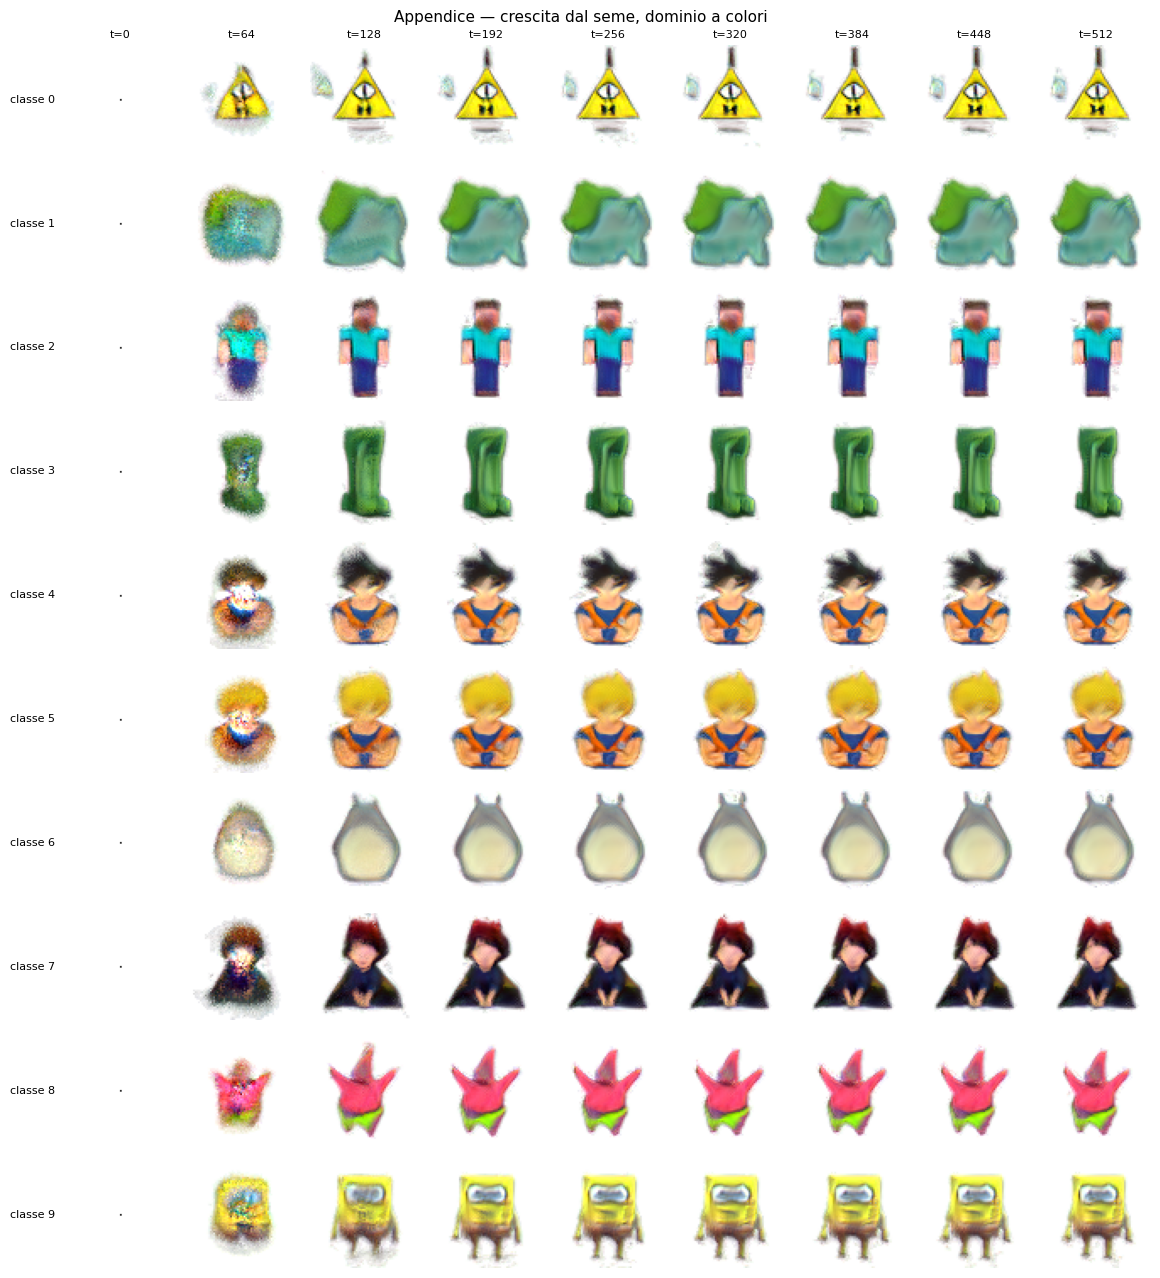

identificabilità: 100% | margine medio 0.05922


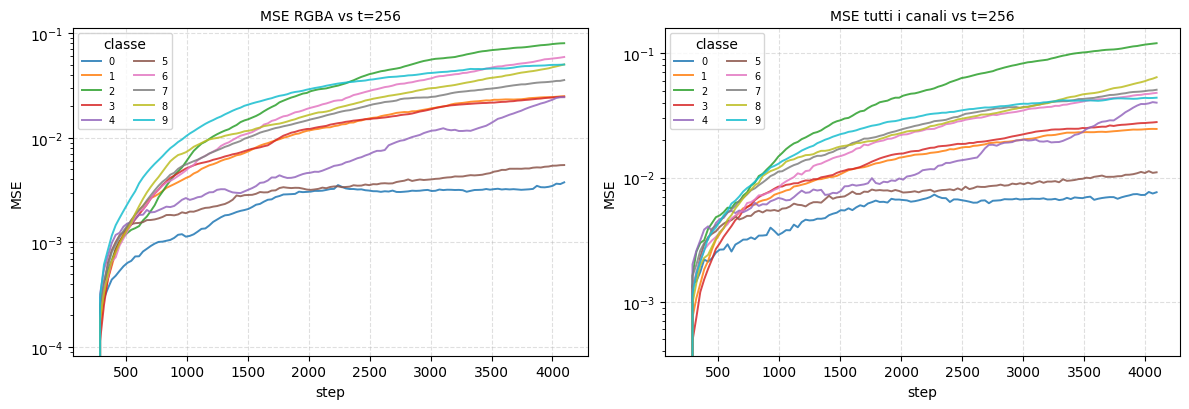

In [ ]:
show_growth(model_color, cfg64, max_steps=512, every=64, ncol=9,
            title="Appendice — crescita dal seme, dominio a colori")

labels_color = torch.arange(cfg64.num_classes, device=cfg64.device)
final_color, _ = grow(model_color, onehot(labels_color, cfg64), 256, cfg64)
pred, margin, acc = target_identifiability(final_color, TARGETS_COLOR, labels_color)
print(f"identificabilità: {100 * acc:.0f}% | margine medio {margin.mean():.5f}")

# il rollout di addestramento e' di 80-112 passi: 4096 sono ~40x, ben fuori distribuzione
df_home_color = homeostasis(model_color, cfg64, max_steps=4096, ref_step=256,
                            every=32, seed=42)

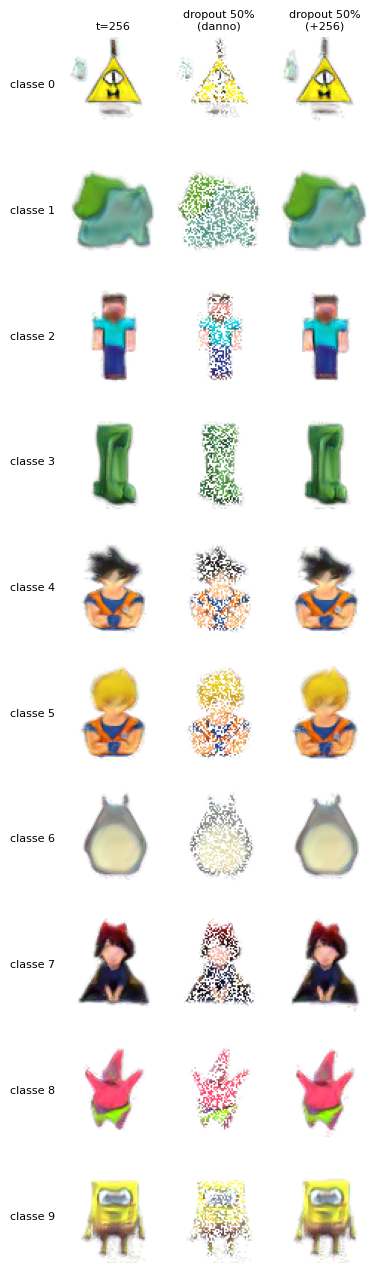

MSE RGBA dopo recupero,dropout 50%
digit,
0,0.0016
1,0.0019
2,0.0056
3,0.0020
4,0.0058
5,0.0049
6,0.0017
7,0.0031
8,0.0033


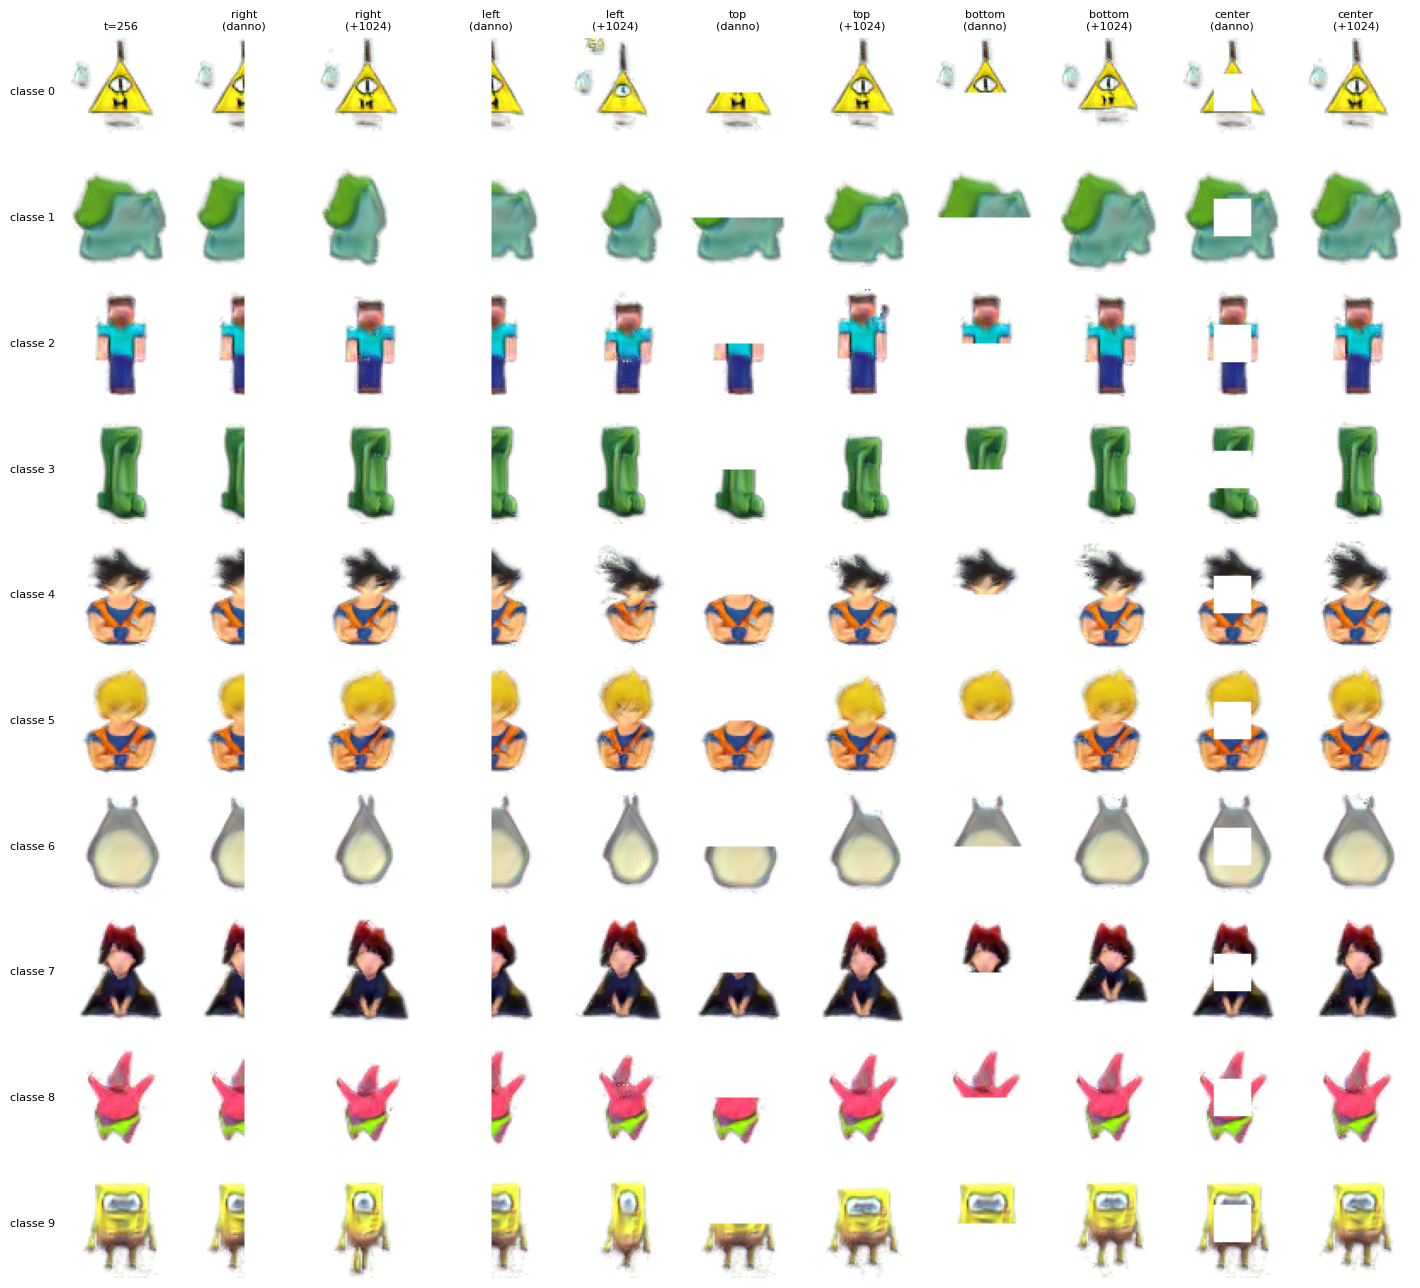

MSE RGBA dopo recupero,bottom,center,left,right,top
digit,,,,,
0,0.0153,0.0072,0.0627,0.0075,0.0144
1,0.0166,0.0060,0.0933,0.0698,0.0398
2,0.0089,0.0133,0.0953,0.0152,0.0107
3,0.0070,0.0076,0.0278,0.0102,0.0183
4,0.0267,0.0047,0.1095,0.0205,0.0070
5,0.0096,0.0023,0.0930,0.0300,0.0193
6,0.0105,0.0077,0.1066,0.0571,0.0175
7,0.0424,0.0115,0.0401,0.0085,0.0063
8,0.0134,0.0112,0.0779,0.0176,0.0167


In [ ]:
df_rnd_color = damage_experiment(model_color, cfg64,
                                 {"dropout 50%": dropout_damage(0.5)},
                                 steps_grow=256, steps_recover=256, seed=42,
                                 show_damaged=True)
df_loc_color = damage_experiment(model_color, cfg64, localized_damage_set(cfg64),
                                 steps_grow=256, steps_recover=1024, seed=42,
                                 show_damaged=True)

Questo test è il solo motivo per cui abbiamo messo sia Goku che Goku ssj, così possiamo vedere la trasformazione!

In [ ]:
_ = interpolation_widget(model_color, cfg64)

interactive(children=(IntSlider(value=0, description='classe A', max=9), IntSlider(value=1, description='class…